# somethingsomething
**Applied Time Series Analysis**

In [1]:
install.packages(c("forecast", "fma", "expsmooth", "lmtest", "tseries", "Mcomp"))

install.packages(
  "C:/Programming/ETH/SS26/ATSA26/Exercises/fpp_0.5.tar.gz",
  repos = NULL,
  type = "source"
)


  There are binary versions available but the source versions are later:
          binary  source needs_compilation
forecast  8.24.0   9.0.2              TRUE
tseries  0.10-58 0.10-61              TRUE

  Binaries will be installed
package 'forecast' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'forecast'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Programming\R-4.3.1\library\00LOCK\forecast\libs\x64\forecast.dll to C:\Programming\R-4.3.1\library\forecast\libs\x64\forecast.dll: Permission denied"
Warning message:
"restored 'forecast'"


package 'fma' successfully unpacked and MD5 sums checked
package 'expsmooth' successfully unpacked and MD5 sums checked
package 'lmtest' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'lmtest'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Programming\R-4.3.1\library\00LOCK\lmtest\libs\x64\lmtest.dll to C:\Programming\R-4.3.1\library\lmtest\libs\x64\lmtest.dll: Permission denied"
Warning message:
"restored 'lmtest'"


package 'tseries' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'tseries'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Programming\R-4.3.1\library\00LOCK\tseries\libs\x64\tseries.dll to C:\Programming\R-4.3.1\library\tseries\libs\x64\tseries.dll: Permission denied"
Warning message:
"restored 'tseries'"


package 'Mcomp' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\trist\AppData\Local\Temp\Rtmp4ofBKB\downloaded_packages


In [2]:
library(fpp)

Loading required package: forecast

Warning message:
"package 'forecast' was built under R version 4.3.3"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: fma

Warning message:
"package 'fma' was built under R version 4.3.3"
Loading required package: expsmooth

Warning message:
"package 'expsmooth' was built under R version 4.3.3"
Loading required package: lmtest

Warning message:
"package 'lmtest' was built under R version 4.3.3"
Loading required package: zoo

Warning message:
"package 'zoo' was built under R version 4.3.3"

Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Loading required package: tseries

Warning message:
"package 'tseries' was built under R version 4.3.3"


In [3]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


### 1.

![ex6_1.png](ex6_1.png)

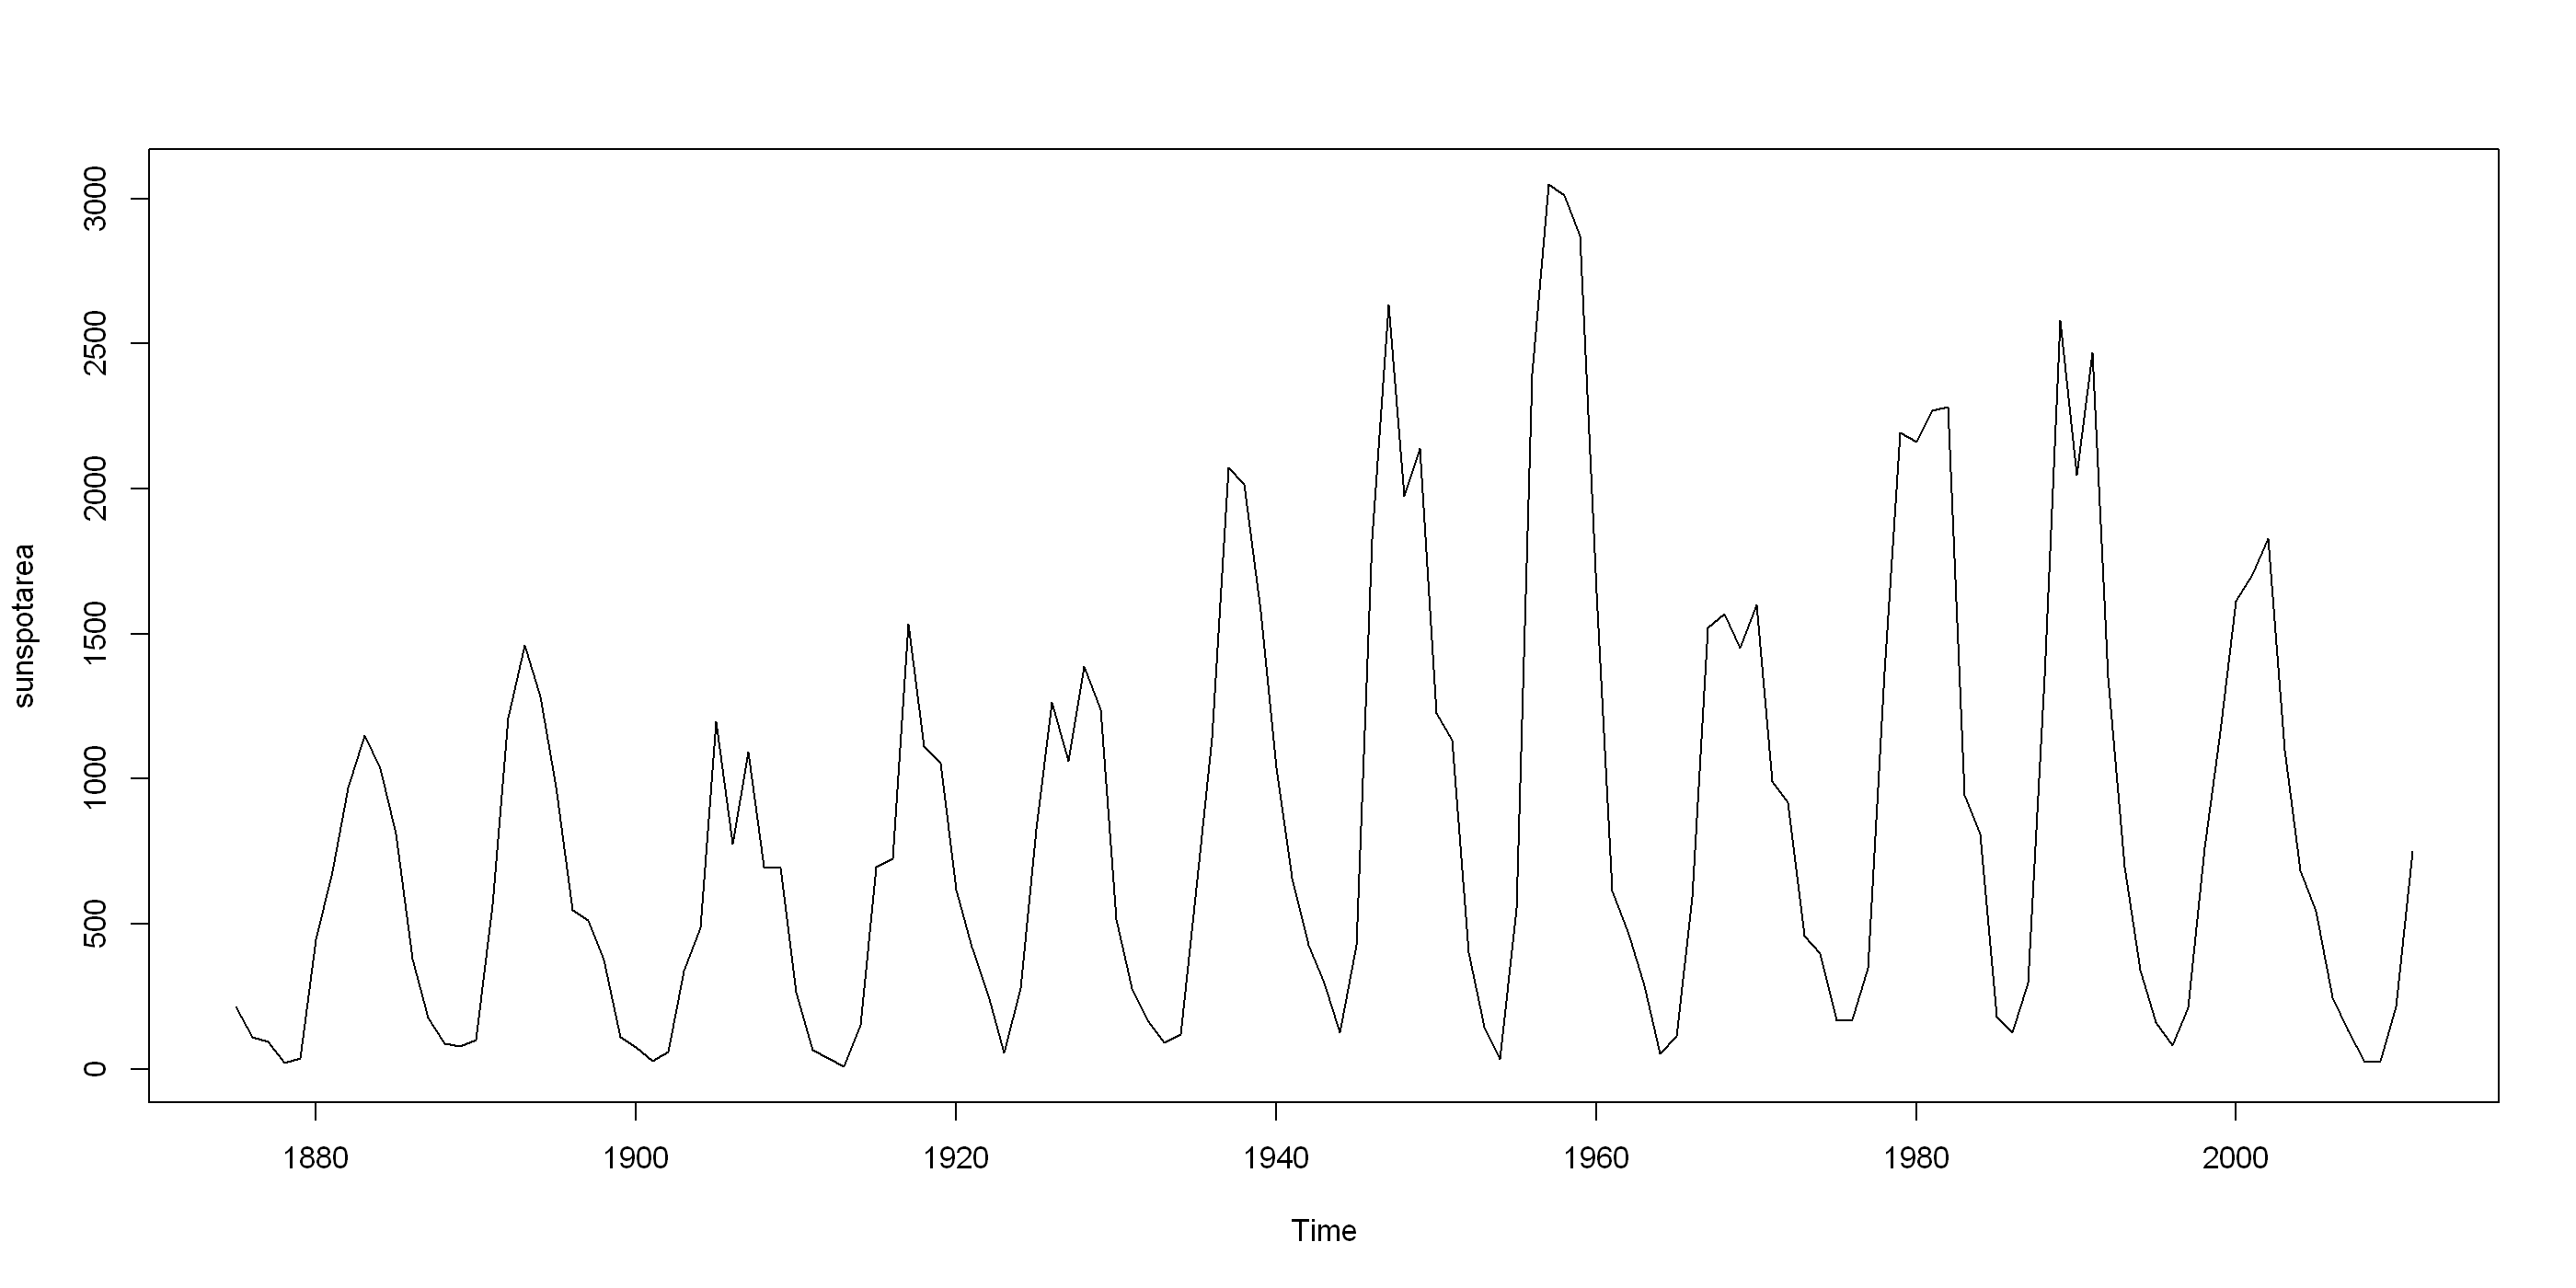

In [4]:
plot(sunspotarea)

It makes sense to log transform the series for two main reasons: 
1. The raw data is a at a relative scale, 
2. There are severe peaks, that dominate.

[1] 137


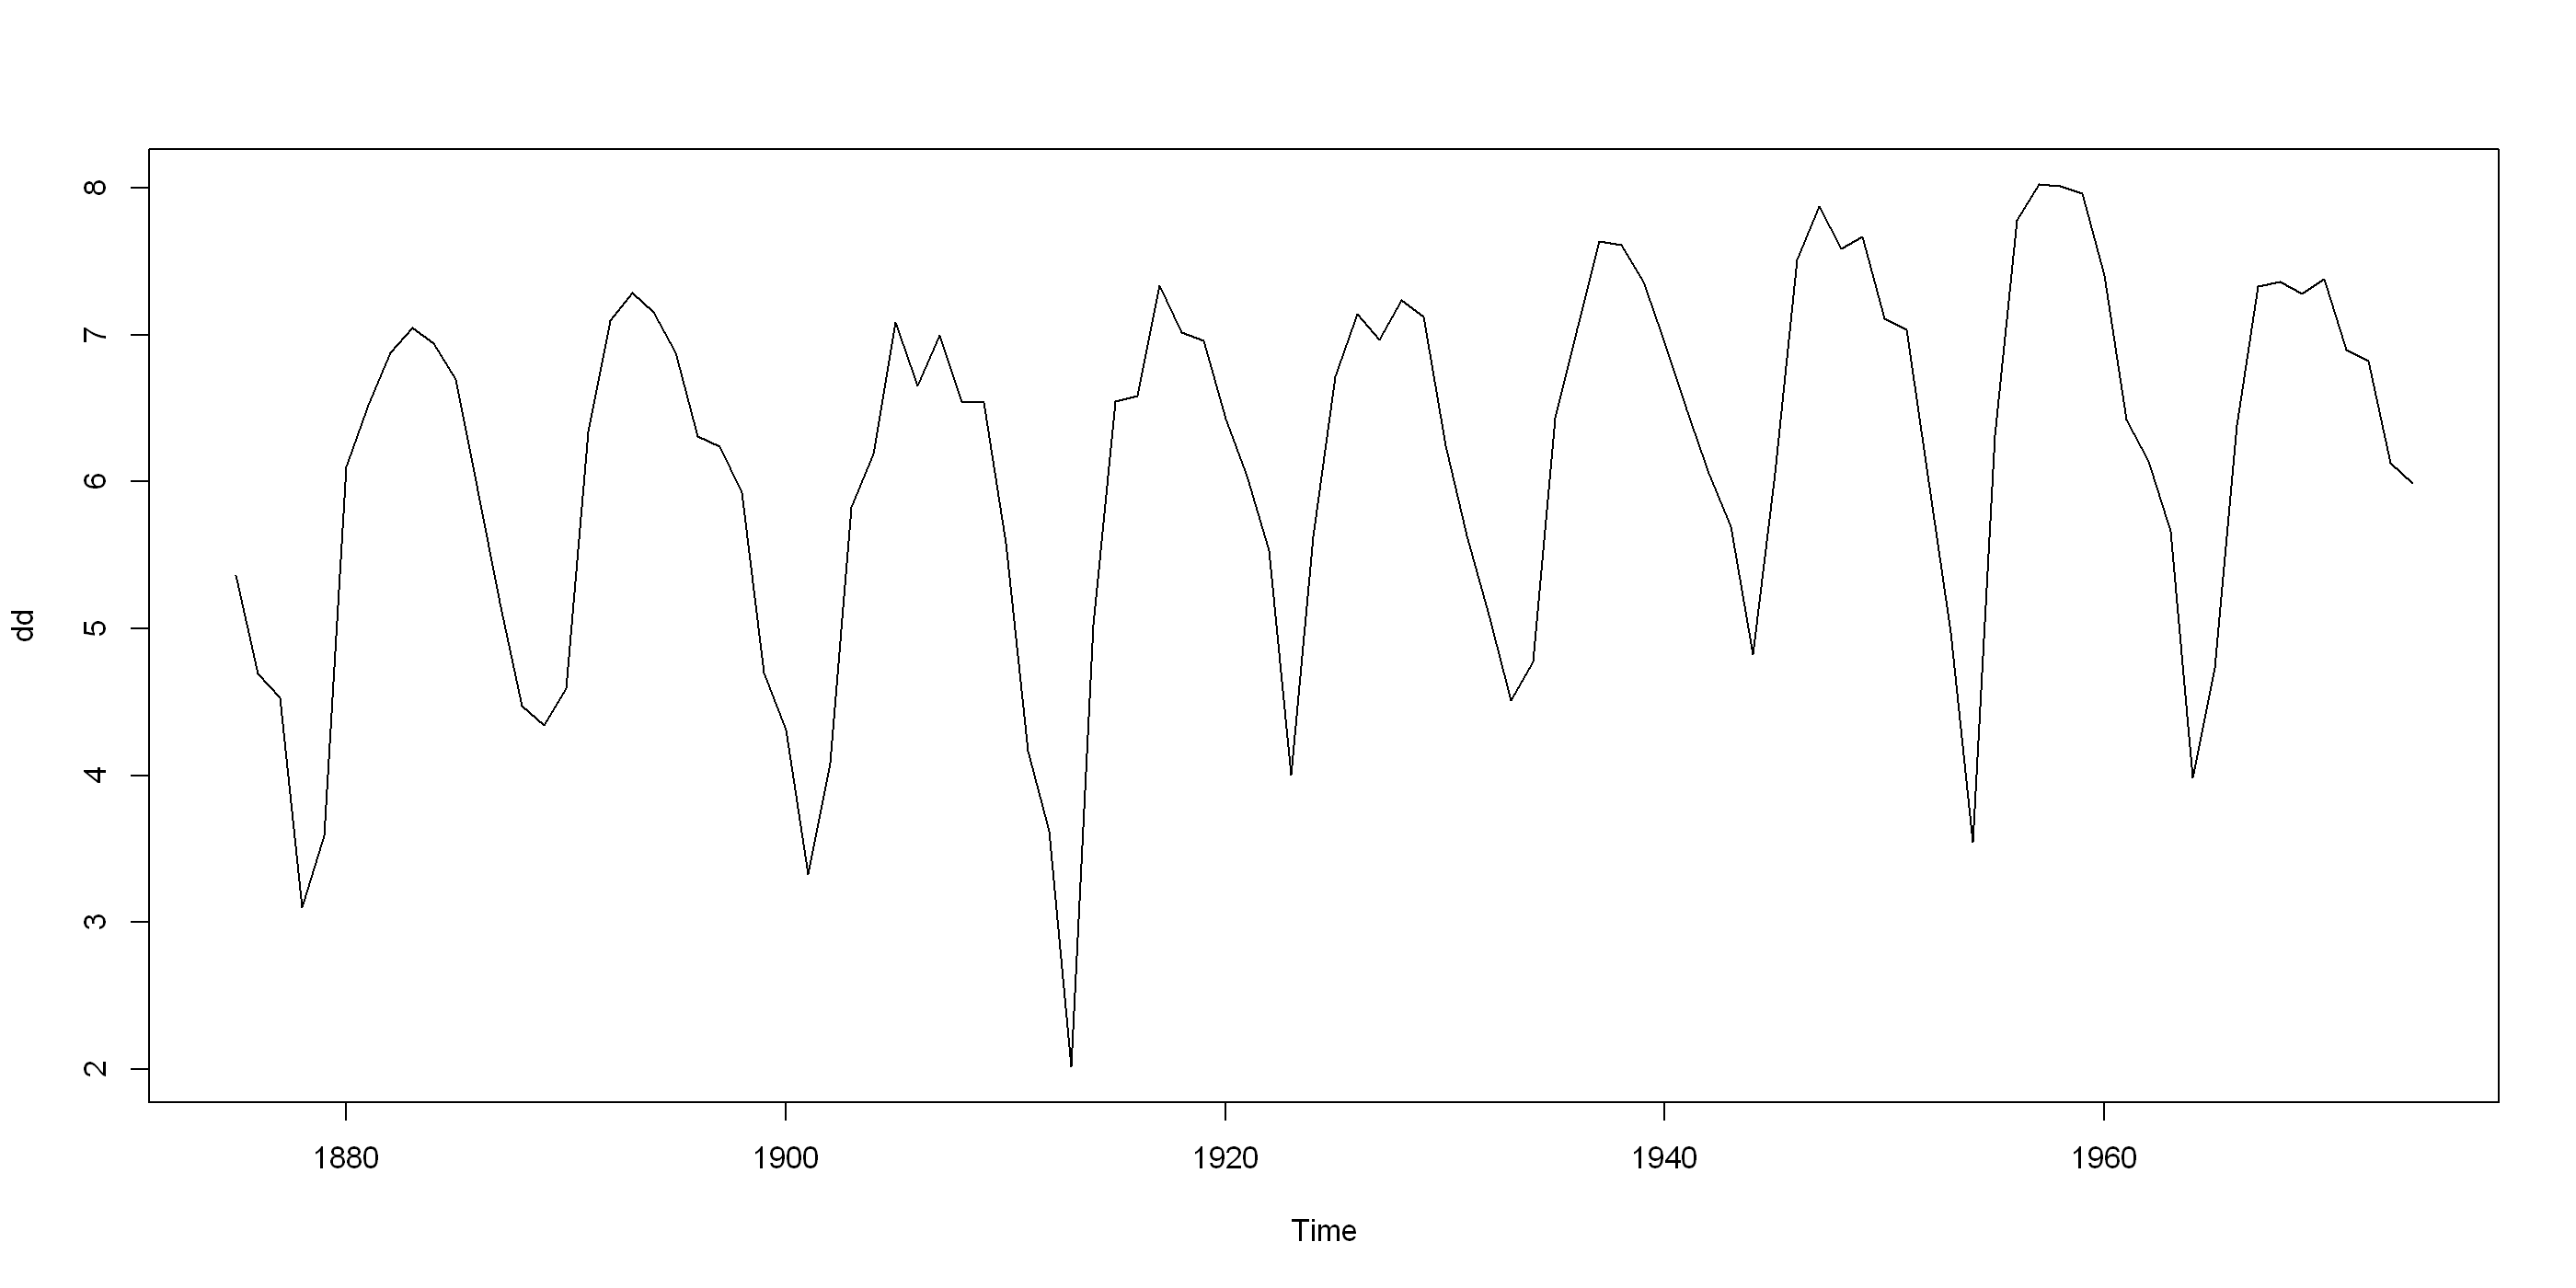

In [5]:
print(length(sunspotarea))
dd <- window(sunspotarea,start = 1875,end=1974)
dd <- log(dd)
plot(dd)

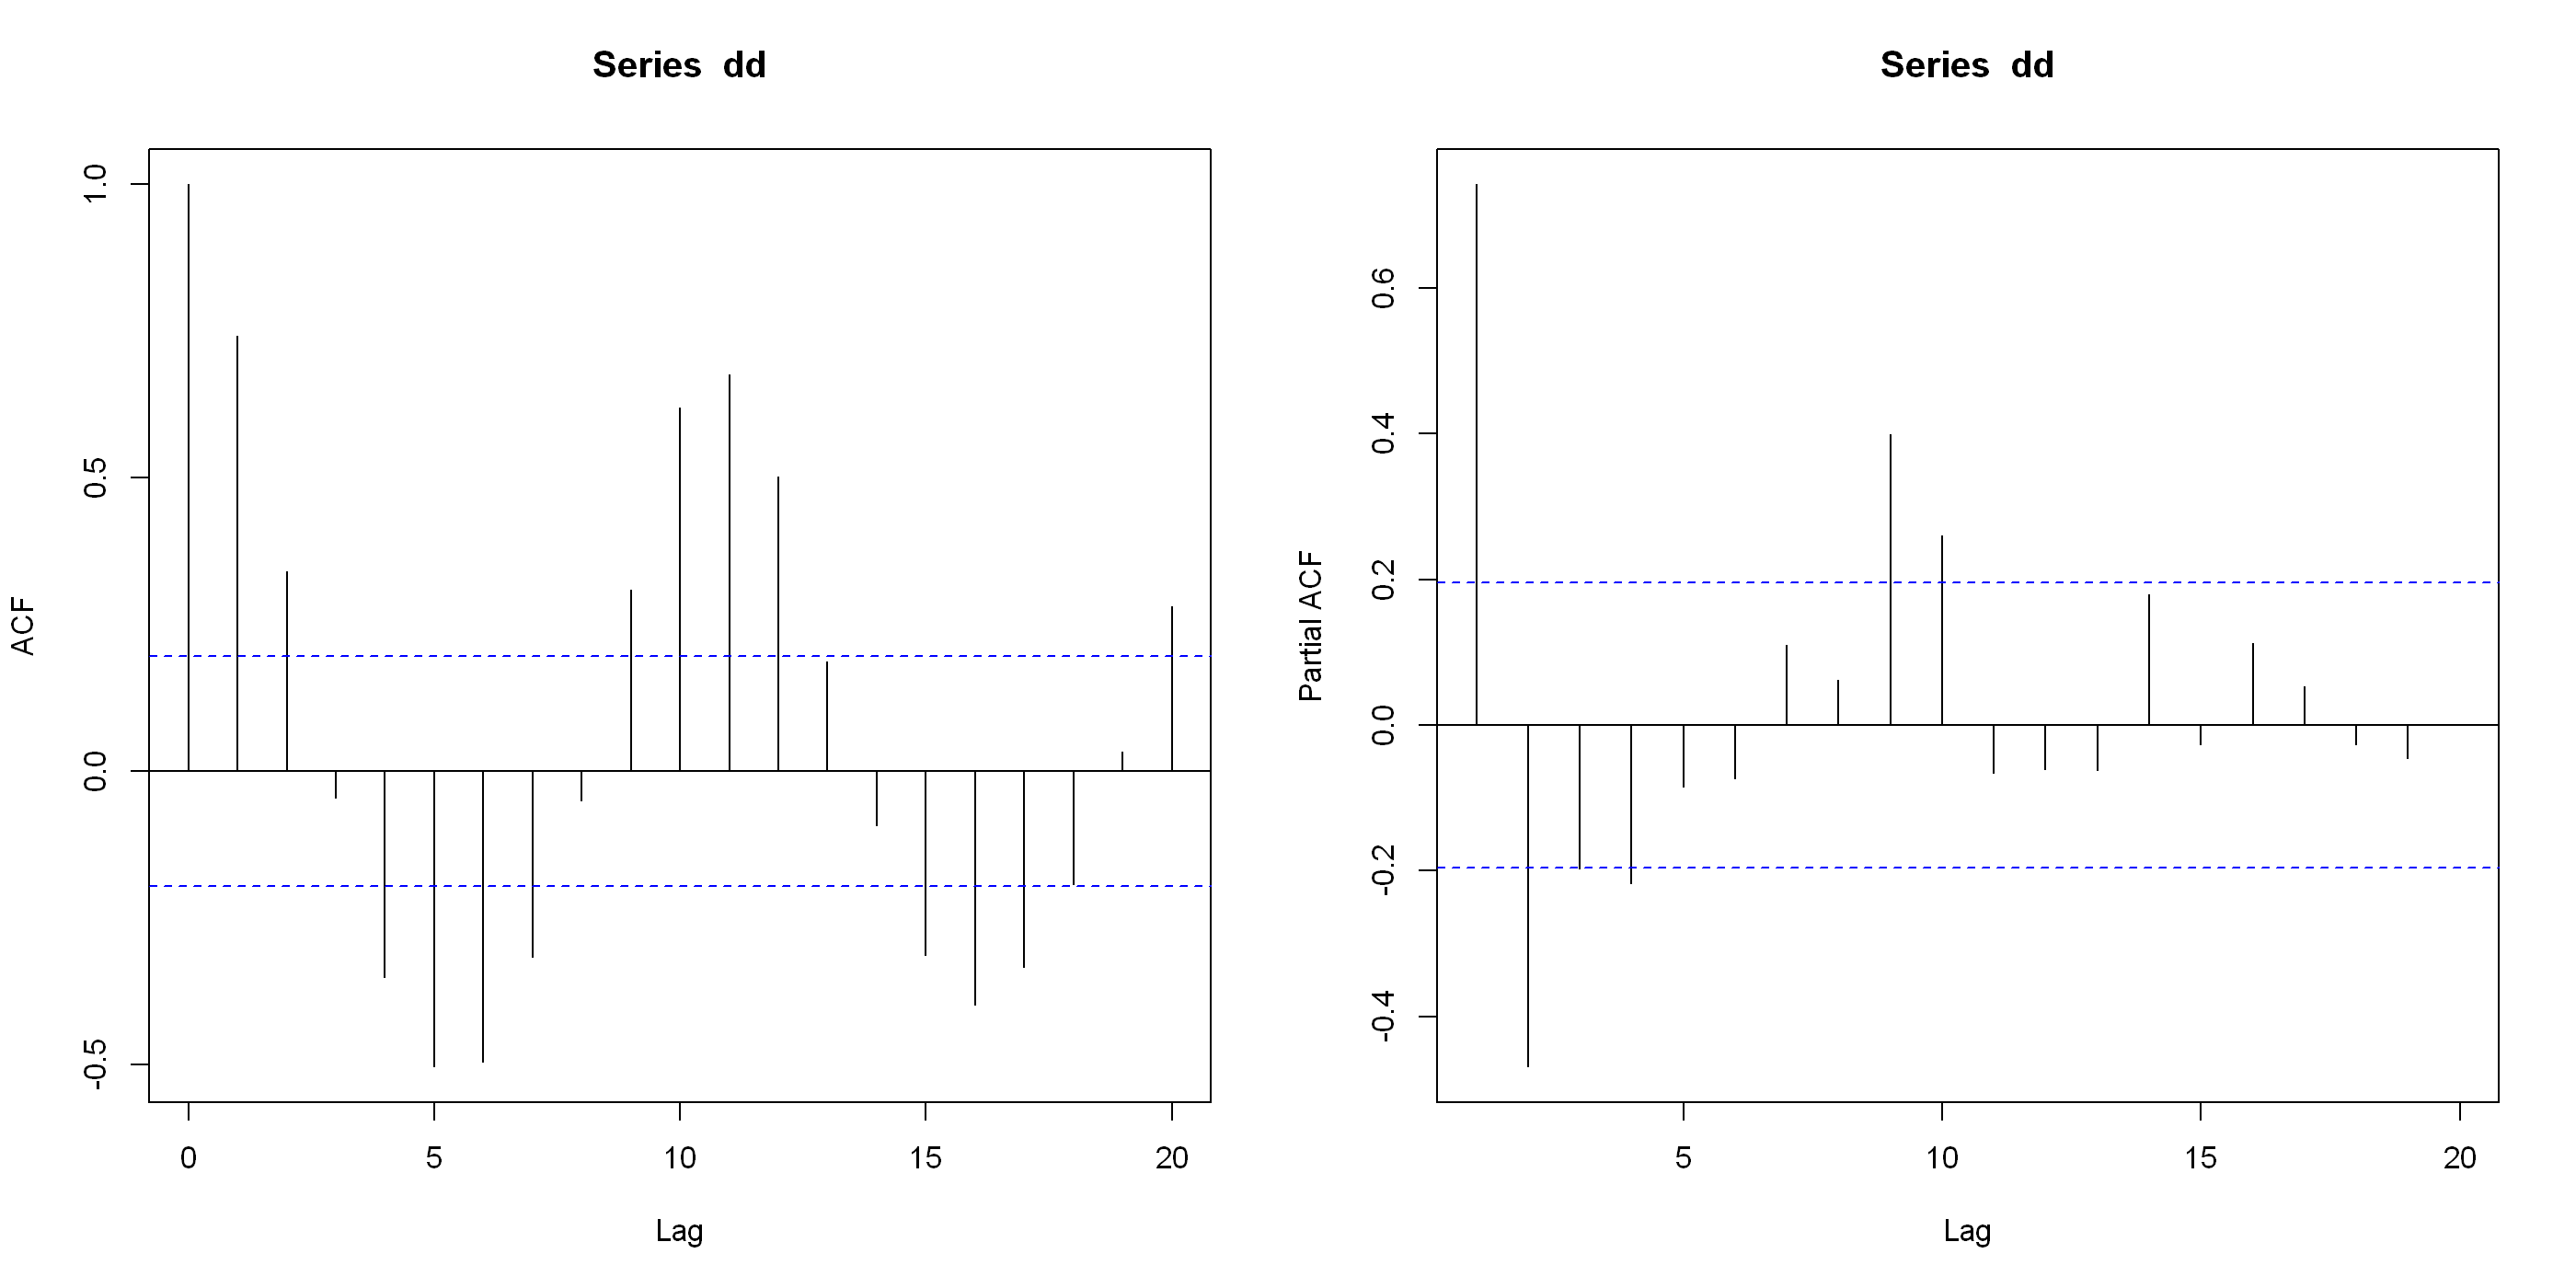

In [6]:
par(mfrow = c(1,2))
acf(dd)
pacf(dd)


AR(p), with $p=10$ looks roughly right, but we note there is clearly a serious seasonality, and perhaps even a slight trend, limited to only AR(p) we choose $p=10$.

In [7]:
model <- arima(x = dd,order = c(10,0,0))

In [8]:
str(model)

List of 14
 $ coef     : Named num [1:11] 0.7171 -0.1887 0.0045 -0.0621 0.022 ...
  ..- attr(*, "names")= chr [1:11] "ar1" "ar2" "ar3" "ar4" ...
 $ sigma2   : num 0.344
 $ var.coef : num [1:11, 1:11] 0.00879 -0.00787 0.002943 -0.000837 0.001377 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:11] "ar1" "ar2" "ar3" "ar4" ...
  .. ..$ : chr [1:11] "ar1" "ar2" "ar3" "ar4" ...
 $ mask     : logi [1:11] TRUE TRUE TRUE TRUE TRUE TRUE ...
 $ loglik   : num -91.1
 $ aic      : num 206
 $ arma     : int [1:7] 10 0 0 0 1 0 0
 $ residuals: Time-Series [1:100] from 1875 to 1974: -0.352 -0.605 -0.315 -1.559 -0.248 ...
 $ call     : language arima(x = dd, order = c(10, 0, 0))
 $ series   : chr "dd"
 $ code     : int 0
 $ n.cond   : int 0
 $ nobs     : int 100
 $ model    :List of 10
  ..$ phi  : num [1:10] 0.7171 -0.1887 0.0045 -0.0621 0.022 ...
  ..$ theta: num [1:9] 0 0 0 0 0 0 0 0 0
  ..$ Delta: num(0) 
  ..$ Z    : num [1:10] 1 0 0 0 0 0 0 0 0 0
  ..$ a    : num [1:10] -0.11593 -0.68177

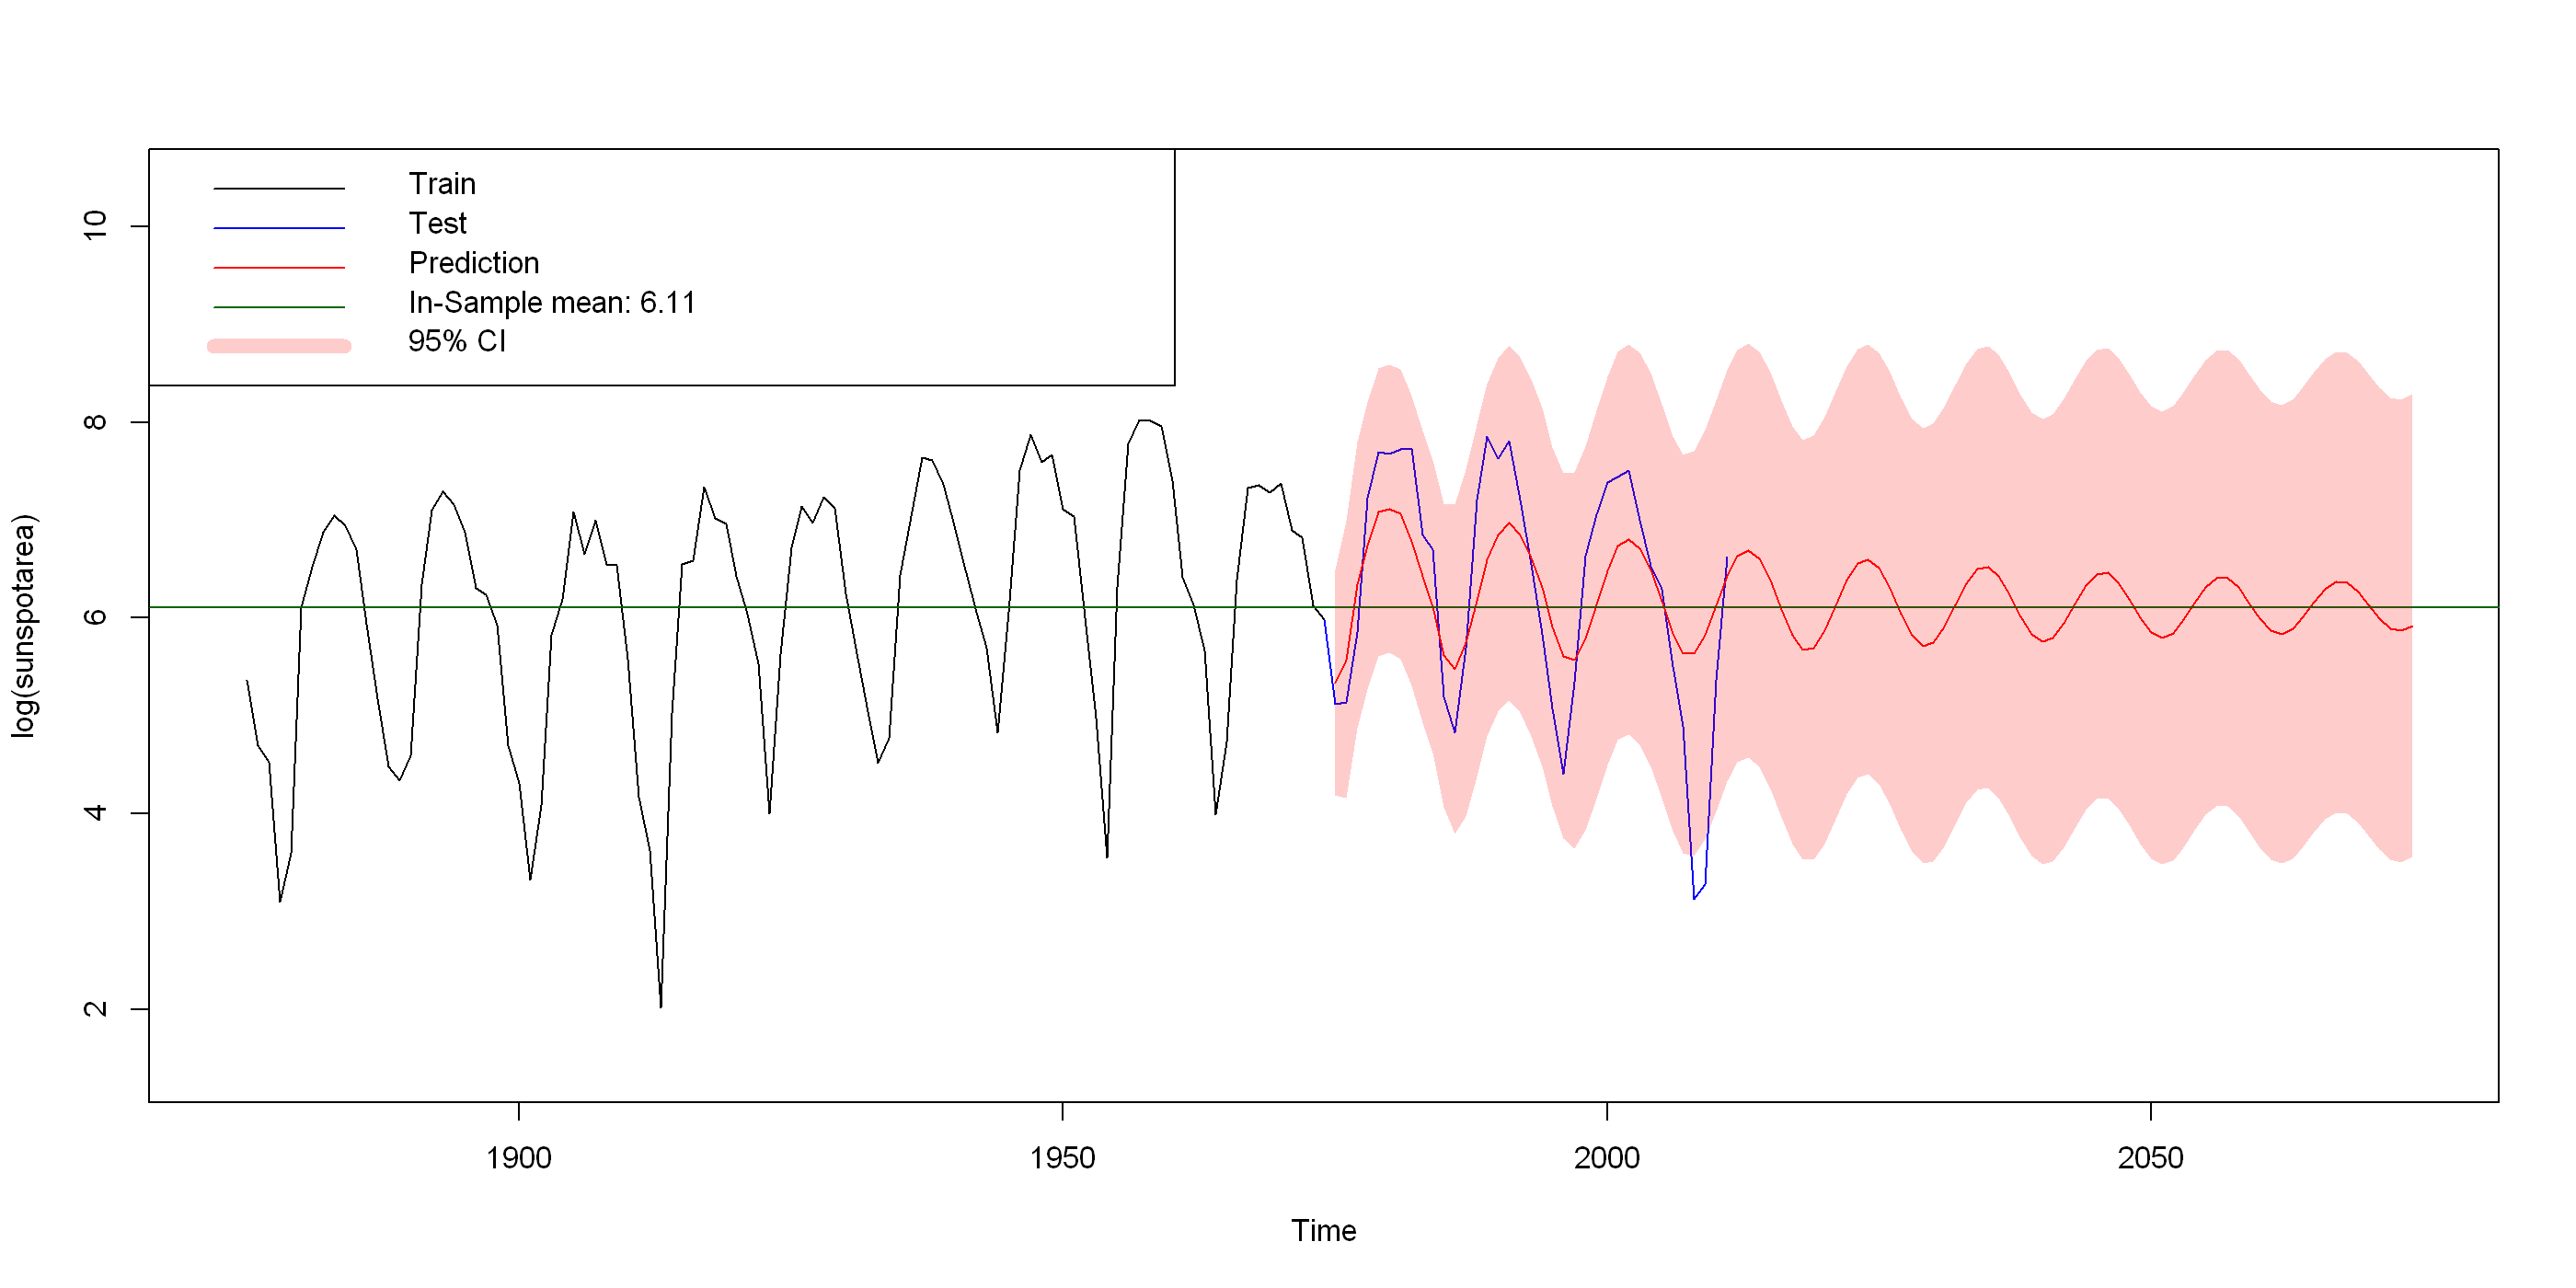

In [9]:
dd_hat <- predict(model,n.ahead = 100)
plot(log(sunspotarea),xlim=c(1874,1974+100),ylim=c(min(dd)*0.7,max(dd)*1.3),col="blue")
lines(dd)
lines(dd_hat$pred,col="red")
mu <- mean(dd)
abline(h=mu,col="darkgreen")
alpha95 <- 0.05

z95 <- qnorm(1 - alpha95 / 2)


y_upper95 <- dd_hat$pred + z95 * dd_hat$se
y_lower95 <- dd_hat$pred - z95 * dd_hat$se

x_years <- seq(1974+1, 1974 + 100)
polygon(x=c(x_years,rev(x_years)),
        c(y_upper95, rev(y_lower95)),
        col = adjustcolor("red", alpha.f = 0.2), border = NA)


legend("topleft",
    legend = c("Train","Test","Prediction",paste0("In-Sample mean: ",round(mu,2)),"95% CI"),
    lwd = c(1,1,1,1,8),
    col=c("black","blue","red","darkgreen",adjustcolor("red", alpha.f = 0.2)))





It is clear that the prediction converges the to the mean, which makes sense, based on the arguments from the lecture, further it is rather odd to extrapolate further than the order we're using for the AR process, i.e. it is obvious that after the first cycle ~10 observations or so, the prediction becomes rather poor, especially in the later terms.

In [10]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


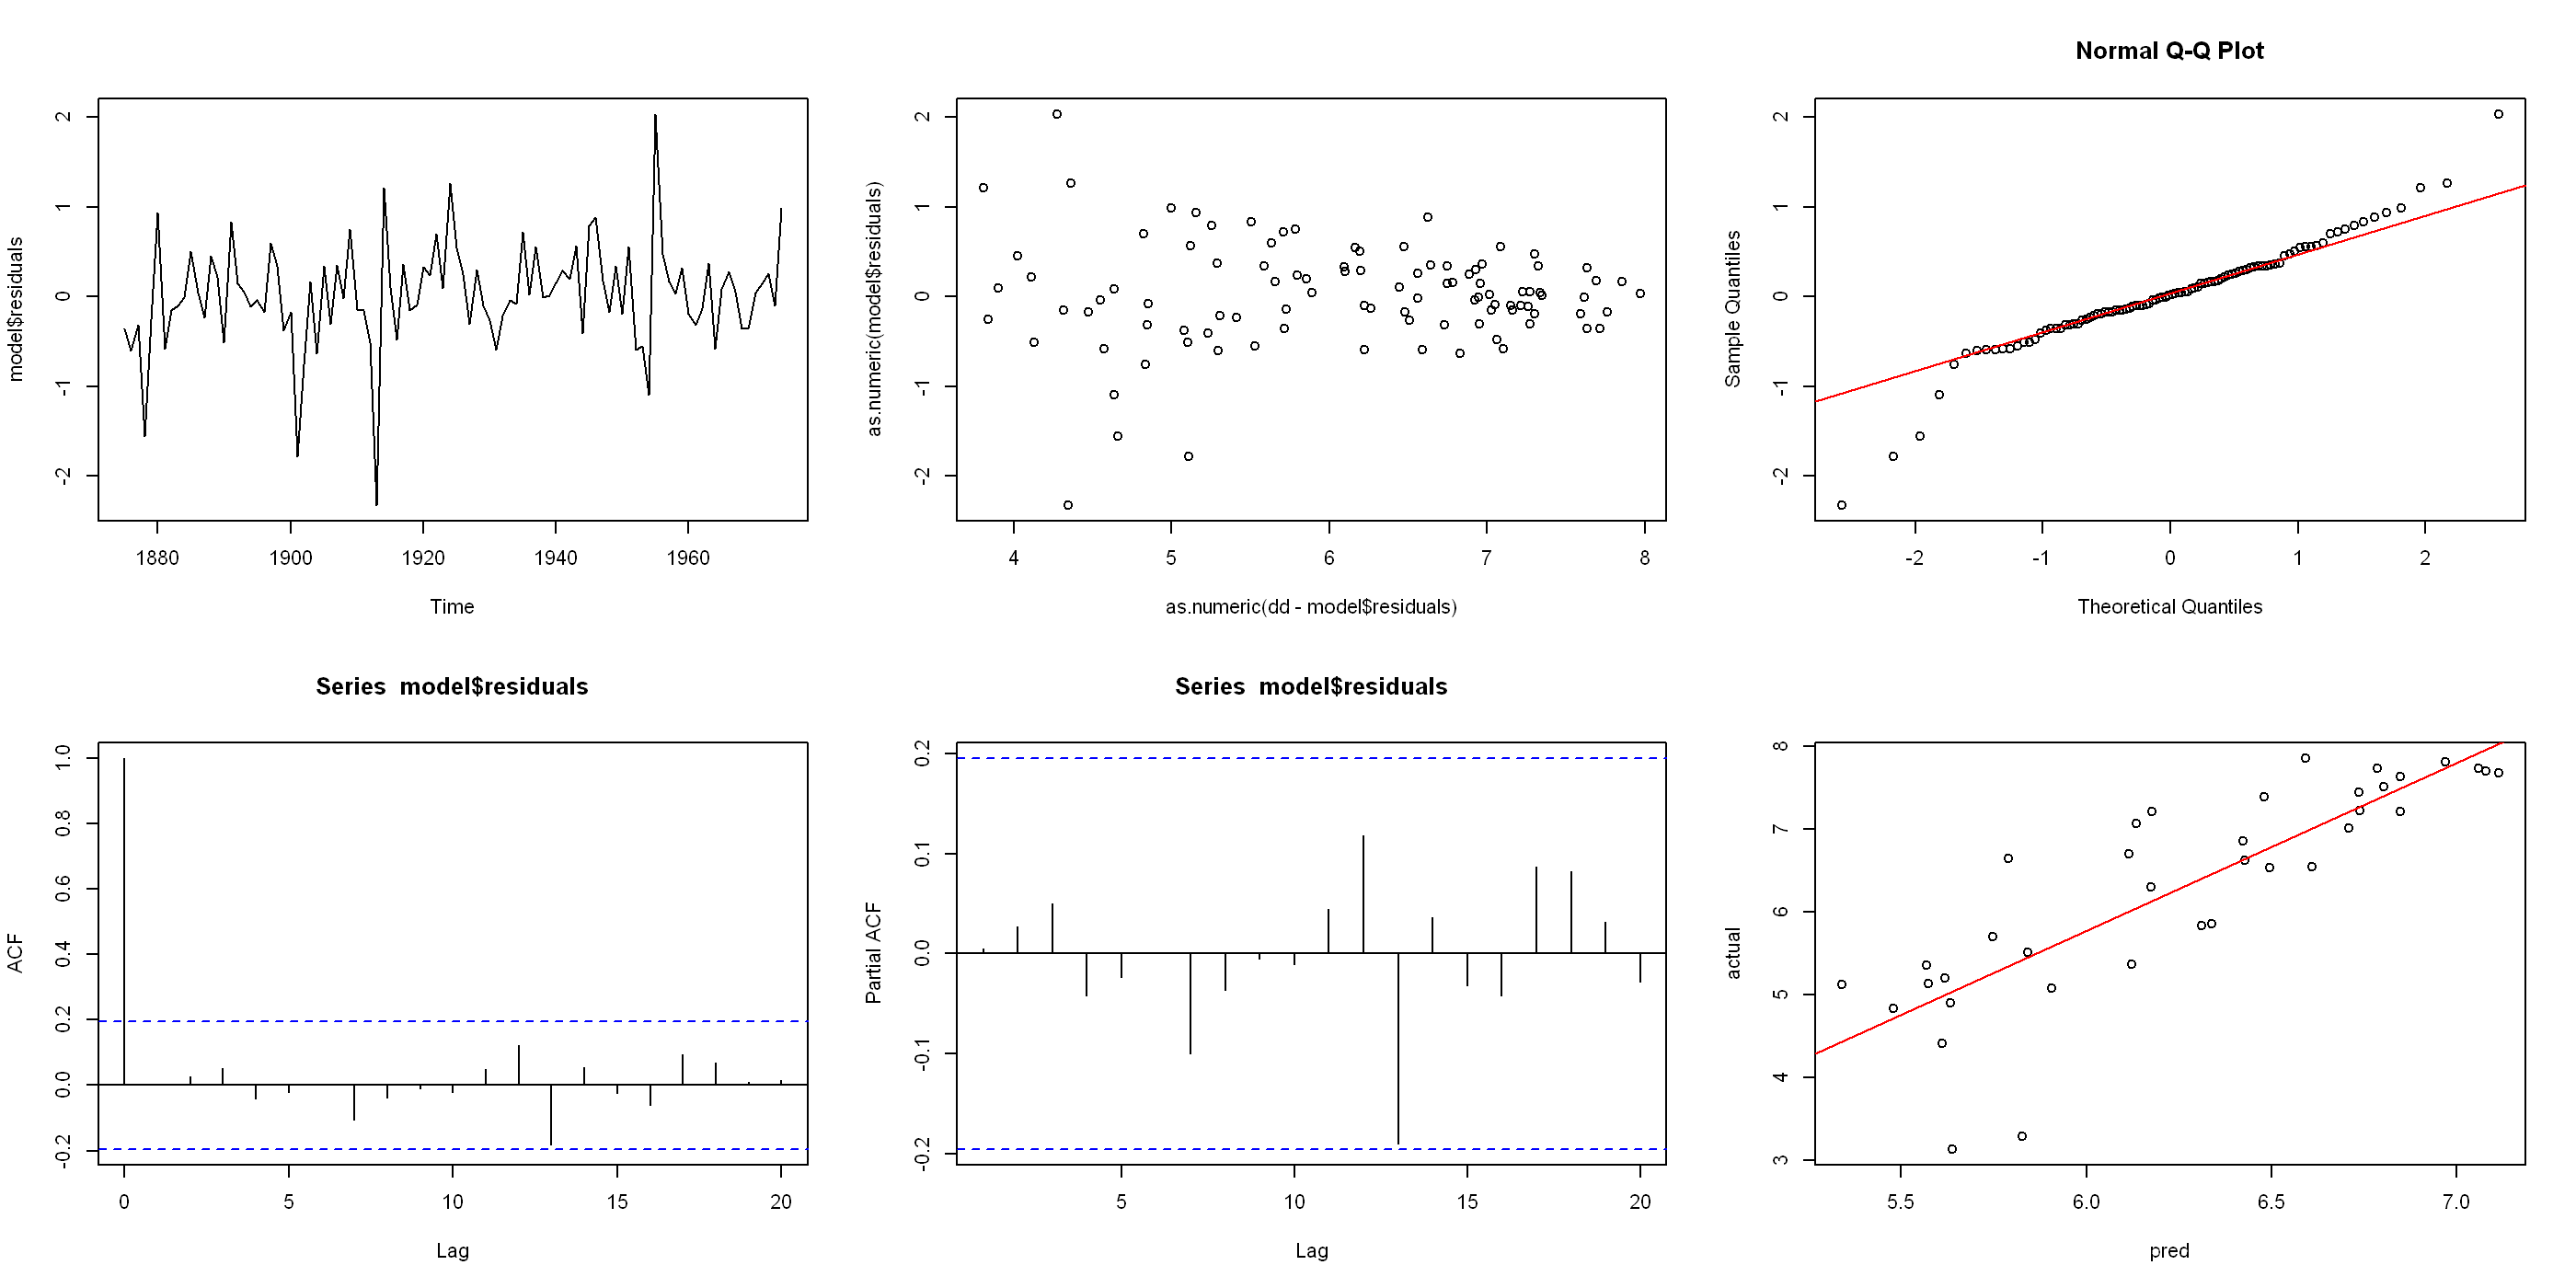

In [11]:
par(mfrow = c(2,3))
plot(model$residuals)
plot(as.numeric(dd-model$residuals),as.numeric(model$residuals))
qqnorm(model$residuals)
qqline(model$residuals,col="red")
acf(model$residuals)
pacf(model$residuals)
pred   <- as.numeric(window(dd_hat$pred, start = 1975, end = 2011))
actual <- as.numeric(log(window(sunspotarea, start = 1975, end = 2011)))
plot(pred,actual)
abline(lm(actual ~ pred), col = "red")


[1] 0.7557876


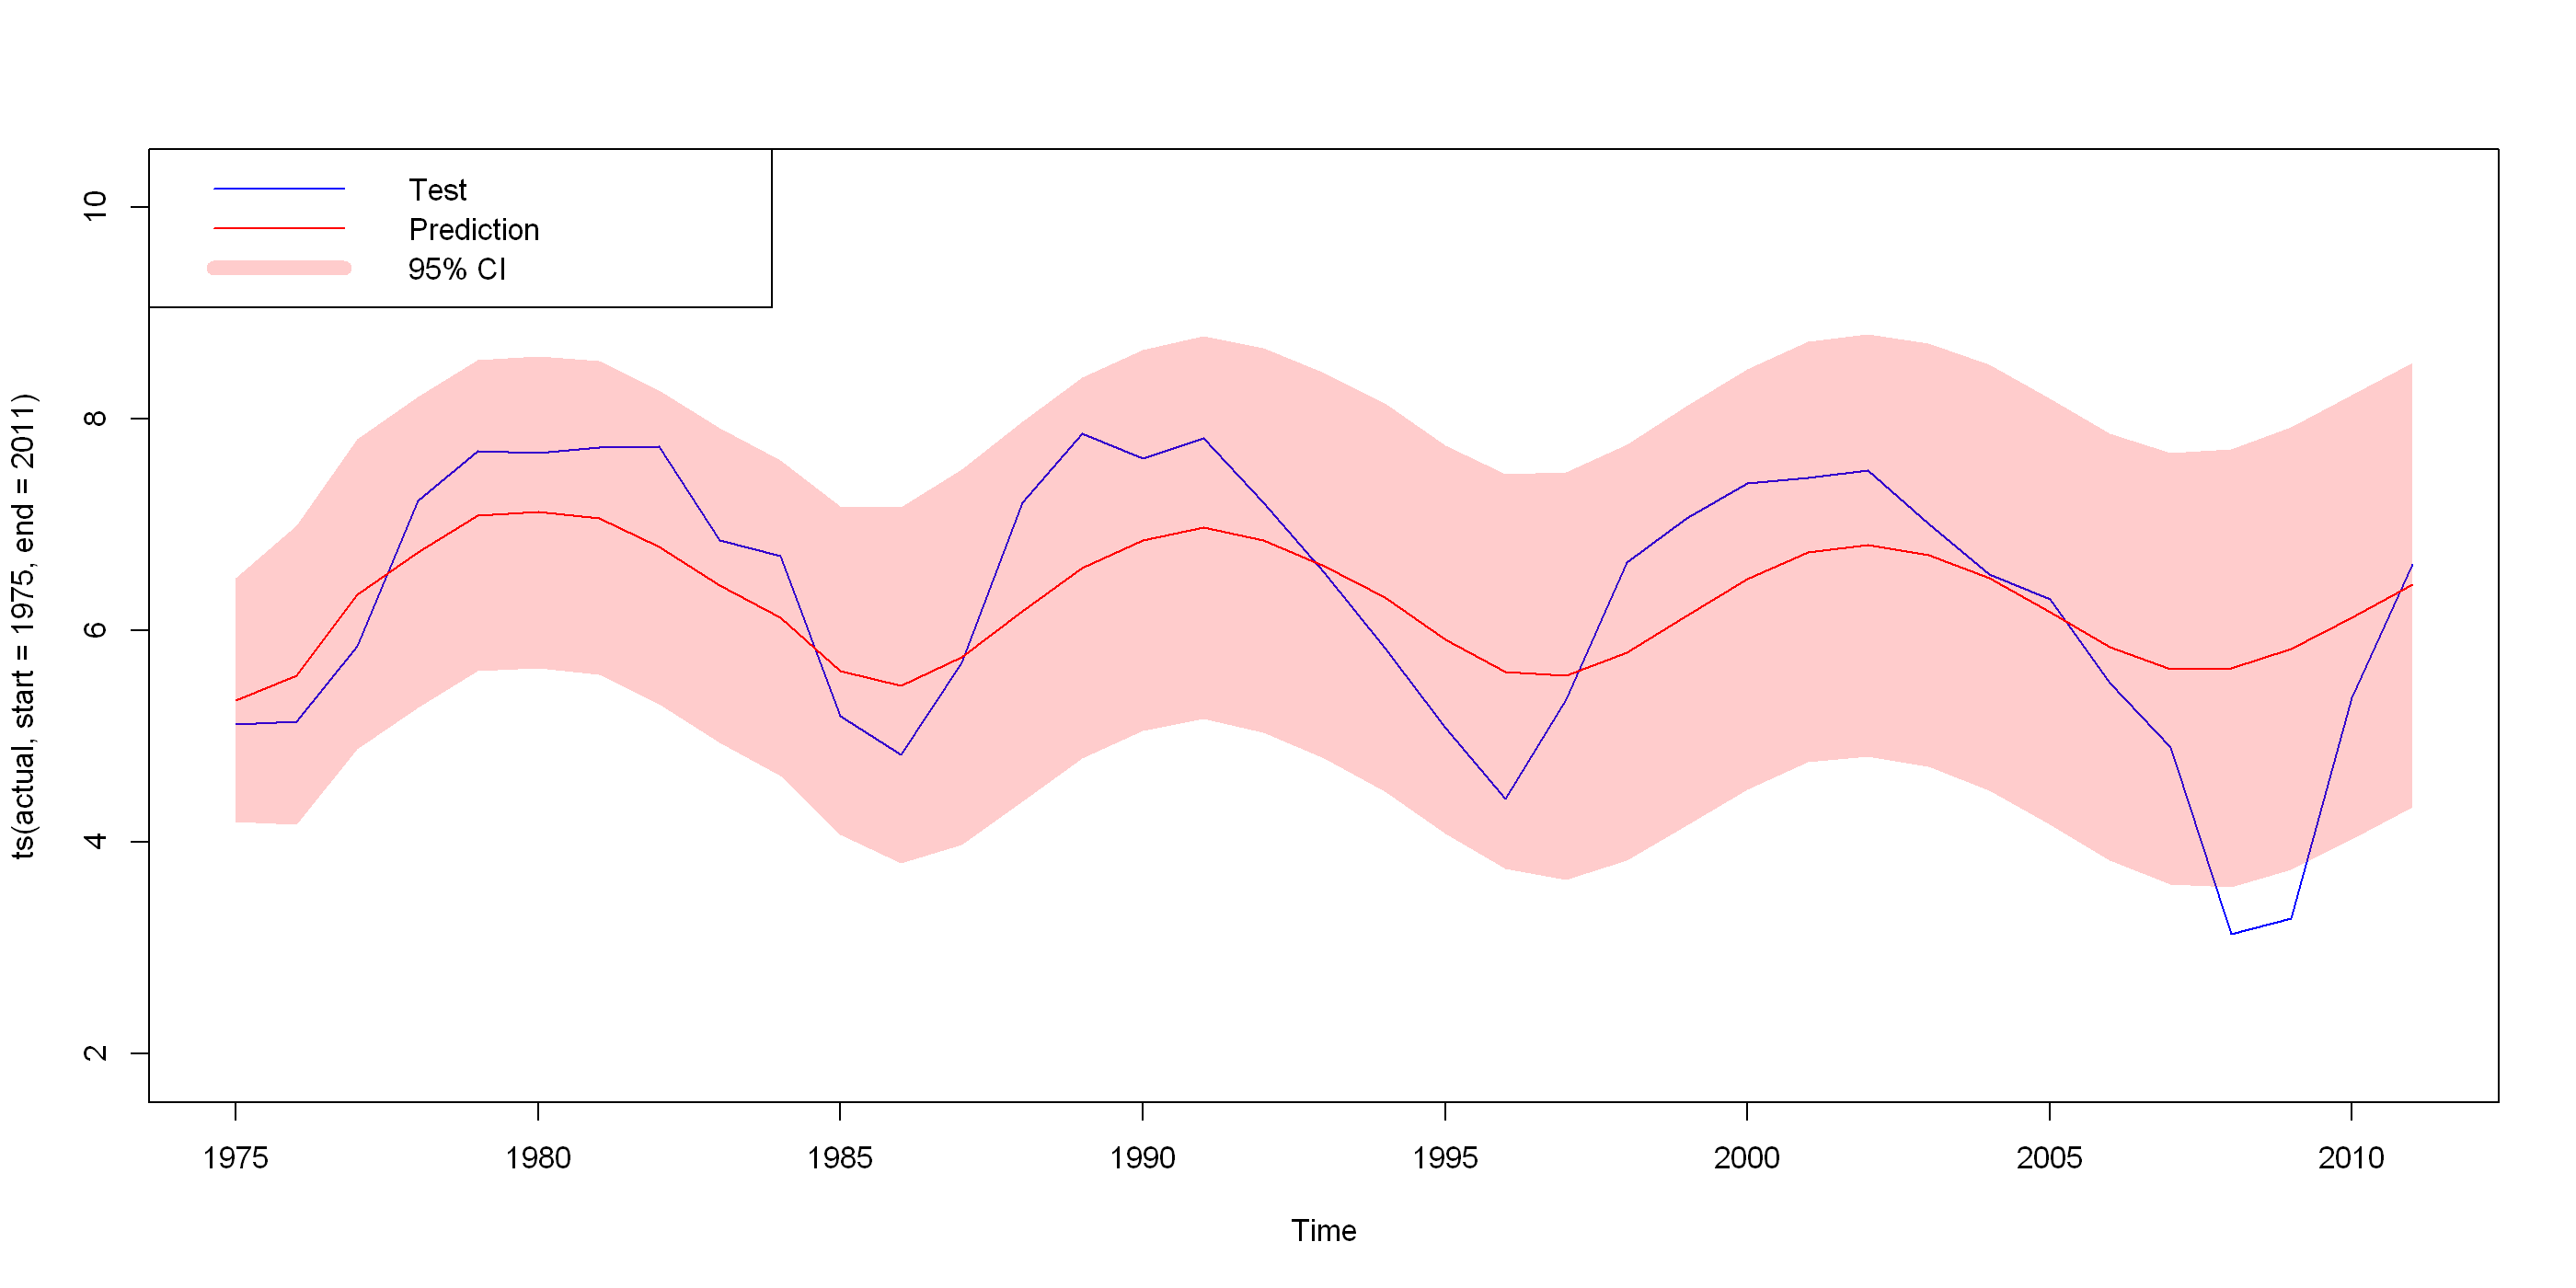

In [ ]:
plot(ts(actual,start=1975,end=2011),ylim=c(min(actual)*0.6,max(actual)*1.3),col="blue")
lines(ts(pred,start = 1975,end=2011),col="red")
# lines(dd)
# lines(dd_hat$pred,col="red")
# mu <- mean(dd)
# abline(h=mu,col="darkgreen")
alpha95 <- 0.05

z95 <- qnorm(1 - alpha95 / 2)


y_upper95_ <- pred + z95 * window(dd_hat$se,start = 1975,end=2011)
y_lower95_ <- pred- z95 * window(dd_hat$se,start = 1975,end=2011)

x_years_ <- seq(1974+1,2011)
polygon(x=c(x_years_,rev(x_years_)),
        c(y_upper95_, rev(y_lower95_)),
        col = adjustcolor("red", alpha.f = 0.2), border = NA)


legend("topleft",
    legend = c("Test","Prediction","95% CI"),
    lwd = c(1,1,8),
    col=c("blue","red",adjustcolor("red", alpha.f = 0.2)))

k <- length(pred)
mse <- (1/k)*sum((actual-pred)**2)
print(mse)


Eventhough the MSE is not very descriptive, the fit is pretty good, especially (and as argued for above) in the first 10 points, which makes sense $p=10$. The $95\%$ CI is also reasonable, out of 37 observations 2 fall out of the bounds $\approx5\%$. However, based on the above residual analysis the modelling is at best ok, there appears to be some structure left in the residuals and further they don't appear to be fully stationary.

### 2.

![ex6_2.png](ex6_2.png)

In [13]:
t.url <- "http://stat.ethz.ch/Teaching/Datasets/WBL/varve.dat"
d.varve <- ts(scan(t.url)[201:550])


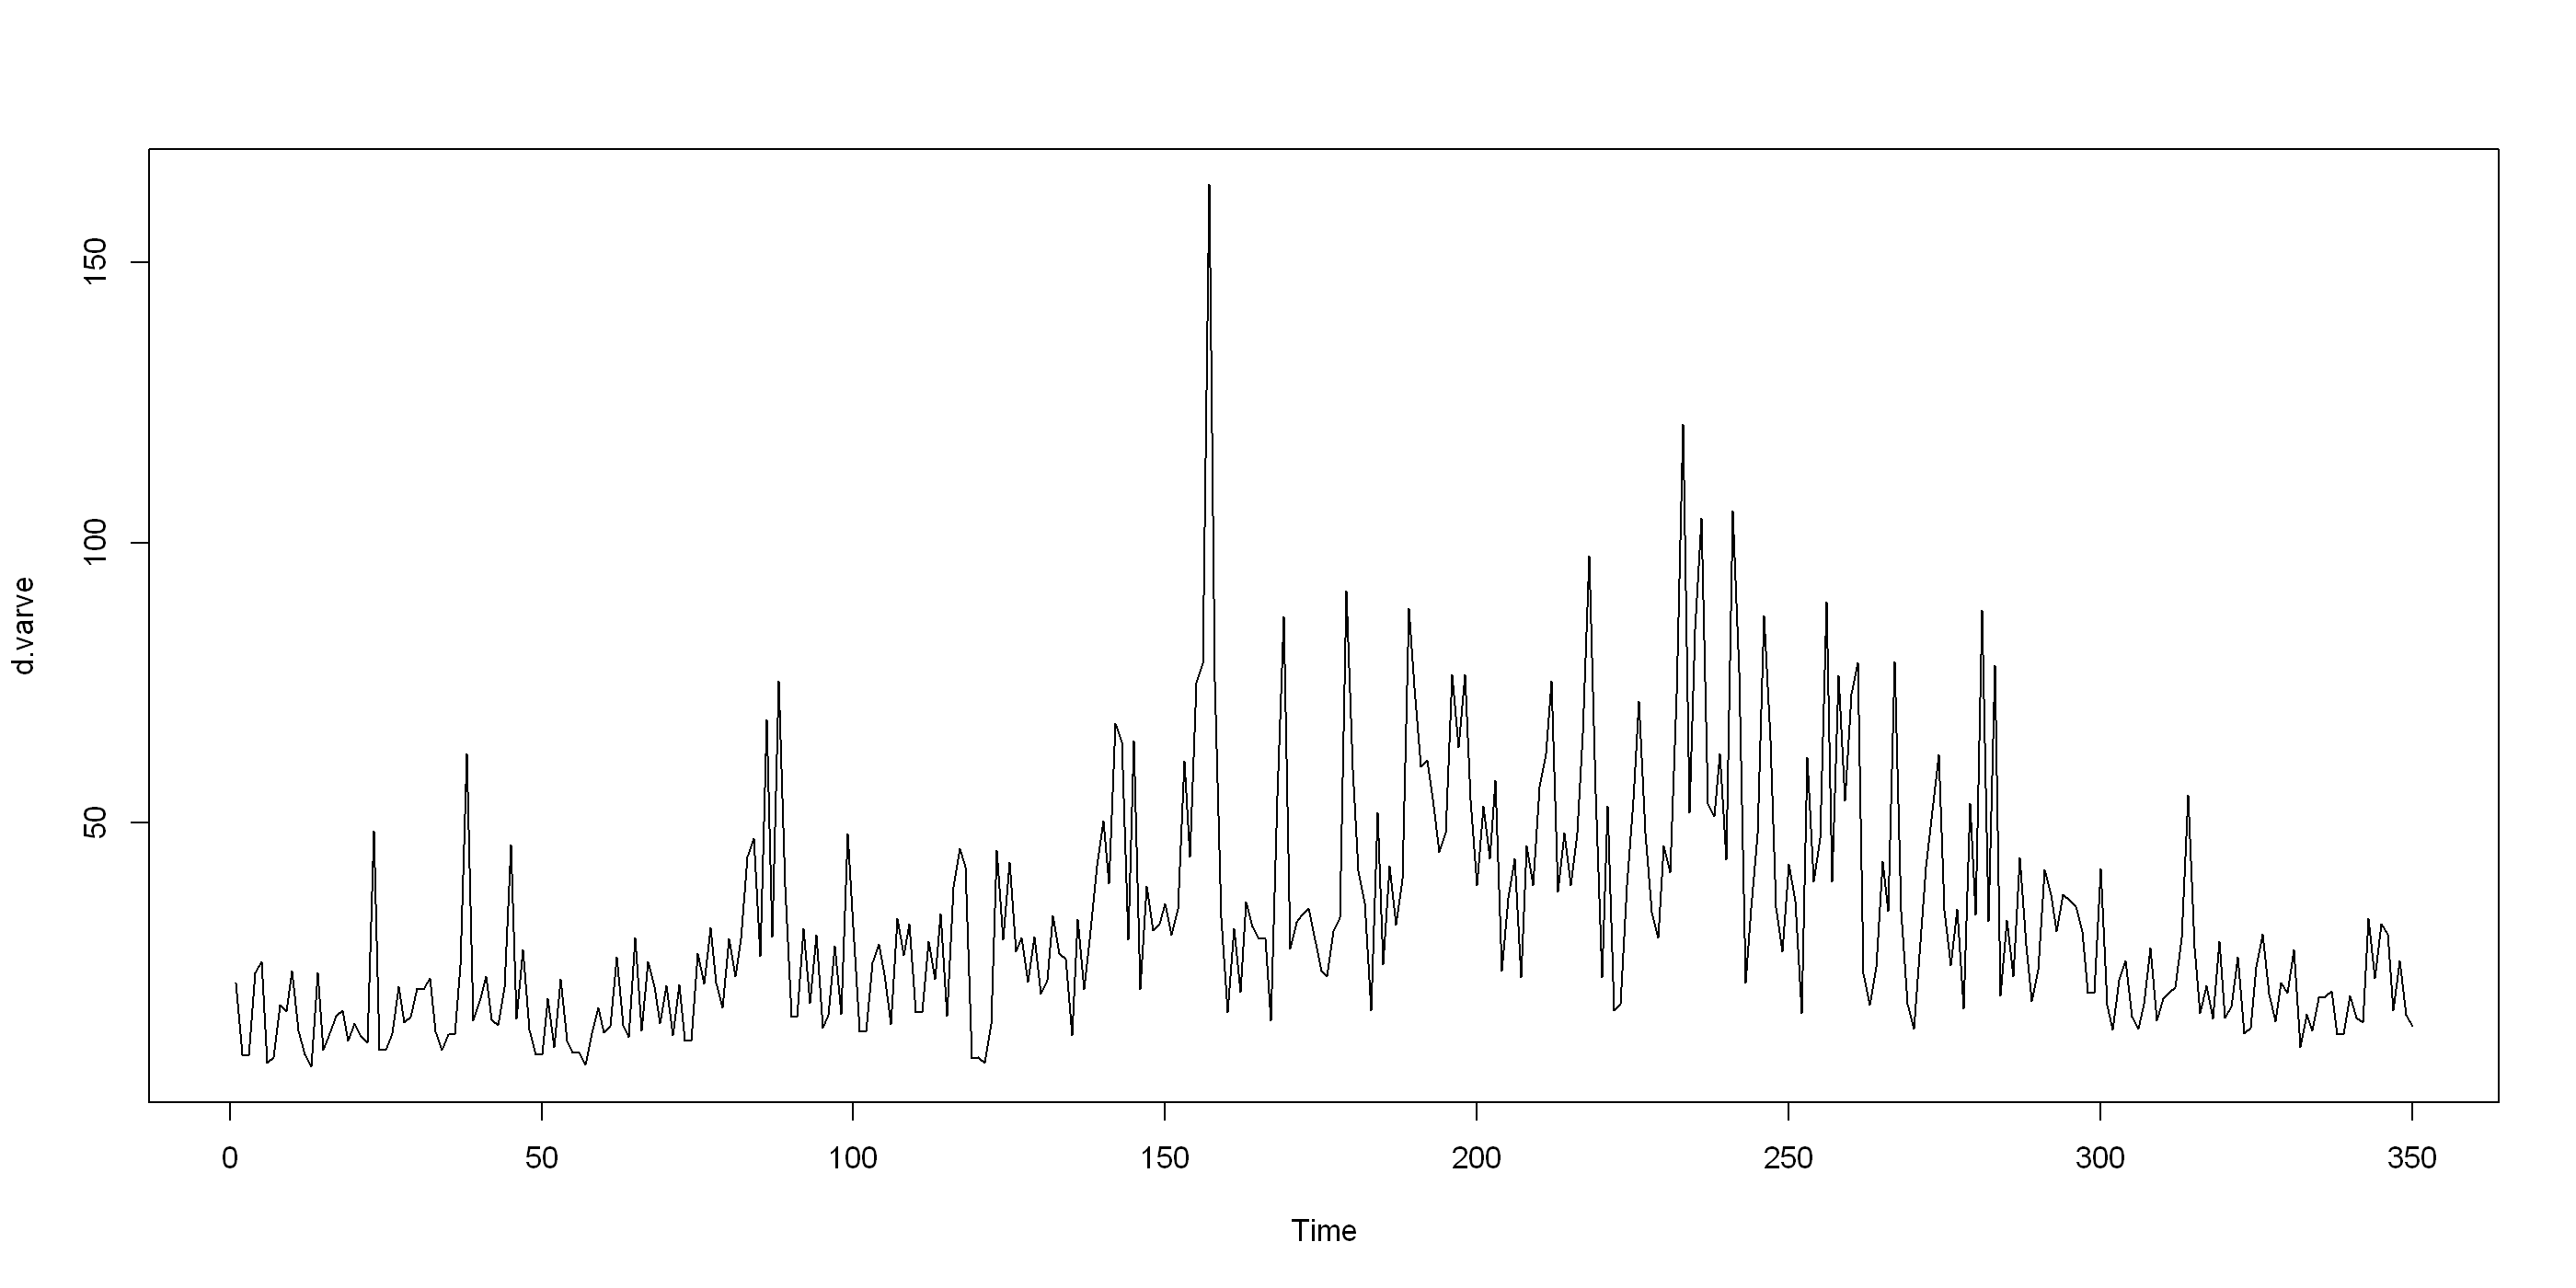

In [14]:
plot(d.varve)

The combination is very typical, the data a has peak, clusters, weird u-shaped trend, is on a relative scale and is clearly not stationary, the difference should together with the log transform address all issues, if we only log-transform, we would not fix the clustering issue, nor the u-shape, but should be able handle the relative scale issue and peaks, and similarly the difference should handle the clustering and the weird shape and apart from the scaling look closer to being stationary.

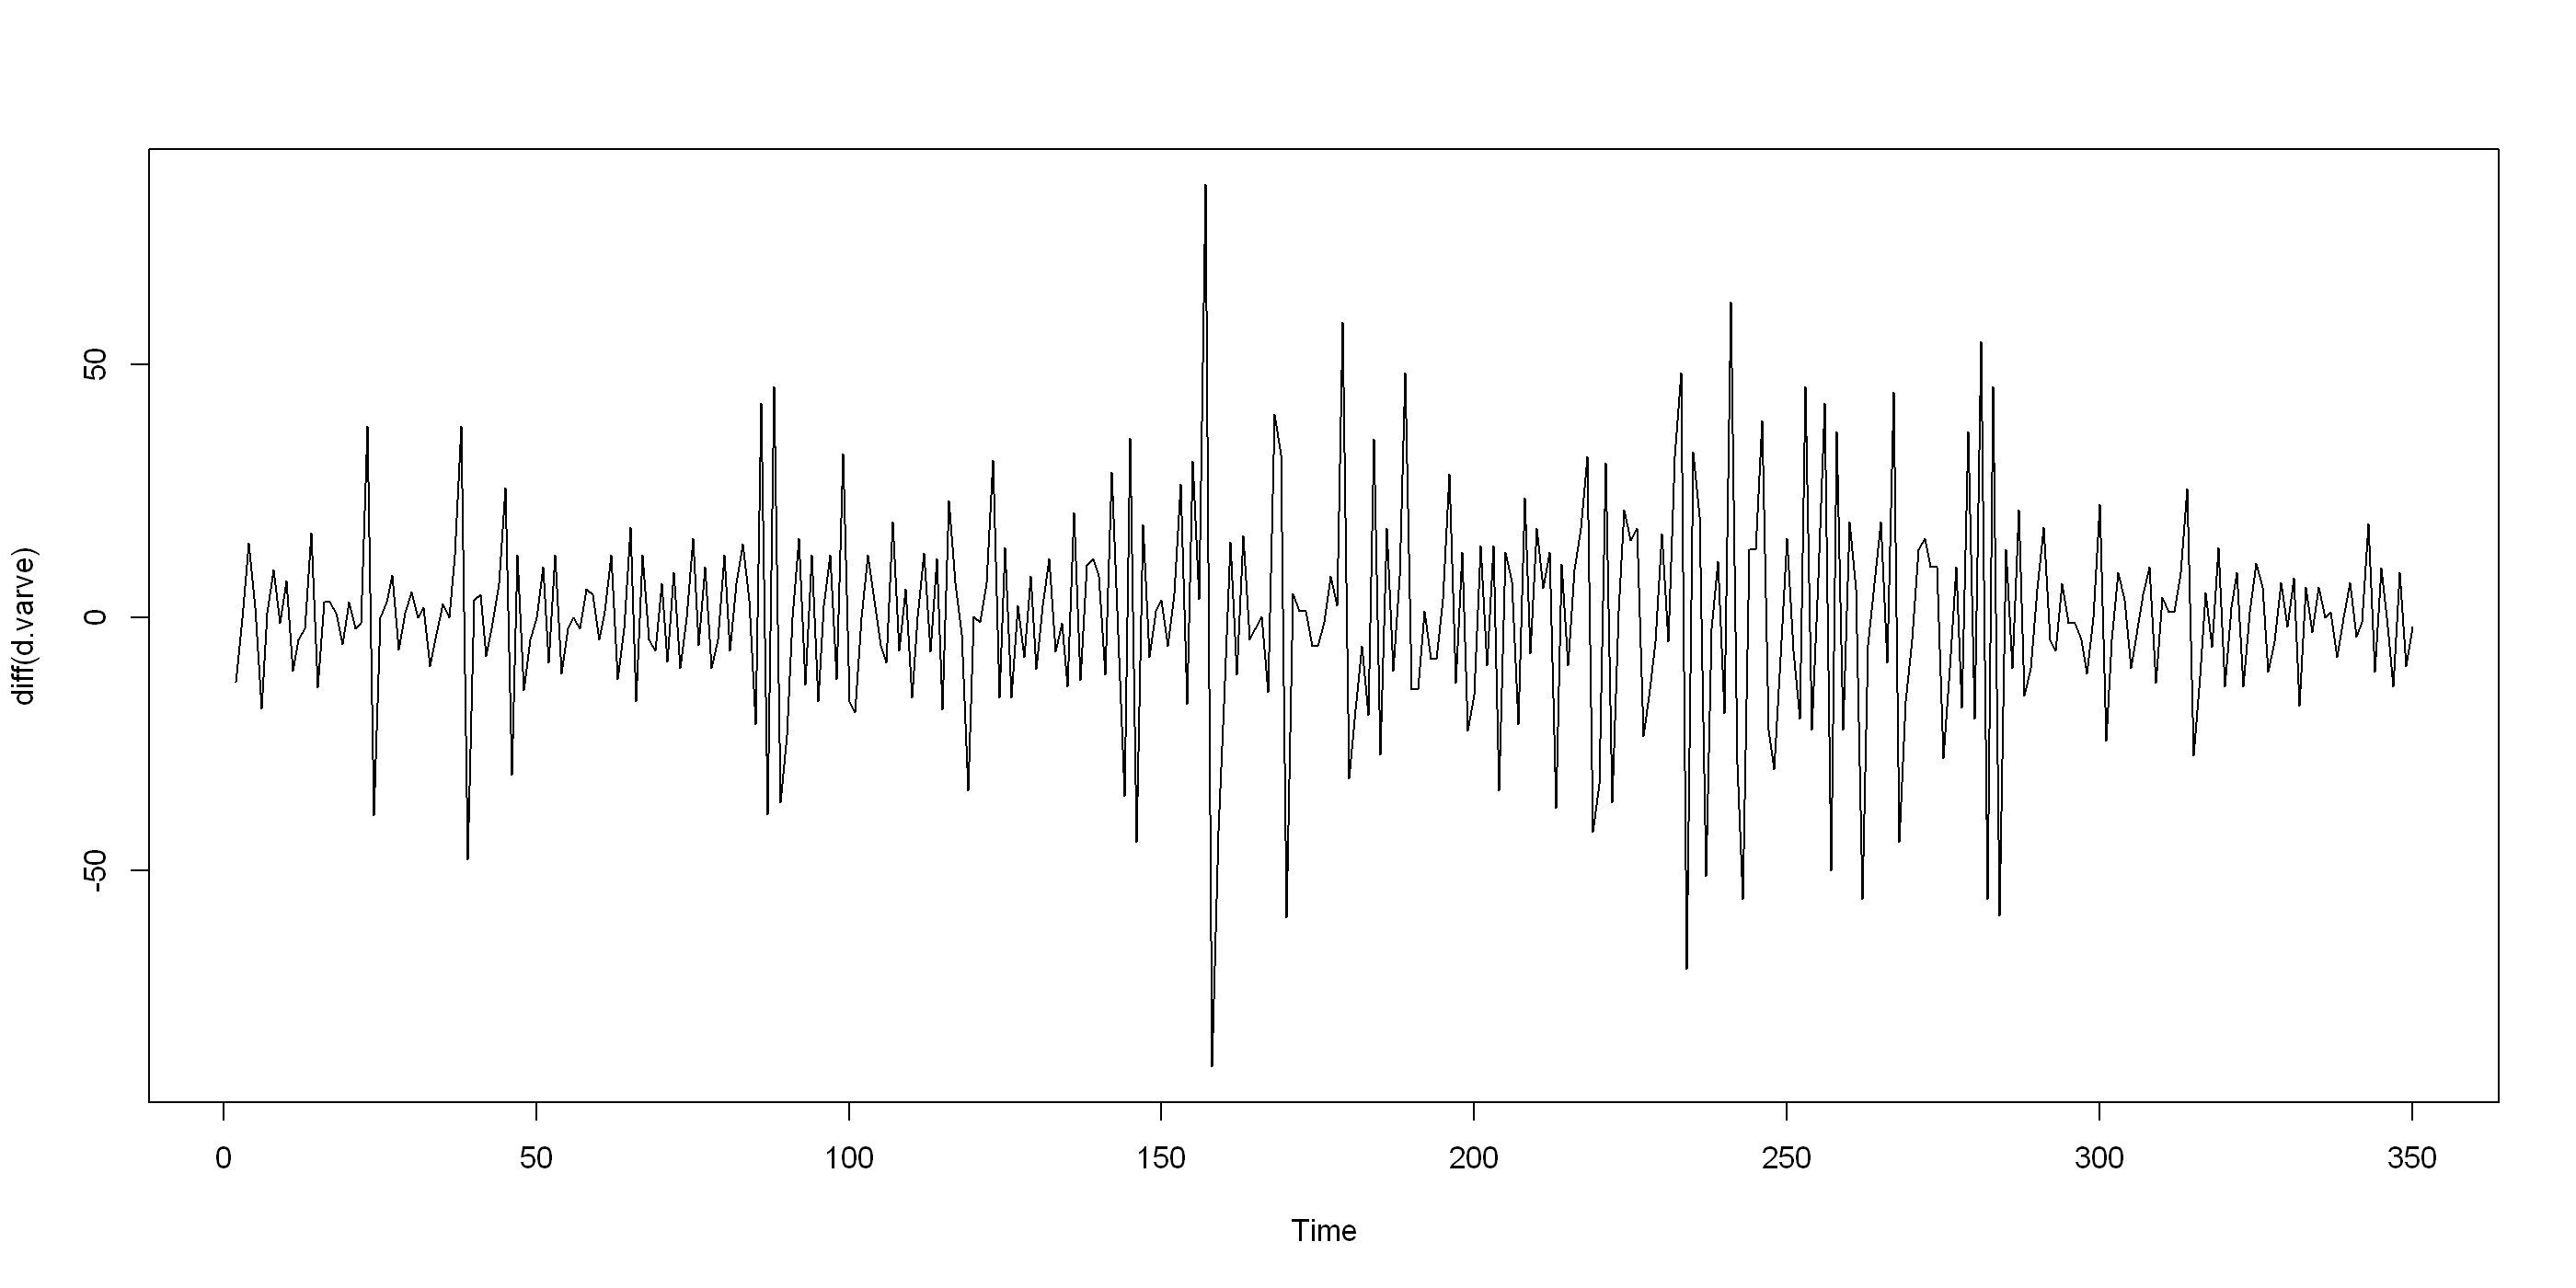

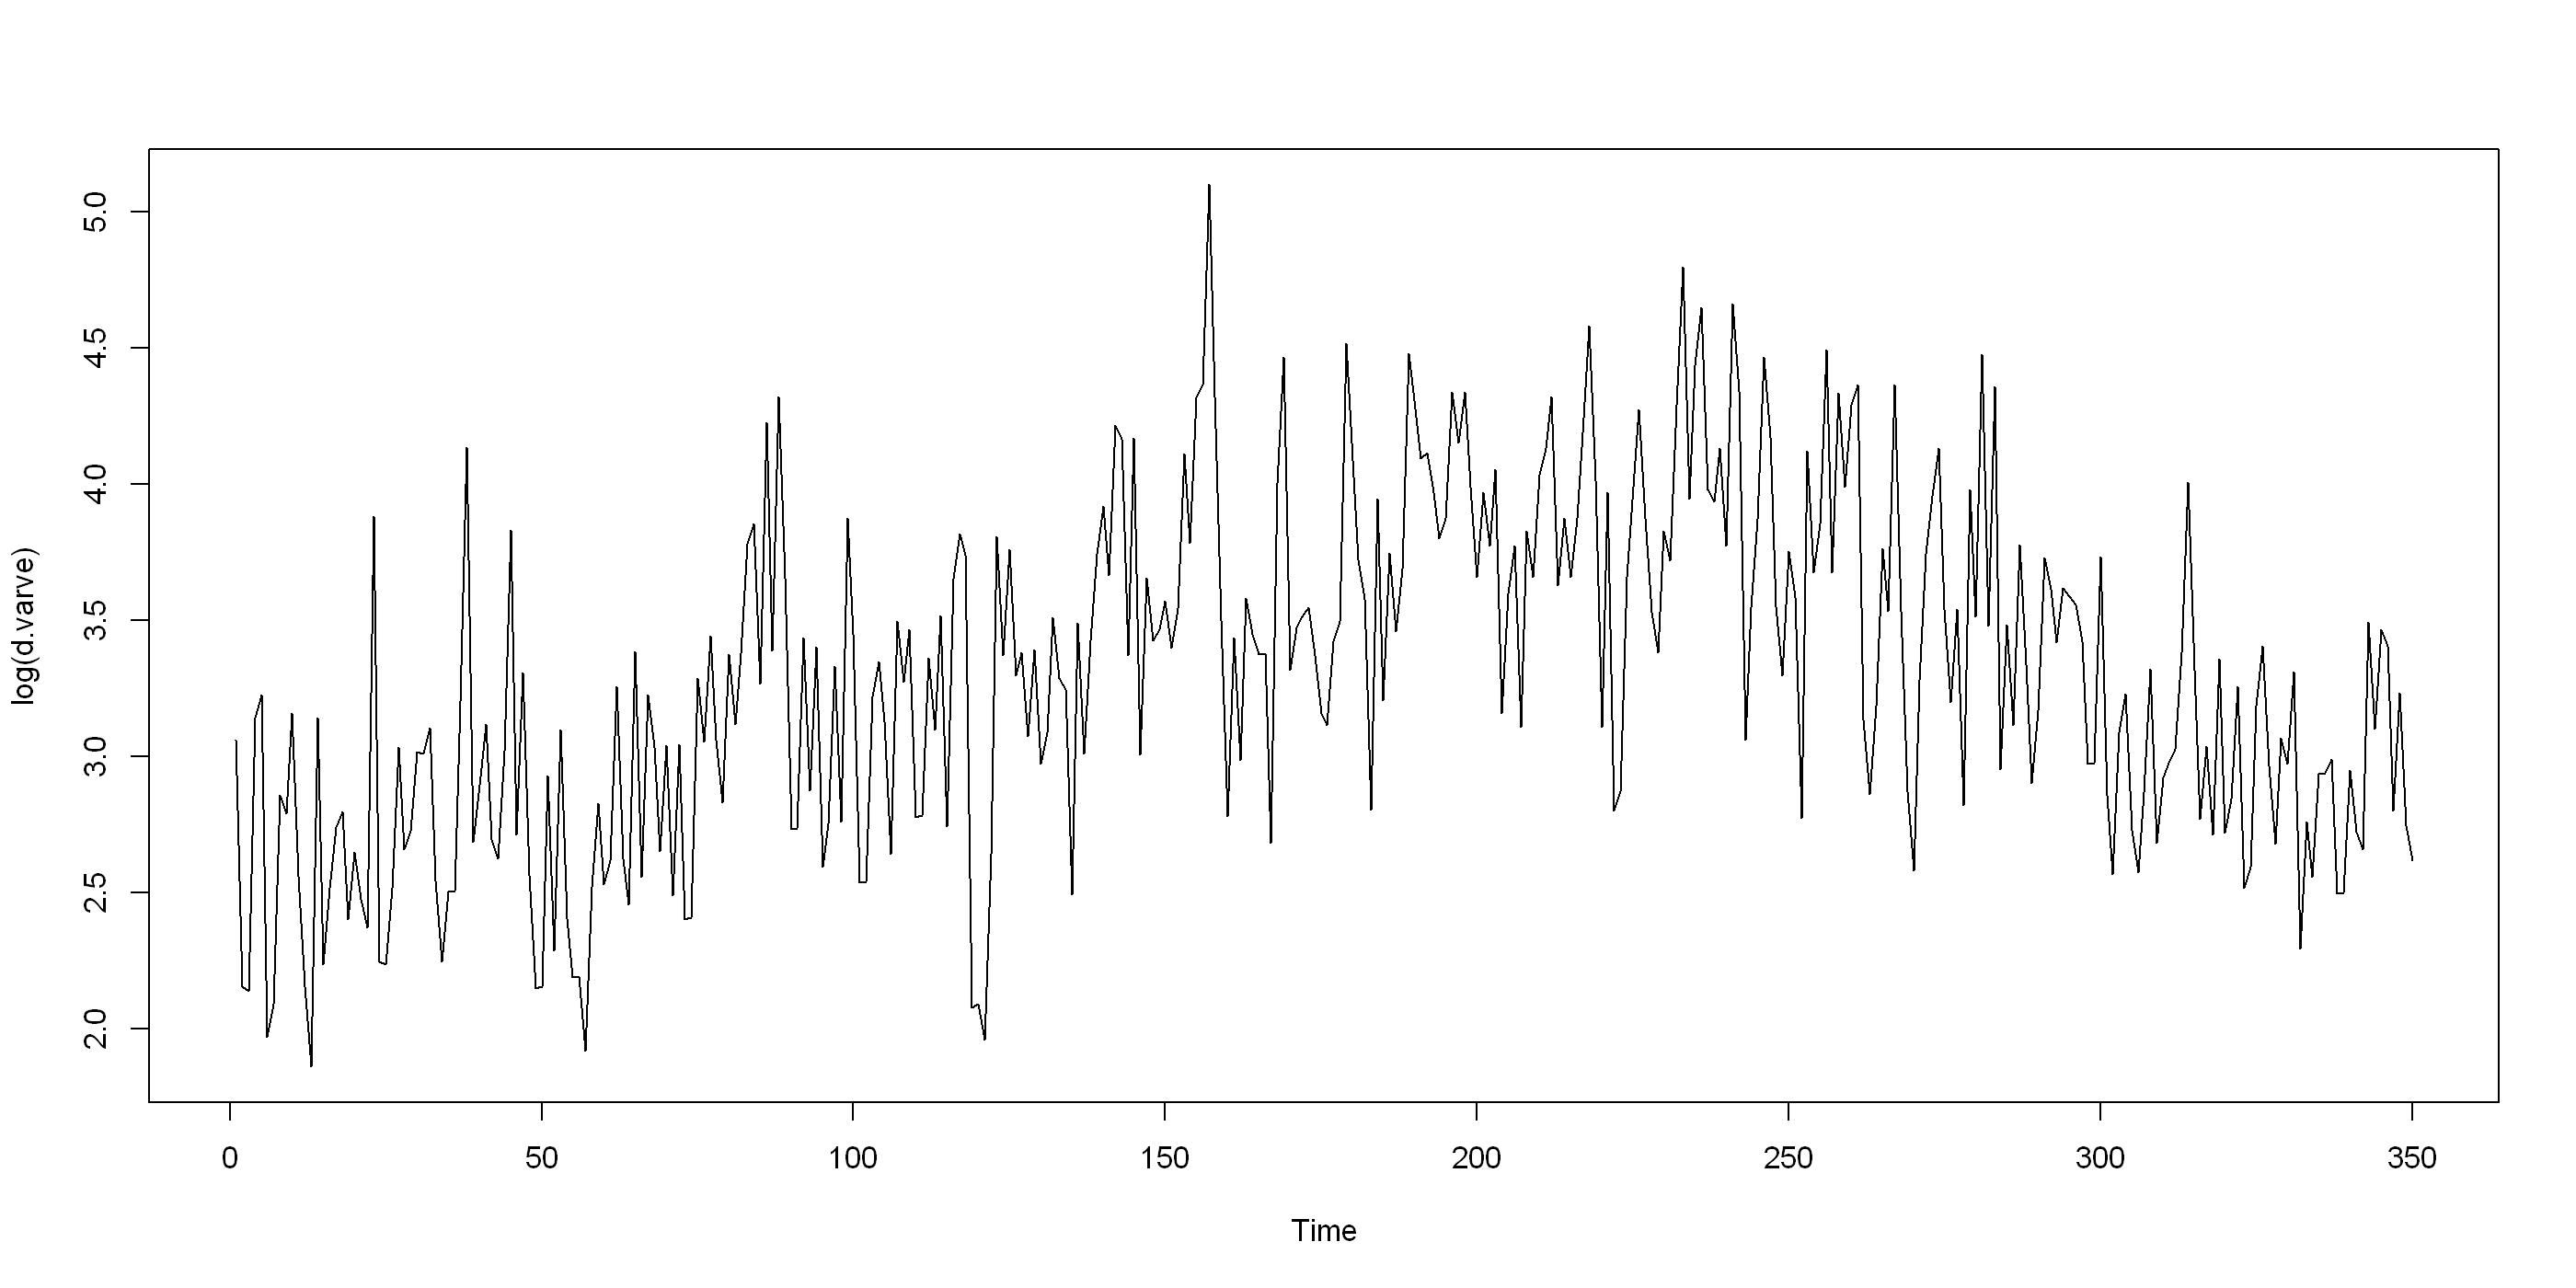

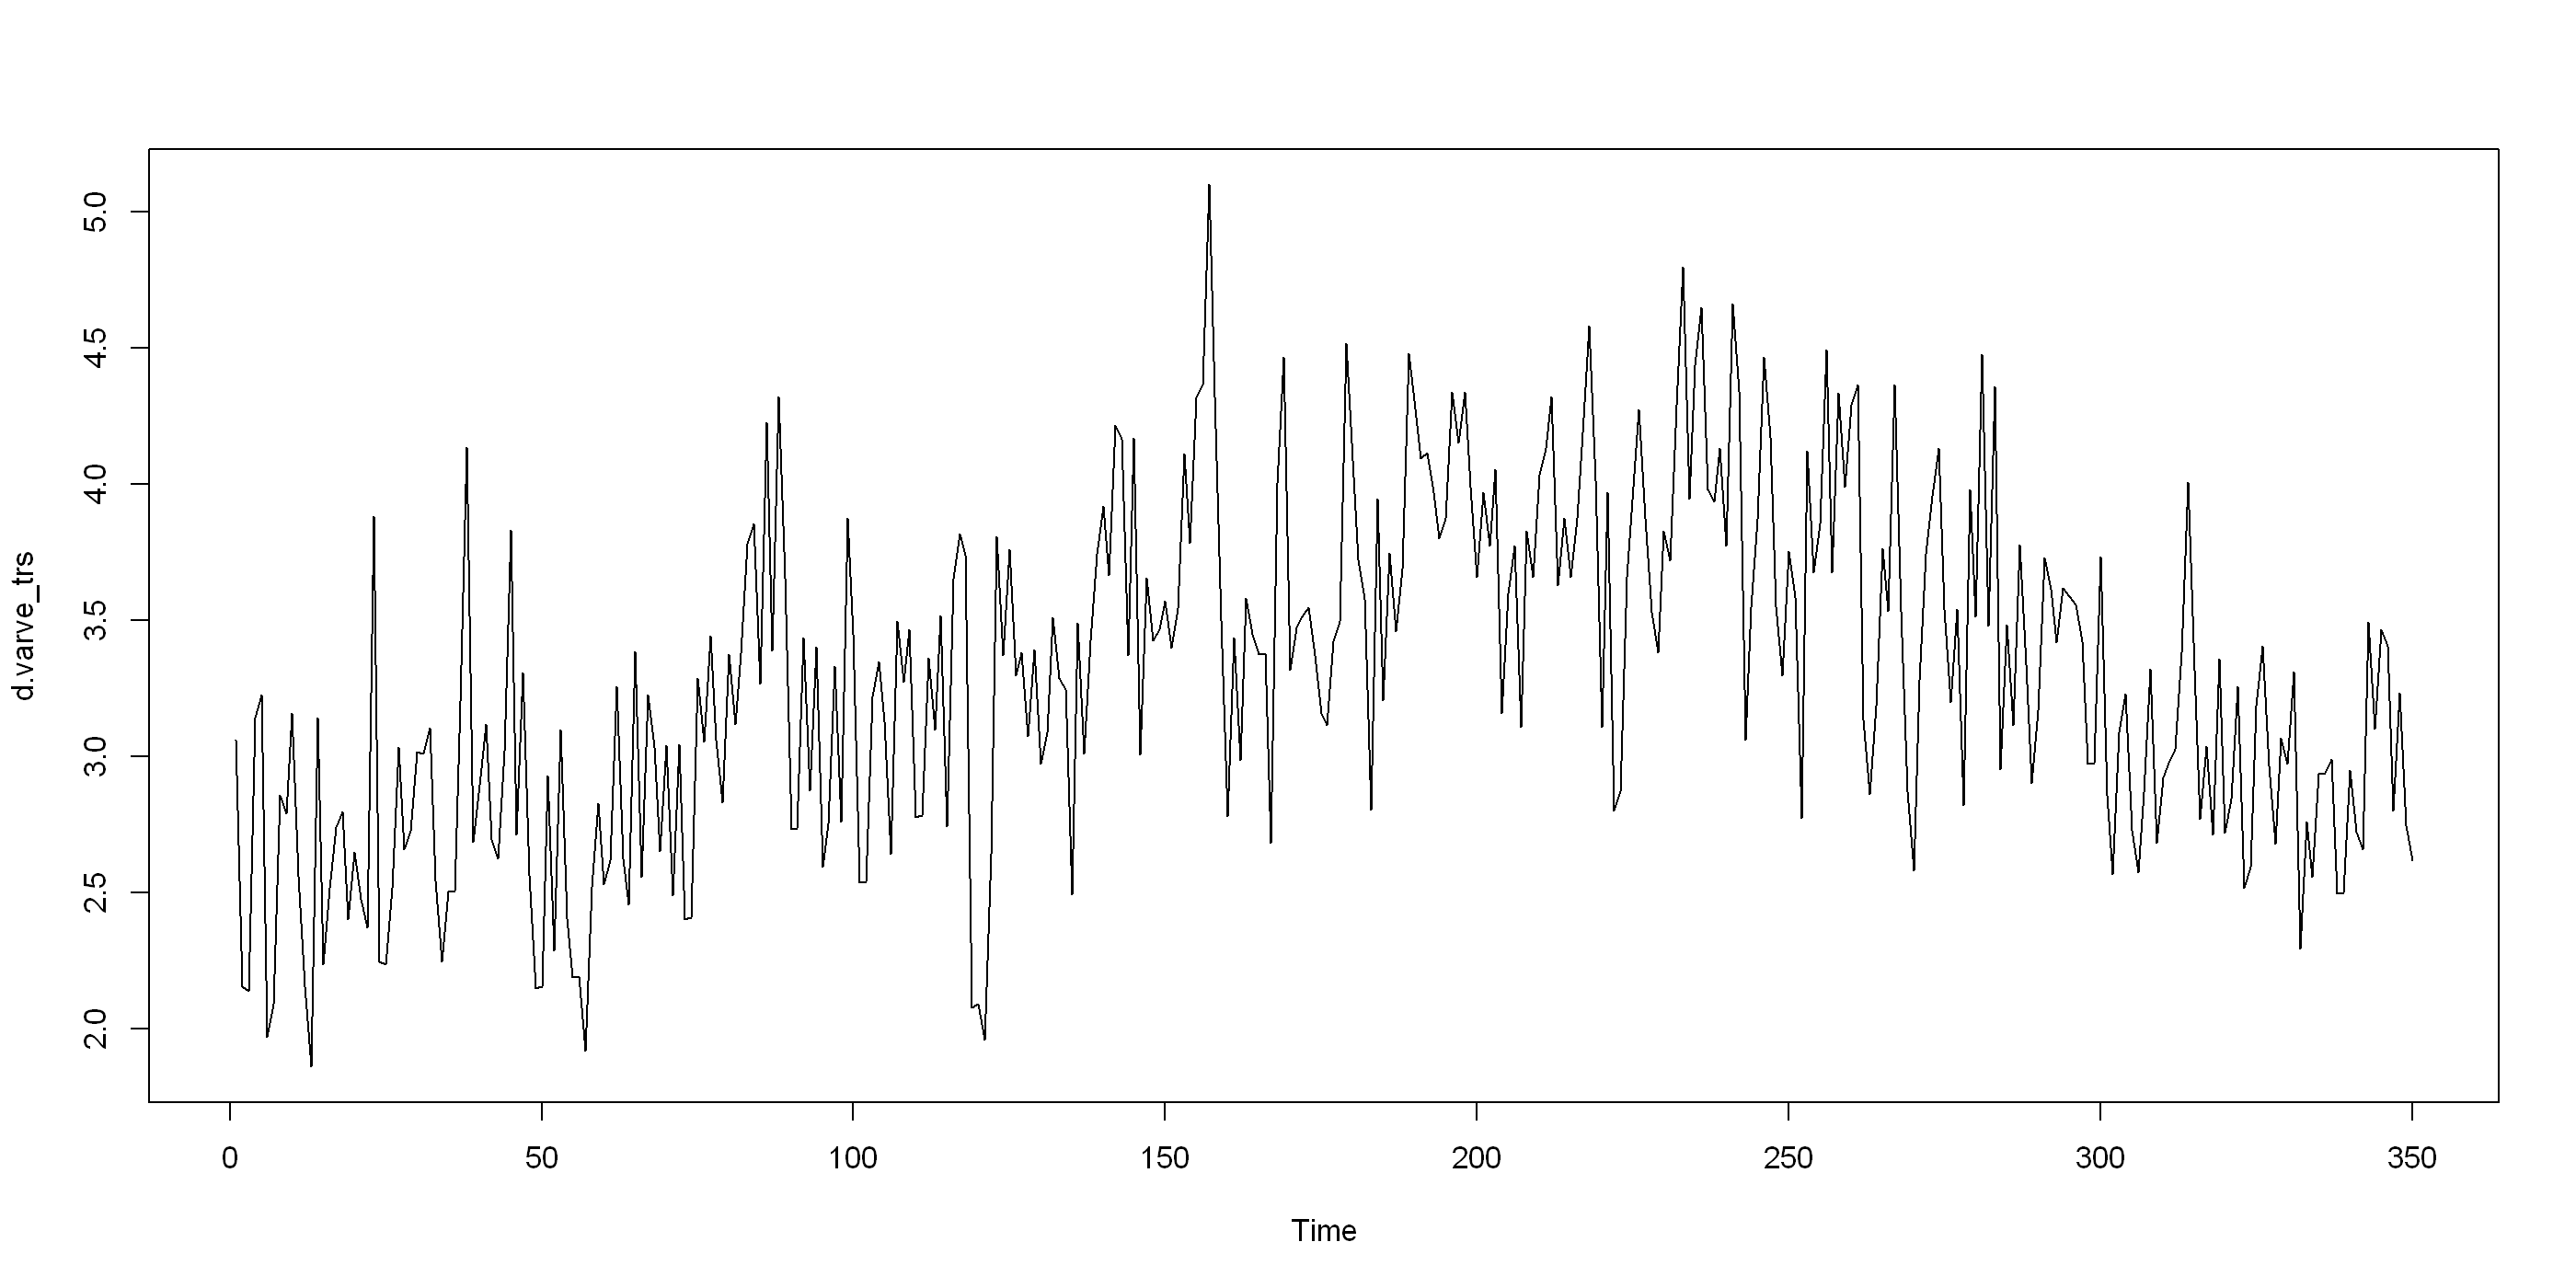

In [15]:
plot(diff(d.varve))
plot(log(d.varve))
d.varve_trs <- ((log(d.varve)))
d.varve_trs_diff <- (diff(log(d.varve)))
plot(d.varve_trs)

Roughly speaking it looks stationary, no serious arguments against, i.e. all of the above issues clearly addressed.

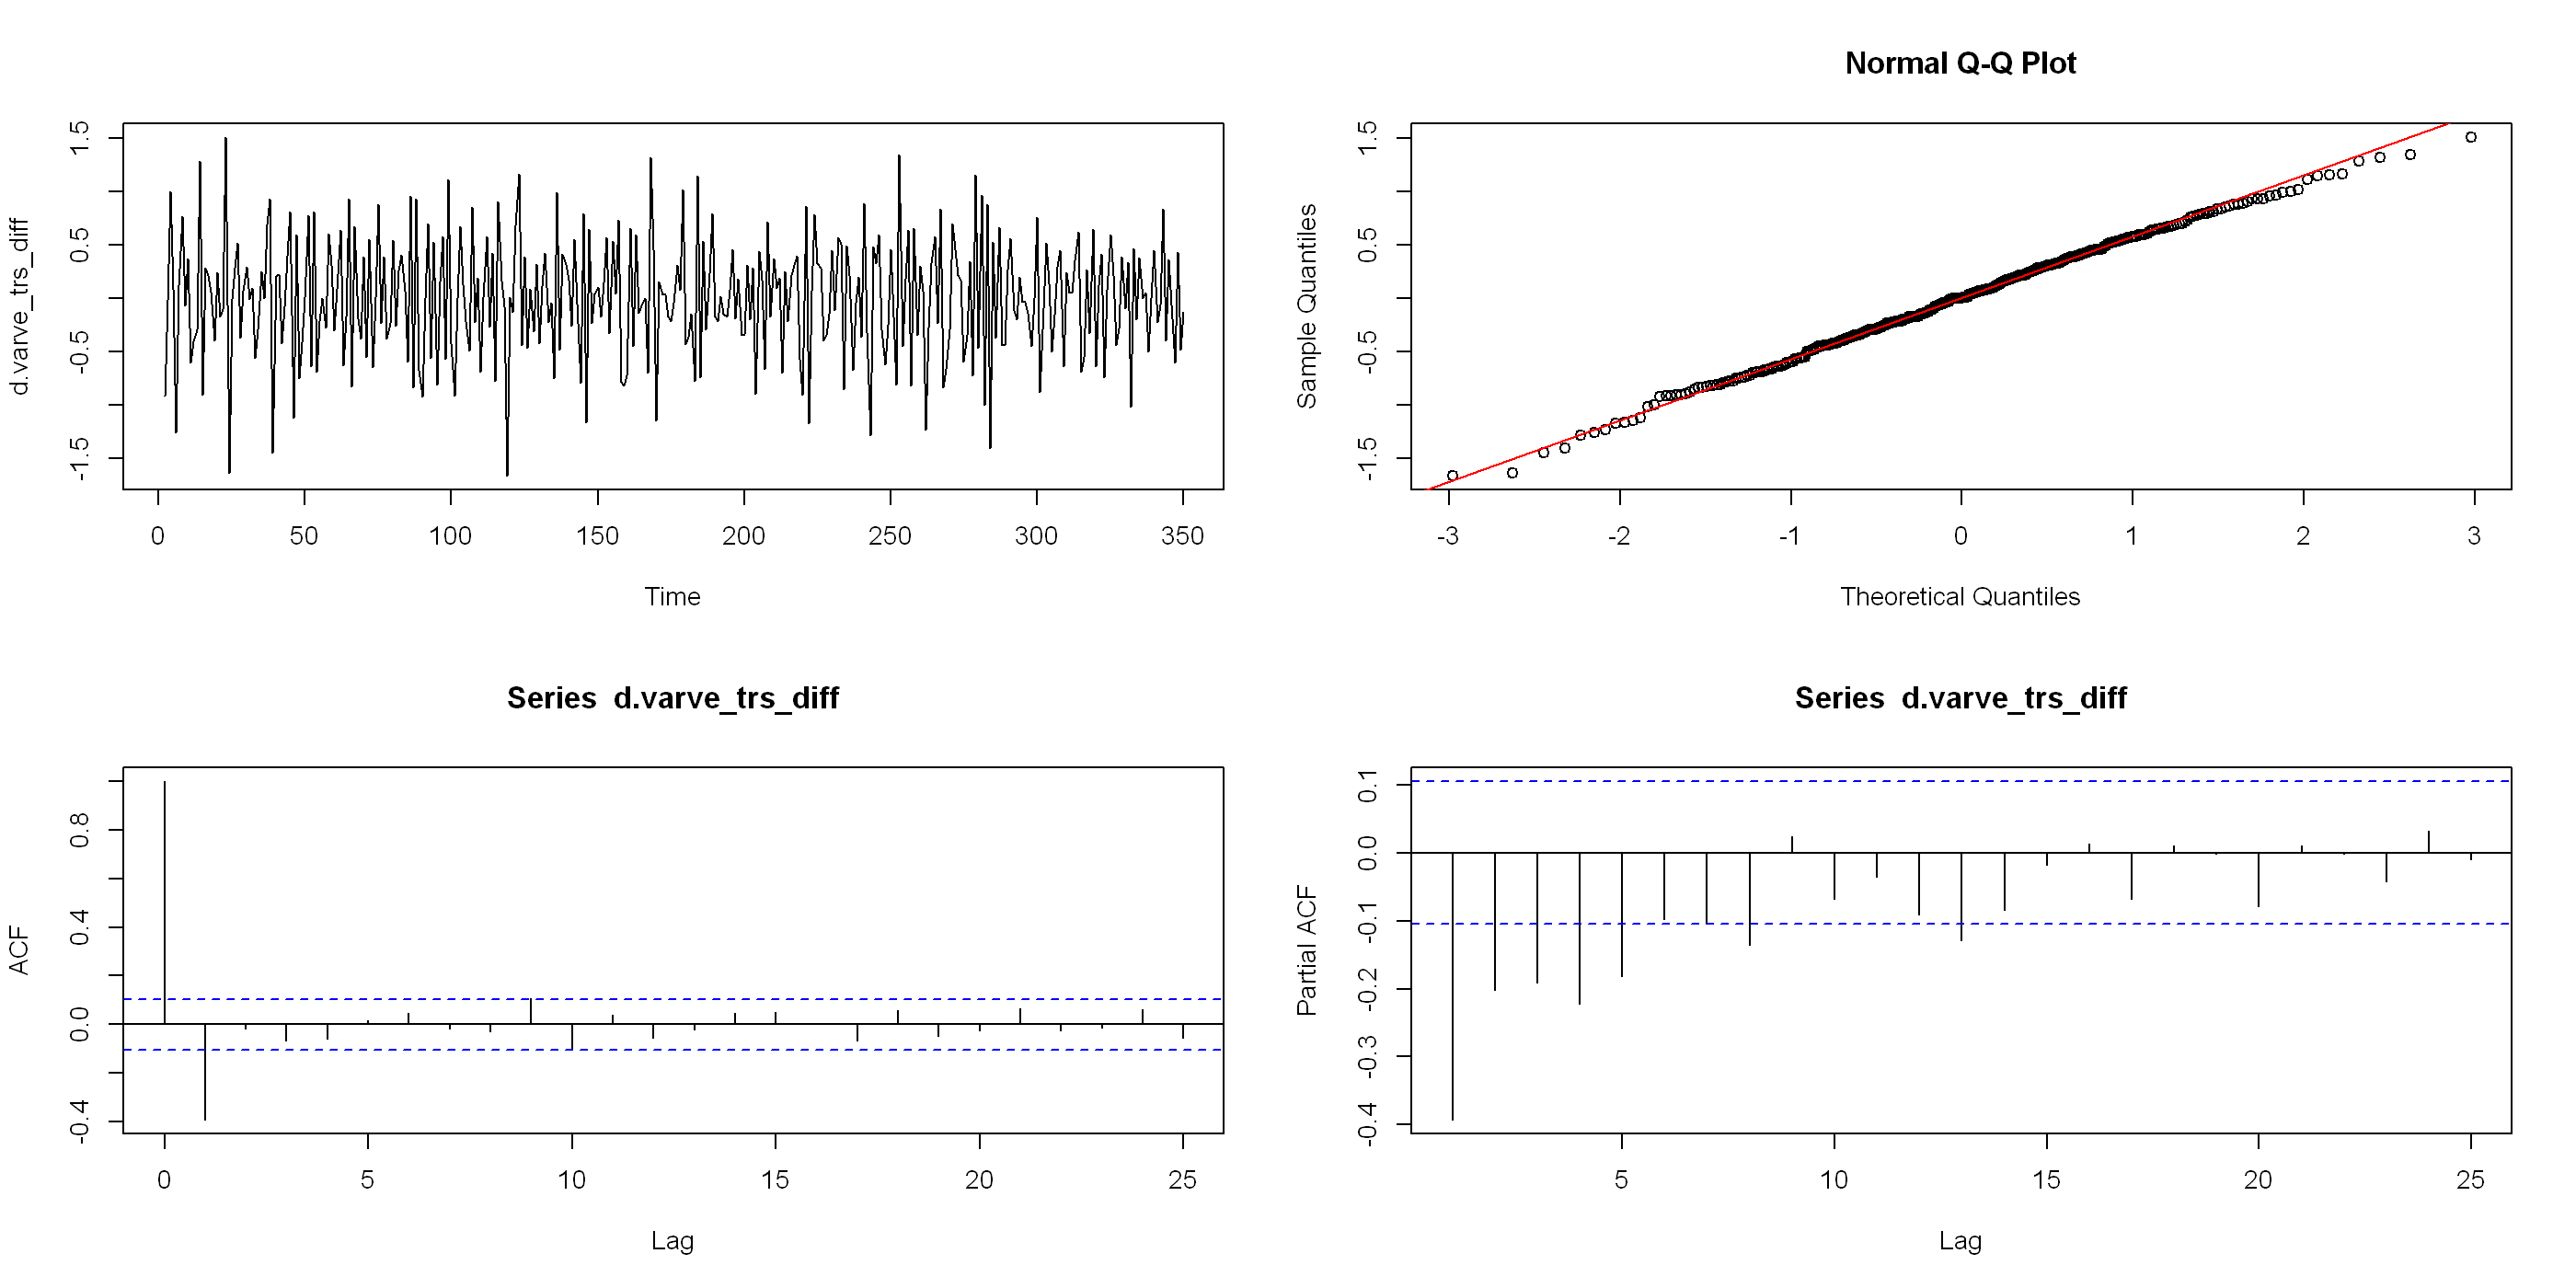

In [16]:
par(mfrow = c(2,2))
plot(d.varve_trs_diff)
qqnorm(d.varve_trs_diff)
qqline(d.varve_trs_diff,col="red")
acf(d.varve_trs_diff)
pacf(d.varve_trs_diff)

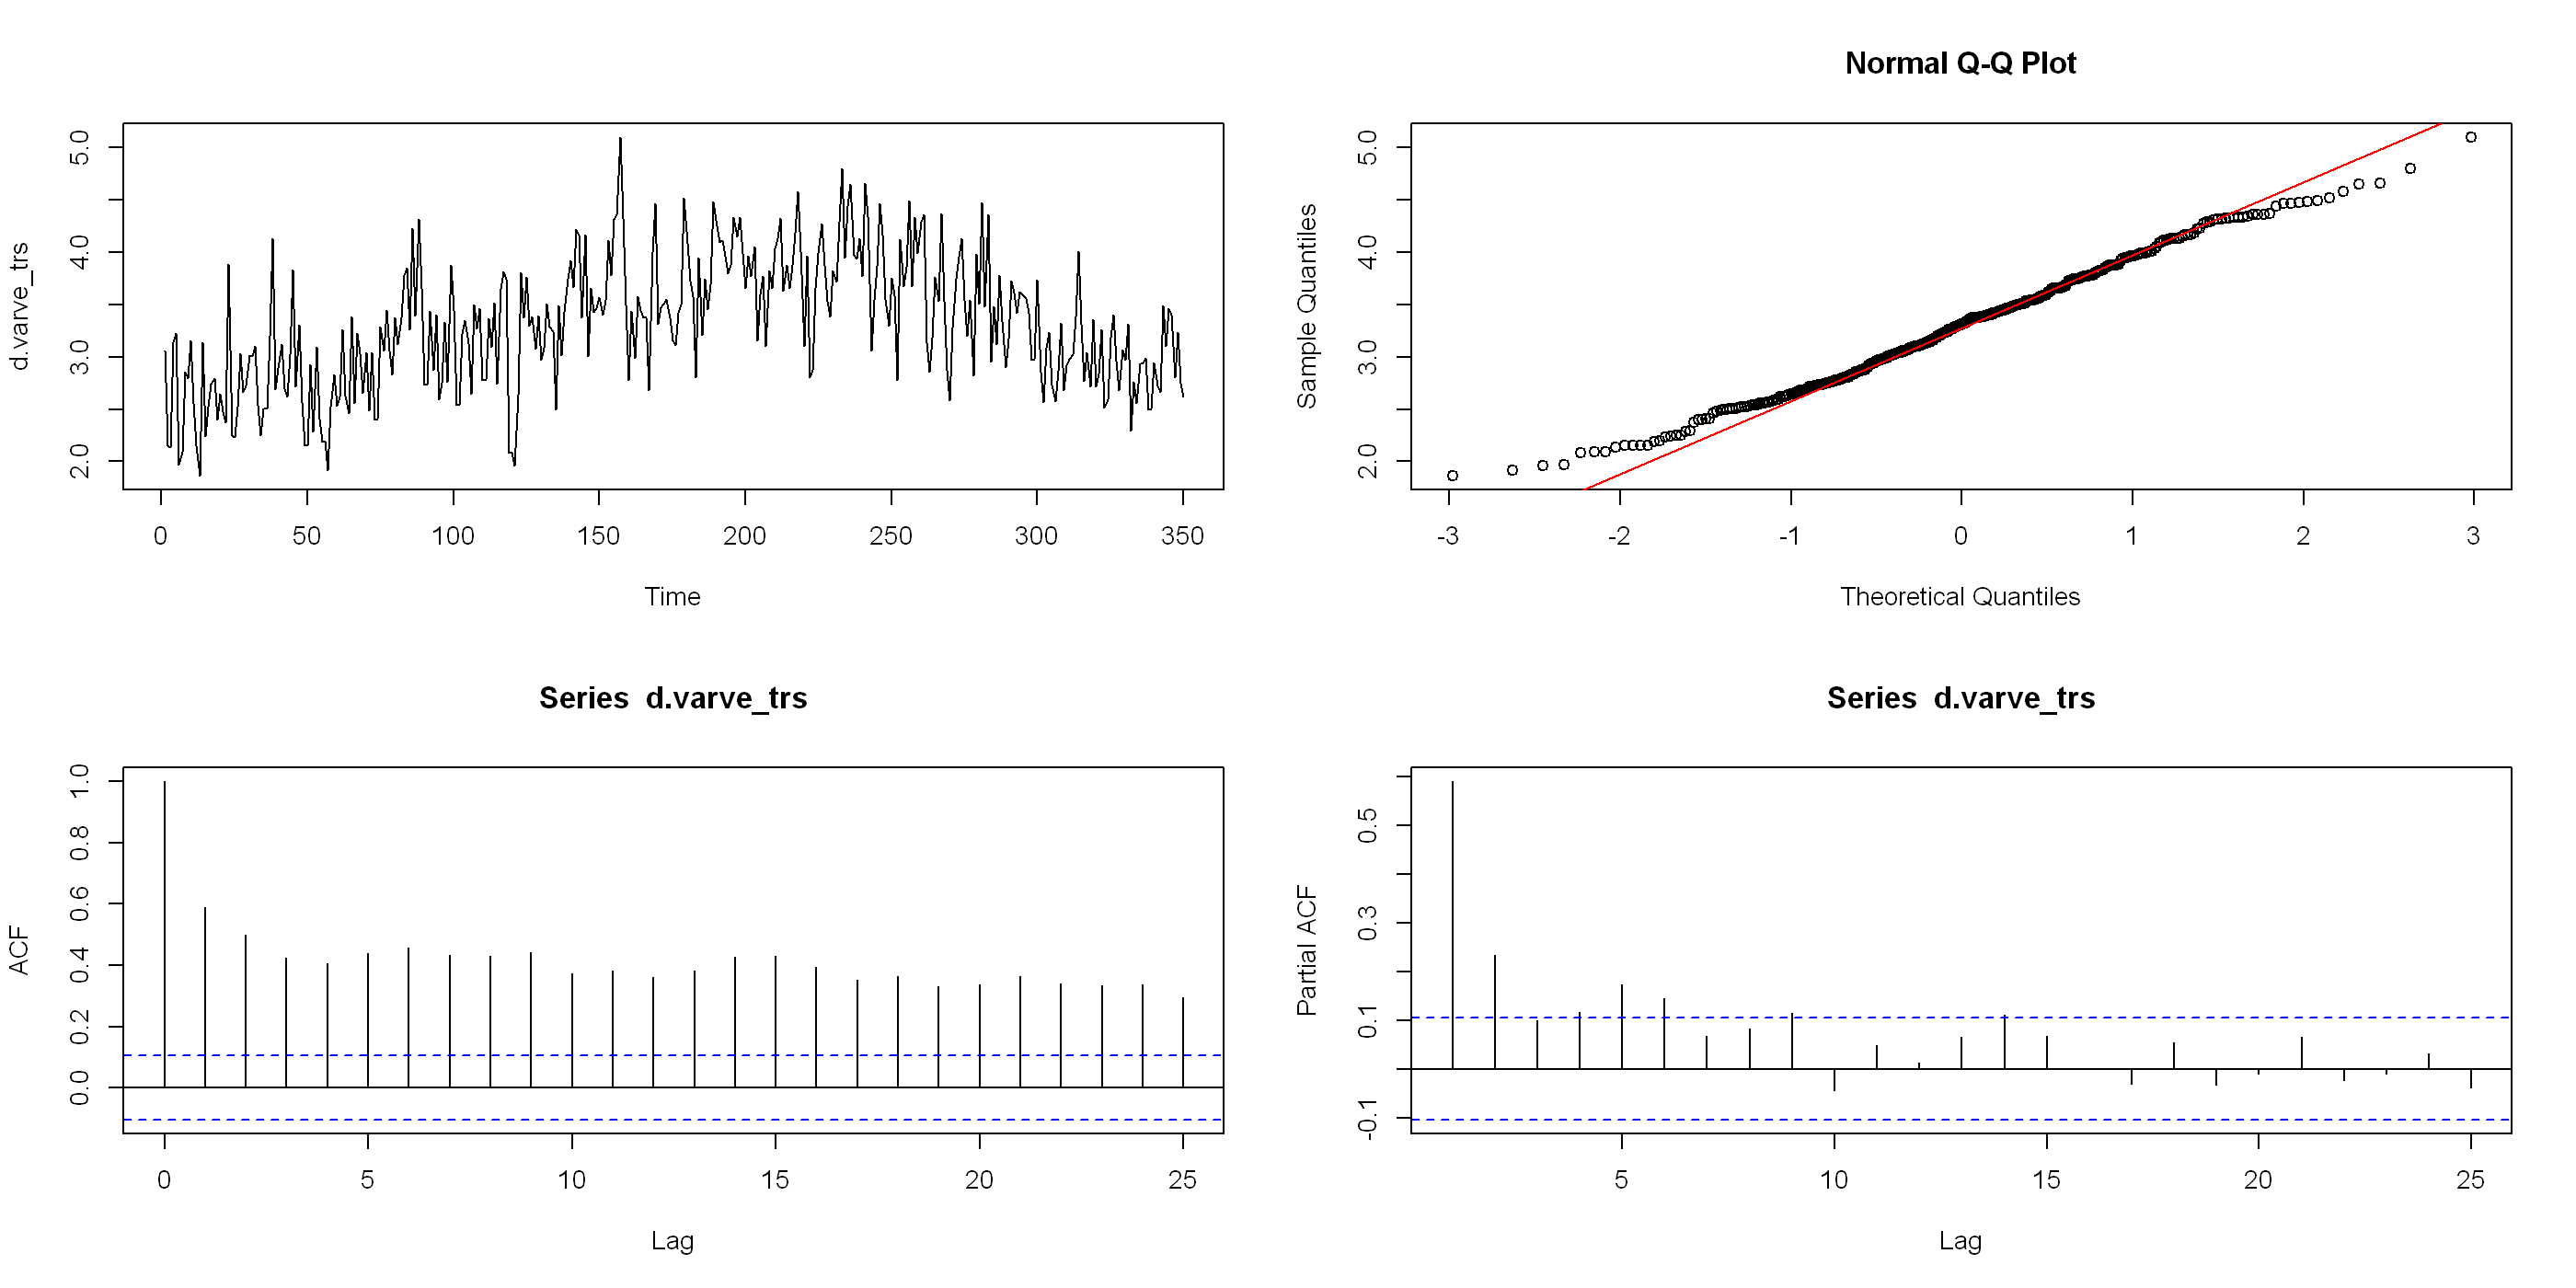

In [17]:
par(mfrow = c(2,2))
plot(d.varve_trs)
qqnorm(d.varve_trs)
qqline(d.varve_trs,col="red")
acf(d.varve_trs)
pacf(d.varve_trs)

Based on the above (and the afore) we clearly need a combination of AR and MA + differencing (based on the afore d=1), roughly speaking low $q$ of maybe $1,2,3$ or around and a higher $p$ of at least $2$, possibly all the way up to $9$ or so. We consider the auto fit, to quickly compare this on a grid.

In [18]:
auto.arima(y = d.varve_trs,max.p = 9,max.q = 6,max.d = 3,trace = TRUE,ic = "aic",stepwise = FALSE, approximation = FALSE,max.order = 10)


 ARIMA(0,1,0)                    : 589.6807
 ARIMA(0,1,0) with drift         : 591.6789
 ARIMA(0,1,1)                    : 473.5307
 ARIMA(0,1,1) with drift         : 475.4713
 ARIMA(0,1,2)                    : 461.6743
 ARIMA(0,1,2) with drift         : 463.5803
 ARIMA(0,1,3)                    : 459.6819
 ARIMA(0,1,3) with drift         : 461.5804
 ARIMA(0,1,4)                    : 461.6717
 ARIMA(0,1,4) with drift         : 463.5695
 ARIMA(0,1,5)                    : 461.793
 ARIMA(0,1,5) with drift         : 463.6998
 ARIMA(0,1,6)                    : 463.6599
 ARIMA(0,1,6) with drift         : 465.568
 ARIMA(1,1,0)                    : 532.8627
 ARIMA(1,1,0) with drift         : 534.8622
 ARIMA(1,1,1)                    : 459.304
 ARIMA(1,1,1) with drift         : 461.2019
 ARIMA(1,1,2)                    : 461.0124
 ARIMA(1,1,2) with drift         : 462.9084
 ARIMA(1,1,3)                    : 461.6773
 ARIMA(1,1,3) with drift         : 463.5755
 ARIMA(1,1,4)                    :

Series: d.varve_trs 
ARIMA(3,1,3) 

Coefficients:
          ar1      ar2     ar3      ma1     ma2      ma3
      -0.6170  -0.6893  0.2820  -0.0495  0.1744  -0.8954
s.e.   0.0607   0.0694  0.0604   0.0295  0.0428   0.0389

sigma^2 = 0.2111:  log likelihood = -221.97
AIC=457.94   AICc=458.27   BIC=484.93

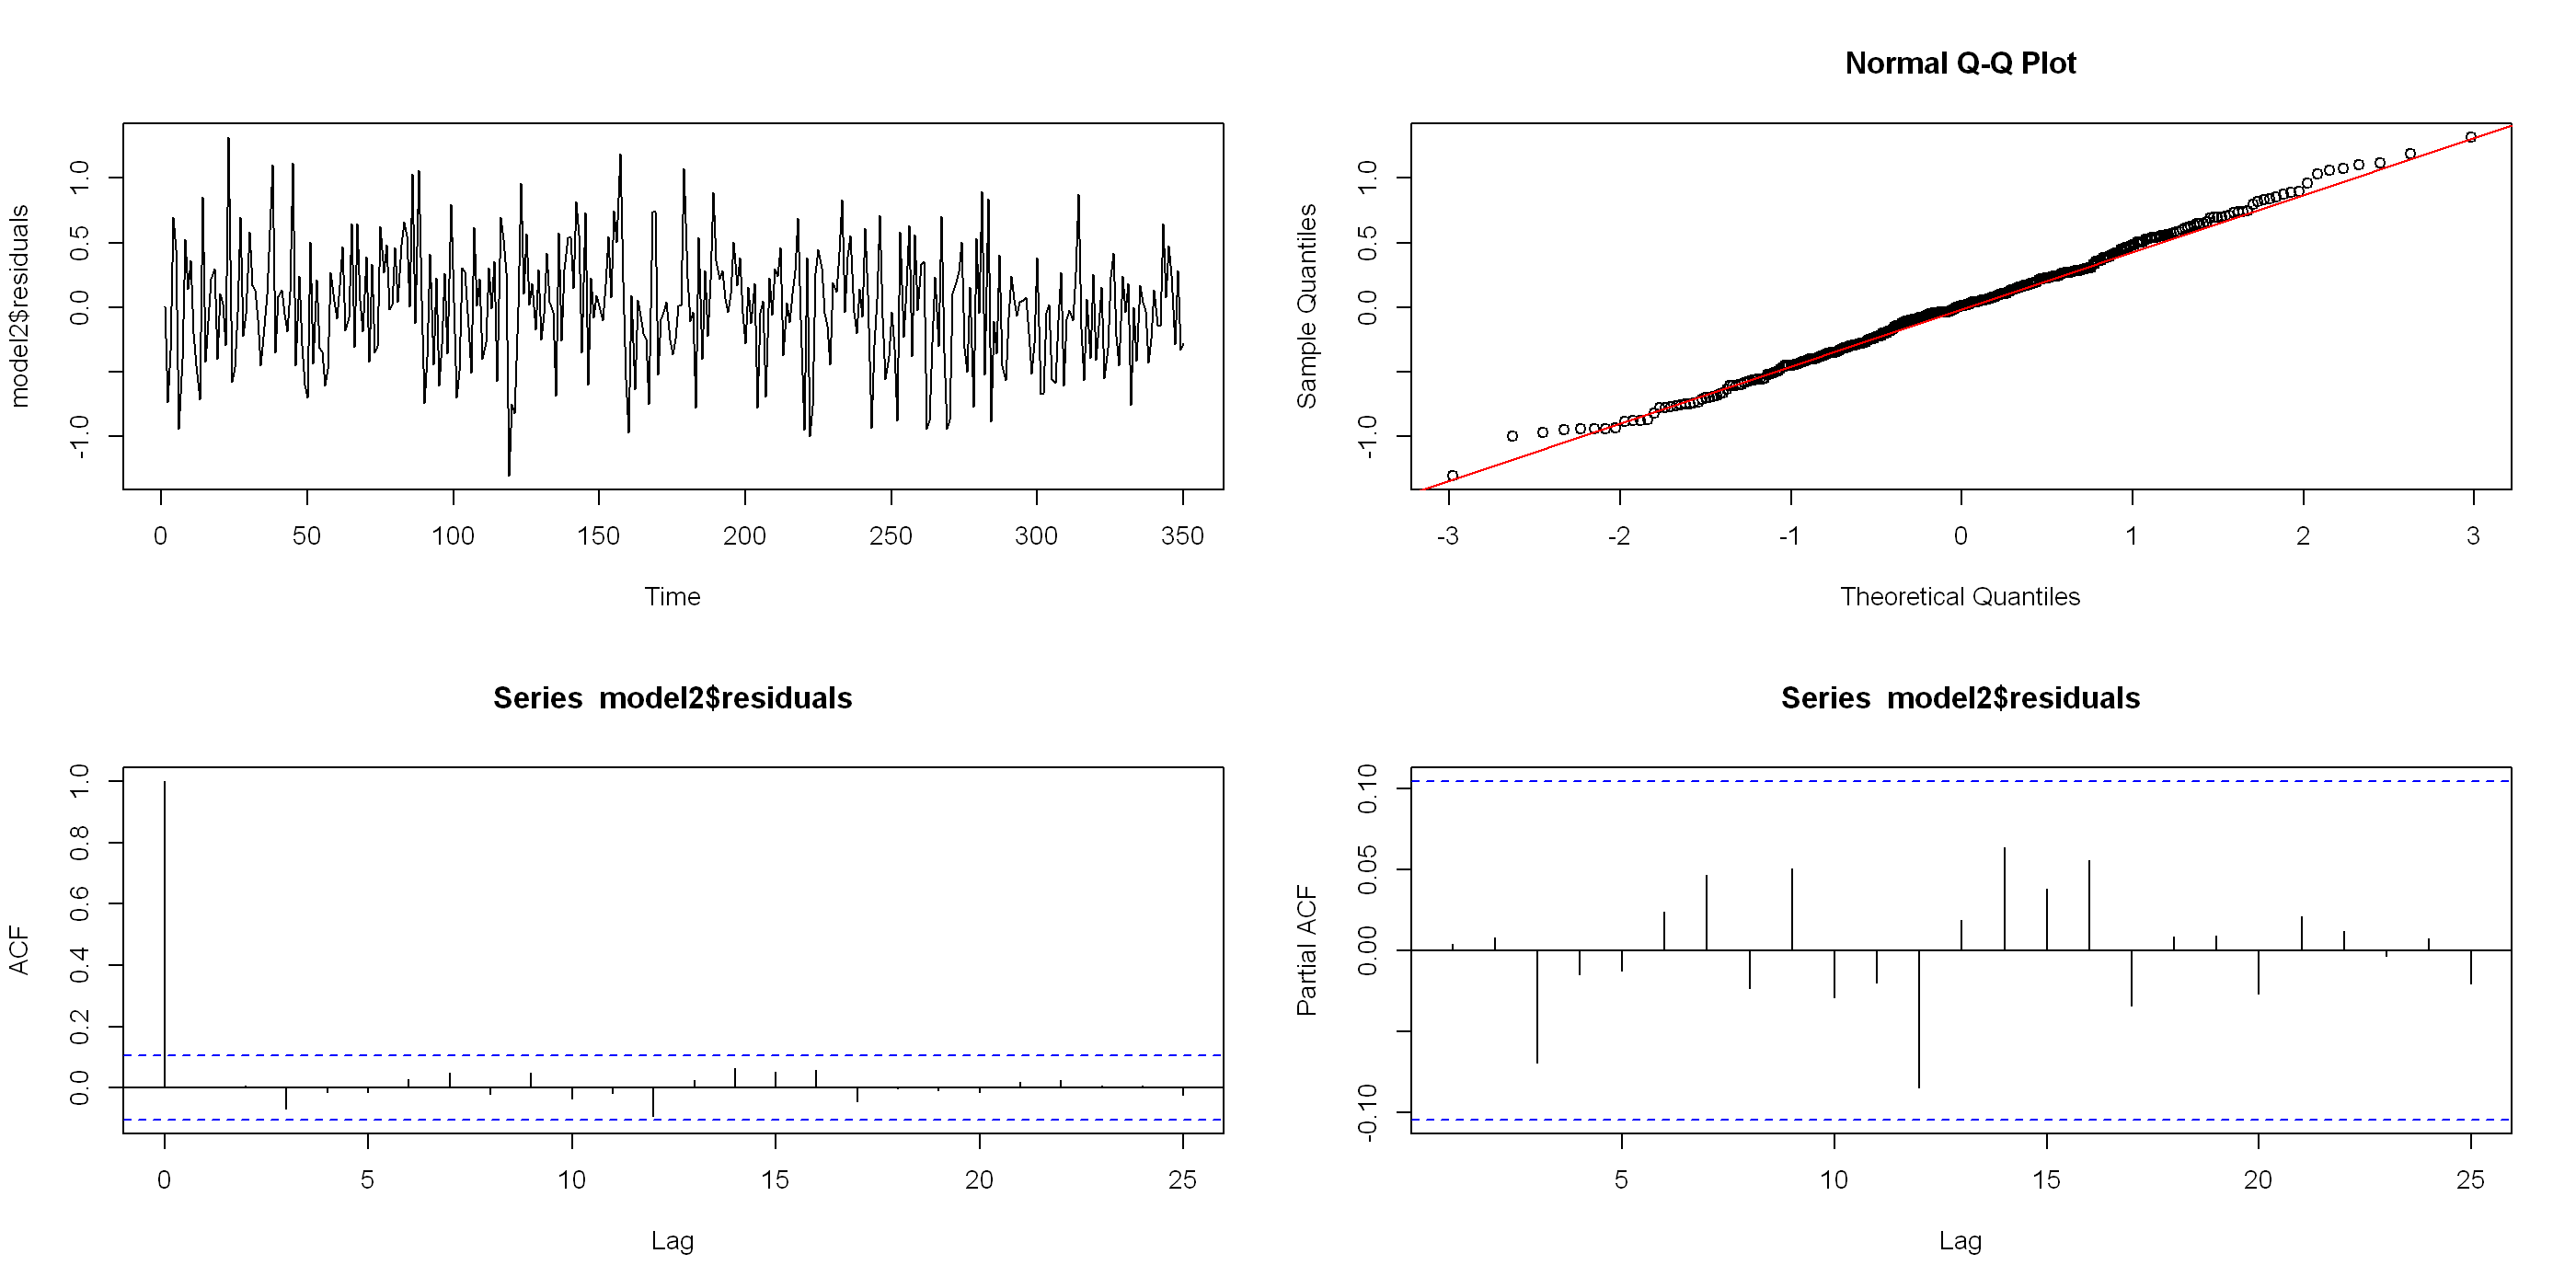

In [19]:
model2 <- arima(d.varve_trs,order=c(3,1,3))
par(mfrow = c(2,2))
plot(model2$residuals)
qqnorm(model2$residuals)
qqline(y=model2$residuals,col="red")
acf(model2$residuals)
pacf(model2$residuals)


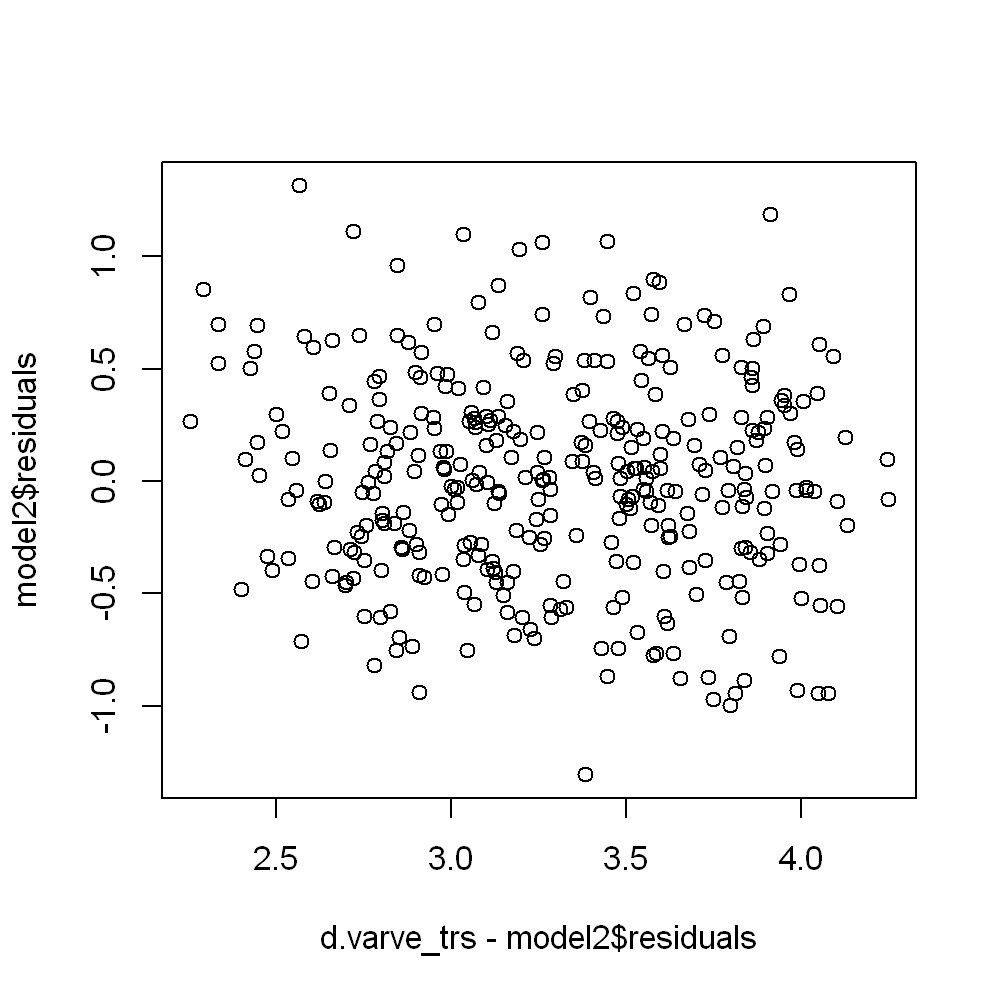

In [20]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

par(mfrow = c(1,1))
plot(d.varve_trs-model2$residuals,model2$residuals)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


The residuals look nice, no clear dependence structure "left out", no serial dependence, looks stationary and very close to being a perfect standard gaussian.

[1] 1 1
[1] 350   1


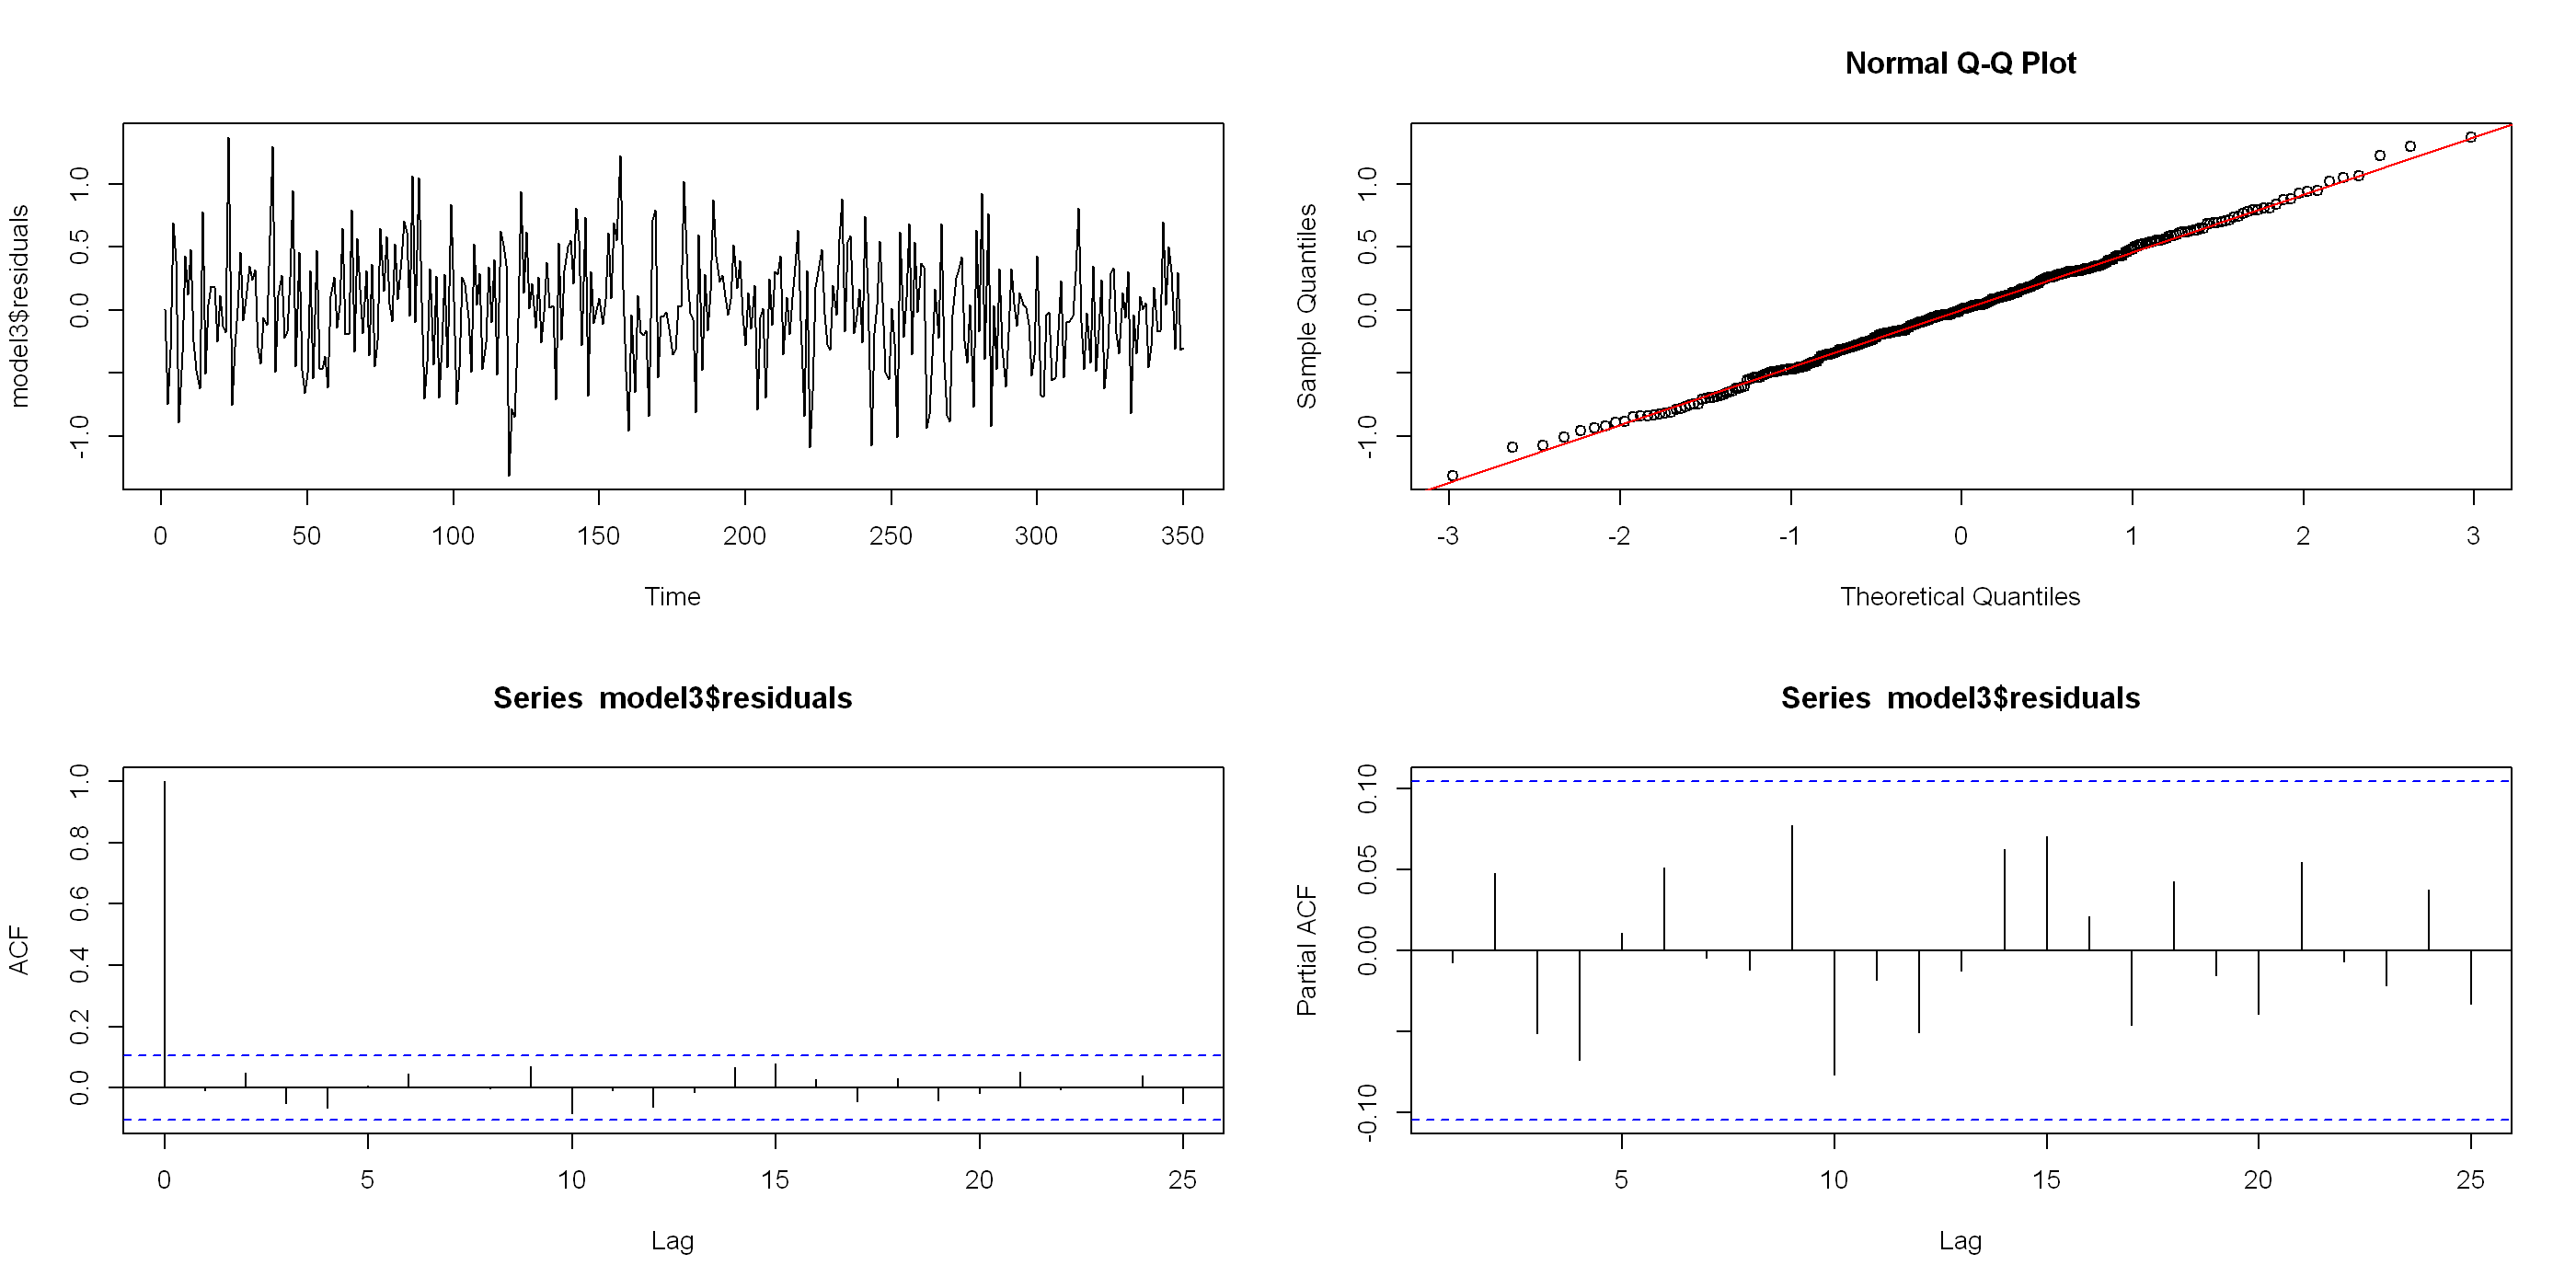

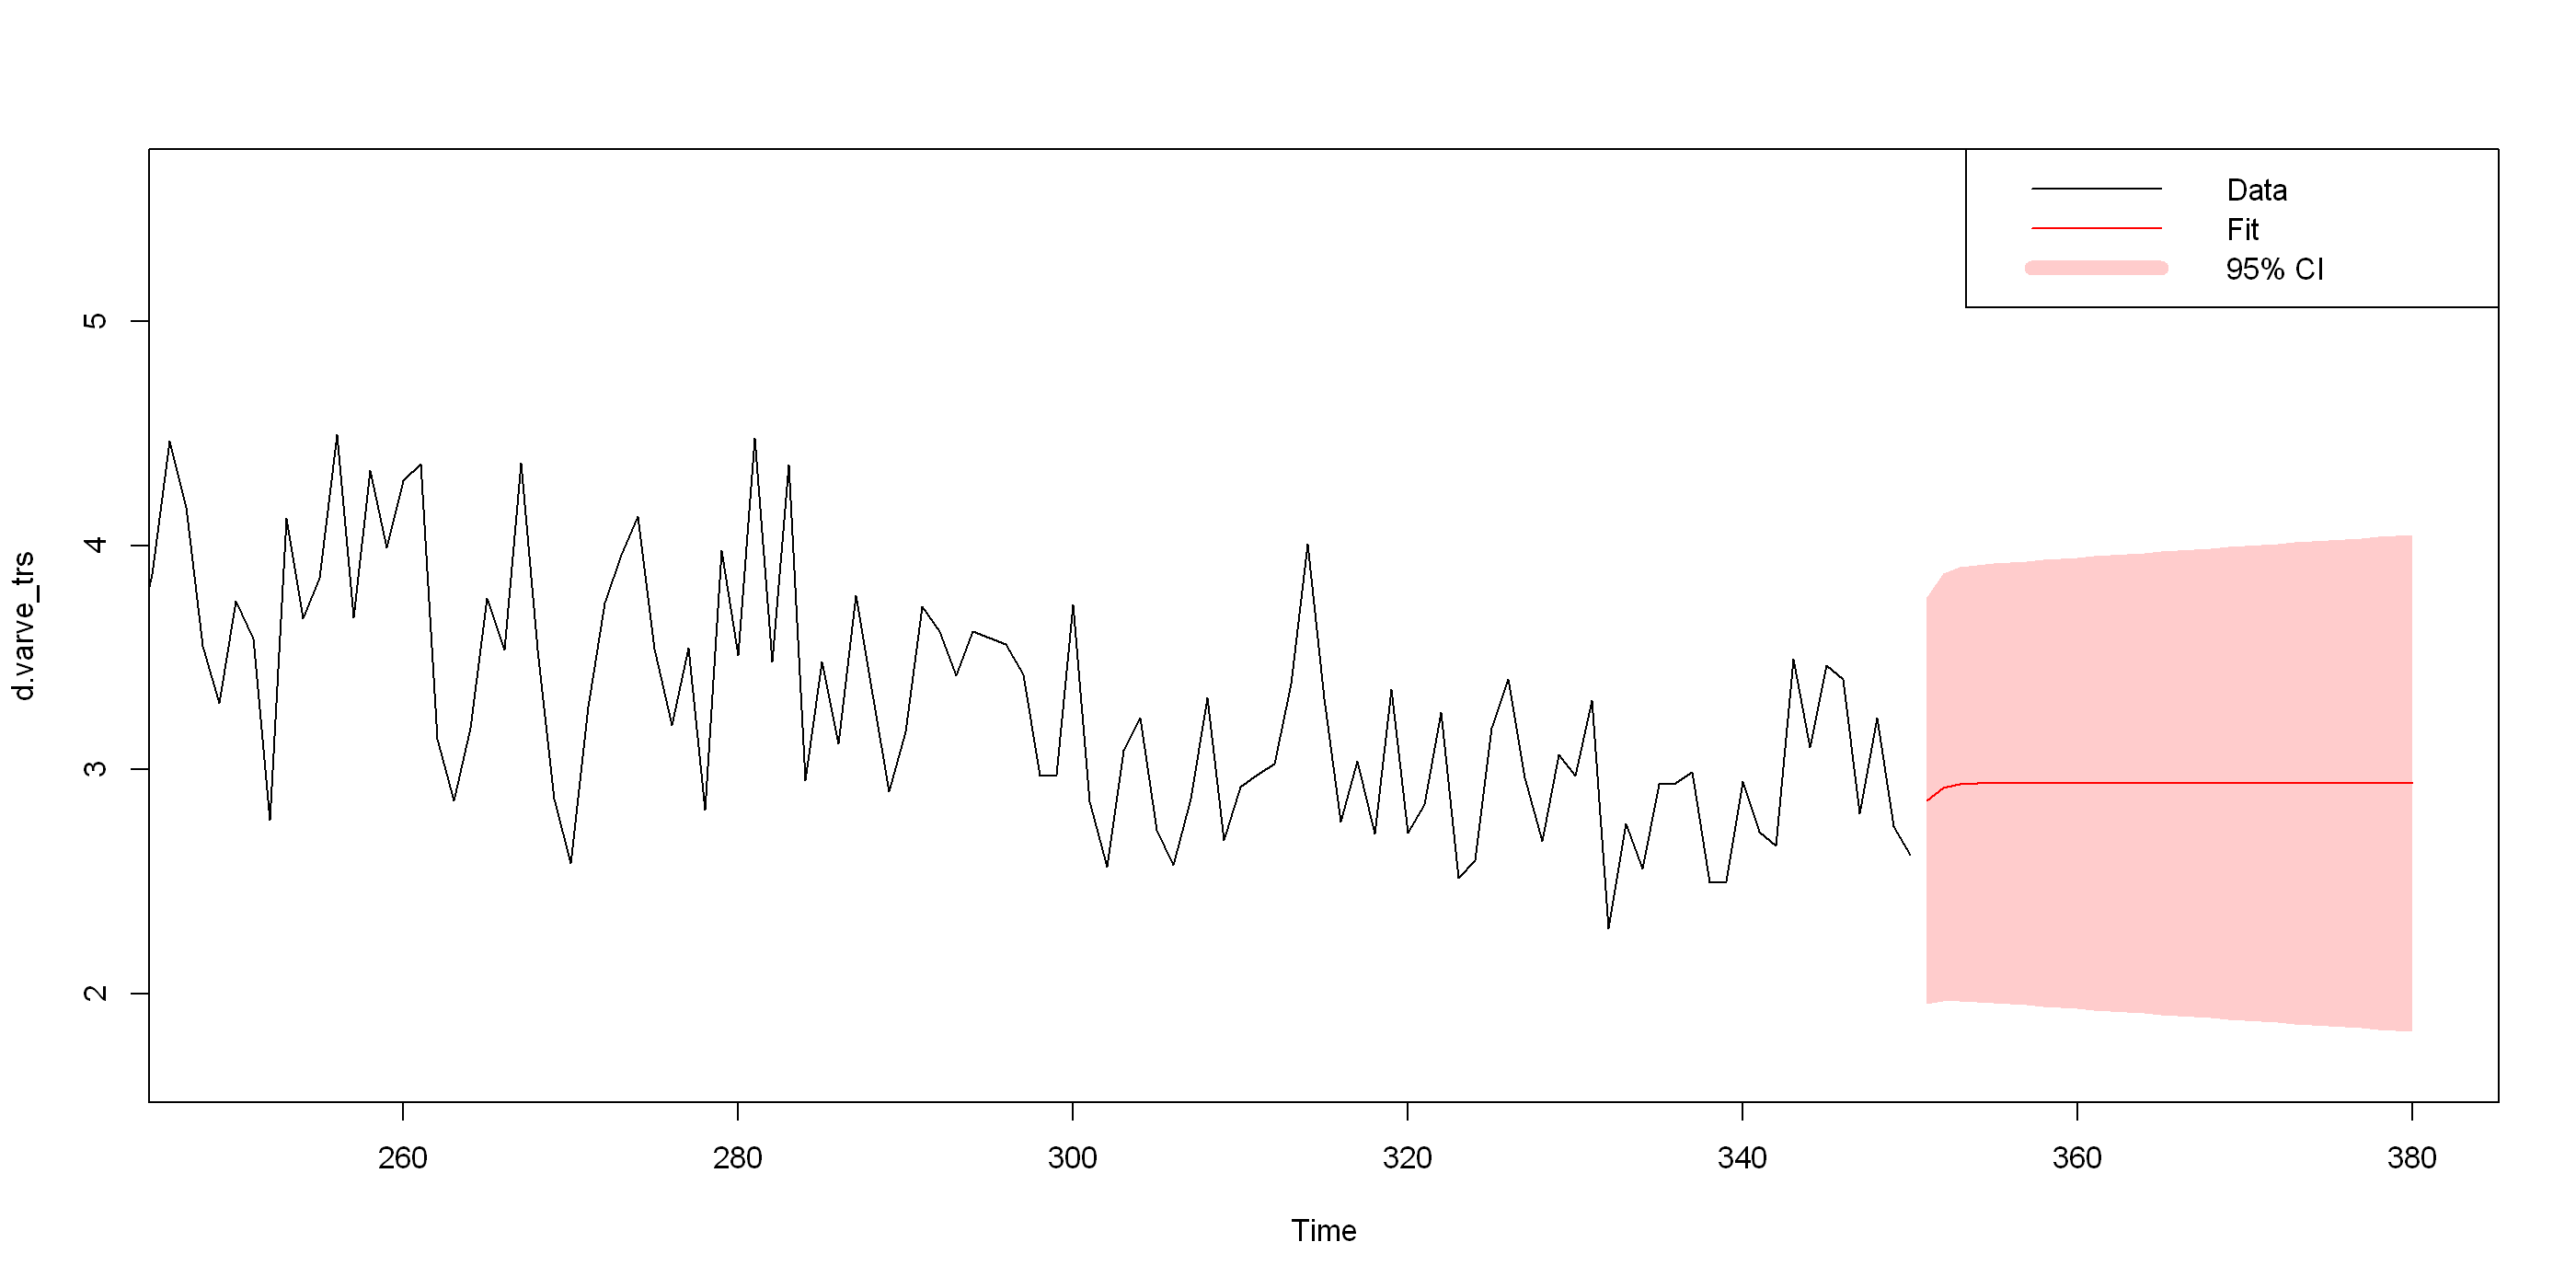

In [21]:
model3 <- arima(d.varve_trs,order = c(1,1,1))
op<-par(mfrow = c(2,2))
plot(model3$residuals)
qqnorm(model3$residuals)
qqline(y=model3$residuals,col="red")
acf(model3$residuals)
pacf(model3$residuals)
# pred2 <- predict(model2,n.ahead = 30)
print(start(d.varve_trs))
print(end(d.varve_trs))
n_hori <- 30
pred3 <- predict(model3,n.ahead = n_hori)

x_fit = seq(end(d.varve_trs)[1]+1,end(d.varve_trs)[1]+n_hori)

y_l95 <- pred3$pred-z95*pred3$se 
y_h95 <- pred3$pred+z95*pred3$se 

par(op)

plot(d.varve_trs,ylim=c(min(d.varve_trs)*0.9,max(d.varve_trs)*1.1),xlim=c(end(d.varve_trs)[1]-100,end(d.varve_trs)[1]+n_hori))
# lines(pred2$pred,col="blue")
lines(pred3$pred,col="red")
polygon(x = c(x_fit,rev(x_fit)),y = c(y_l95,rev(y_h95)),col=adjustcolor(col = "red",alpha.f = 0.2),border = FALSE)
legend("topright",legend = c("Data","Fit","95% CI"),lwd = c(1,1,8),col=c("black","red",adjustcolor(col="red",alpha.f = 0.2)))

Comments:
* The prediction looks as it rather poor, but hard to say, the CI's might be ok, there is nothing to test against, regardless clearly after a few steps away from the formulated lag the prediction converges to a constant.
* The CI's slowly get wider and wider which is expected, we're using a ARIMA model, if it was an AR model they the CI's would converge to a constant, same goes for a MA model, combined that is not the behaviour.

[1] 2 1
[1] 350   1


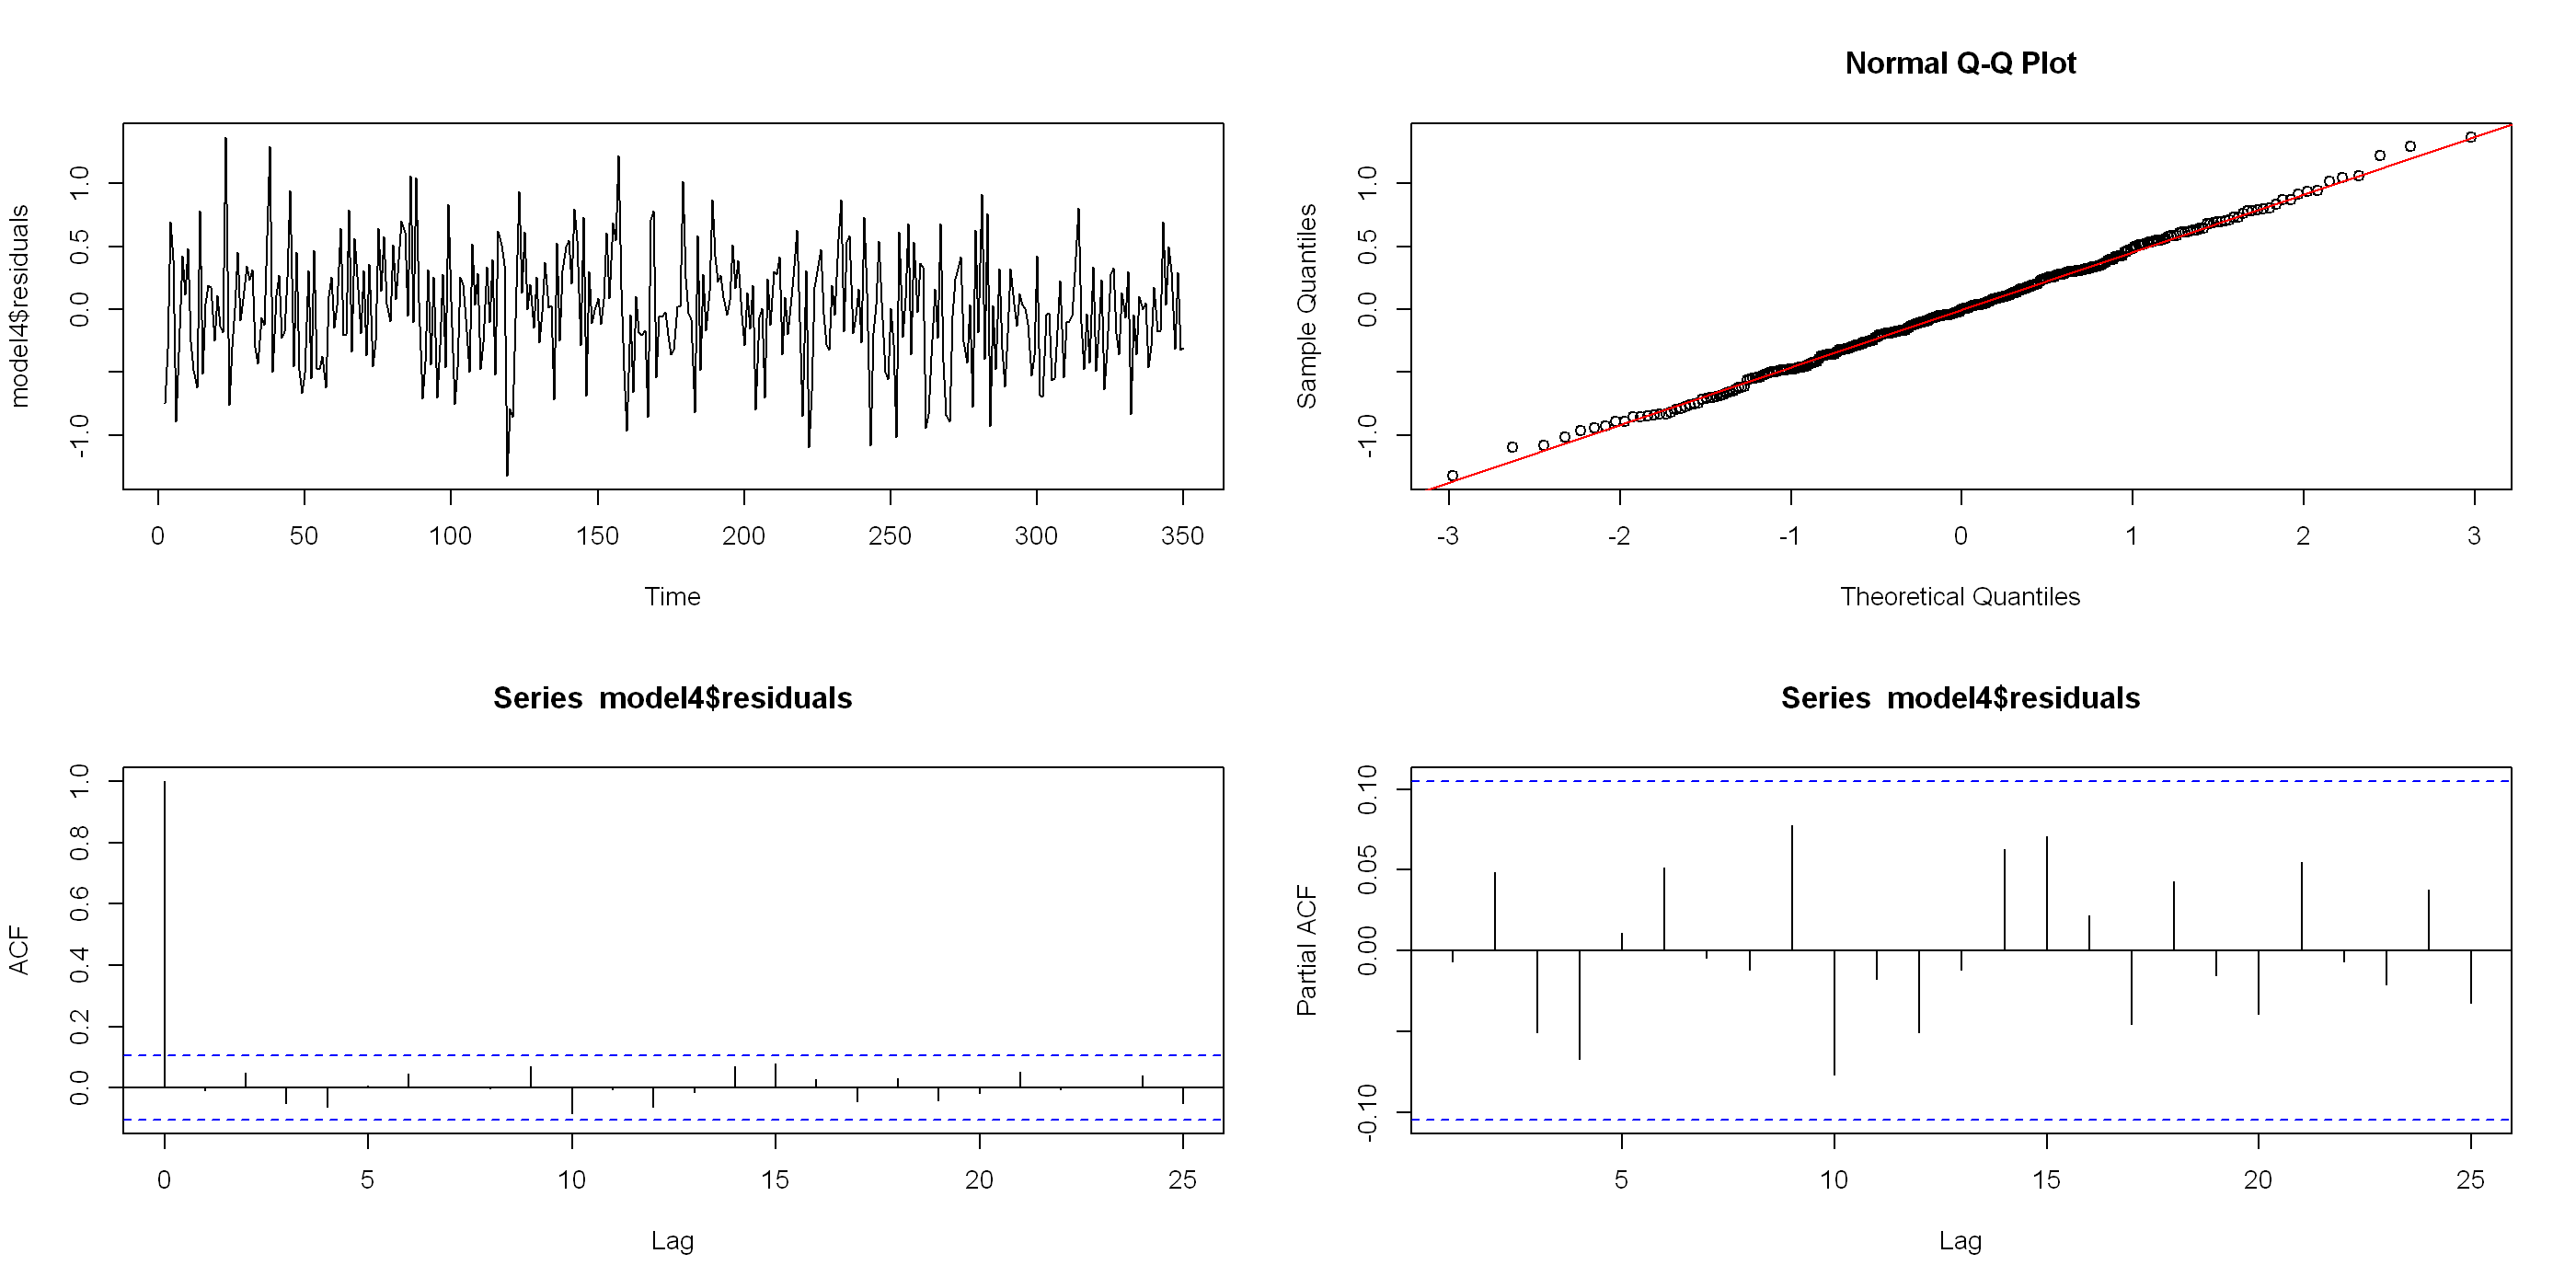

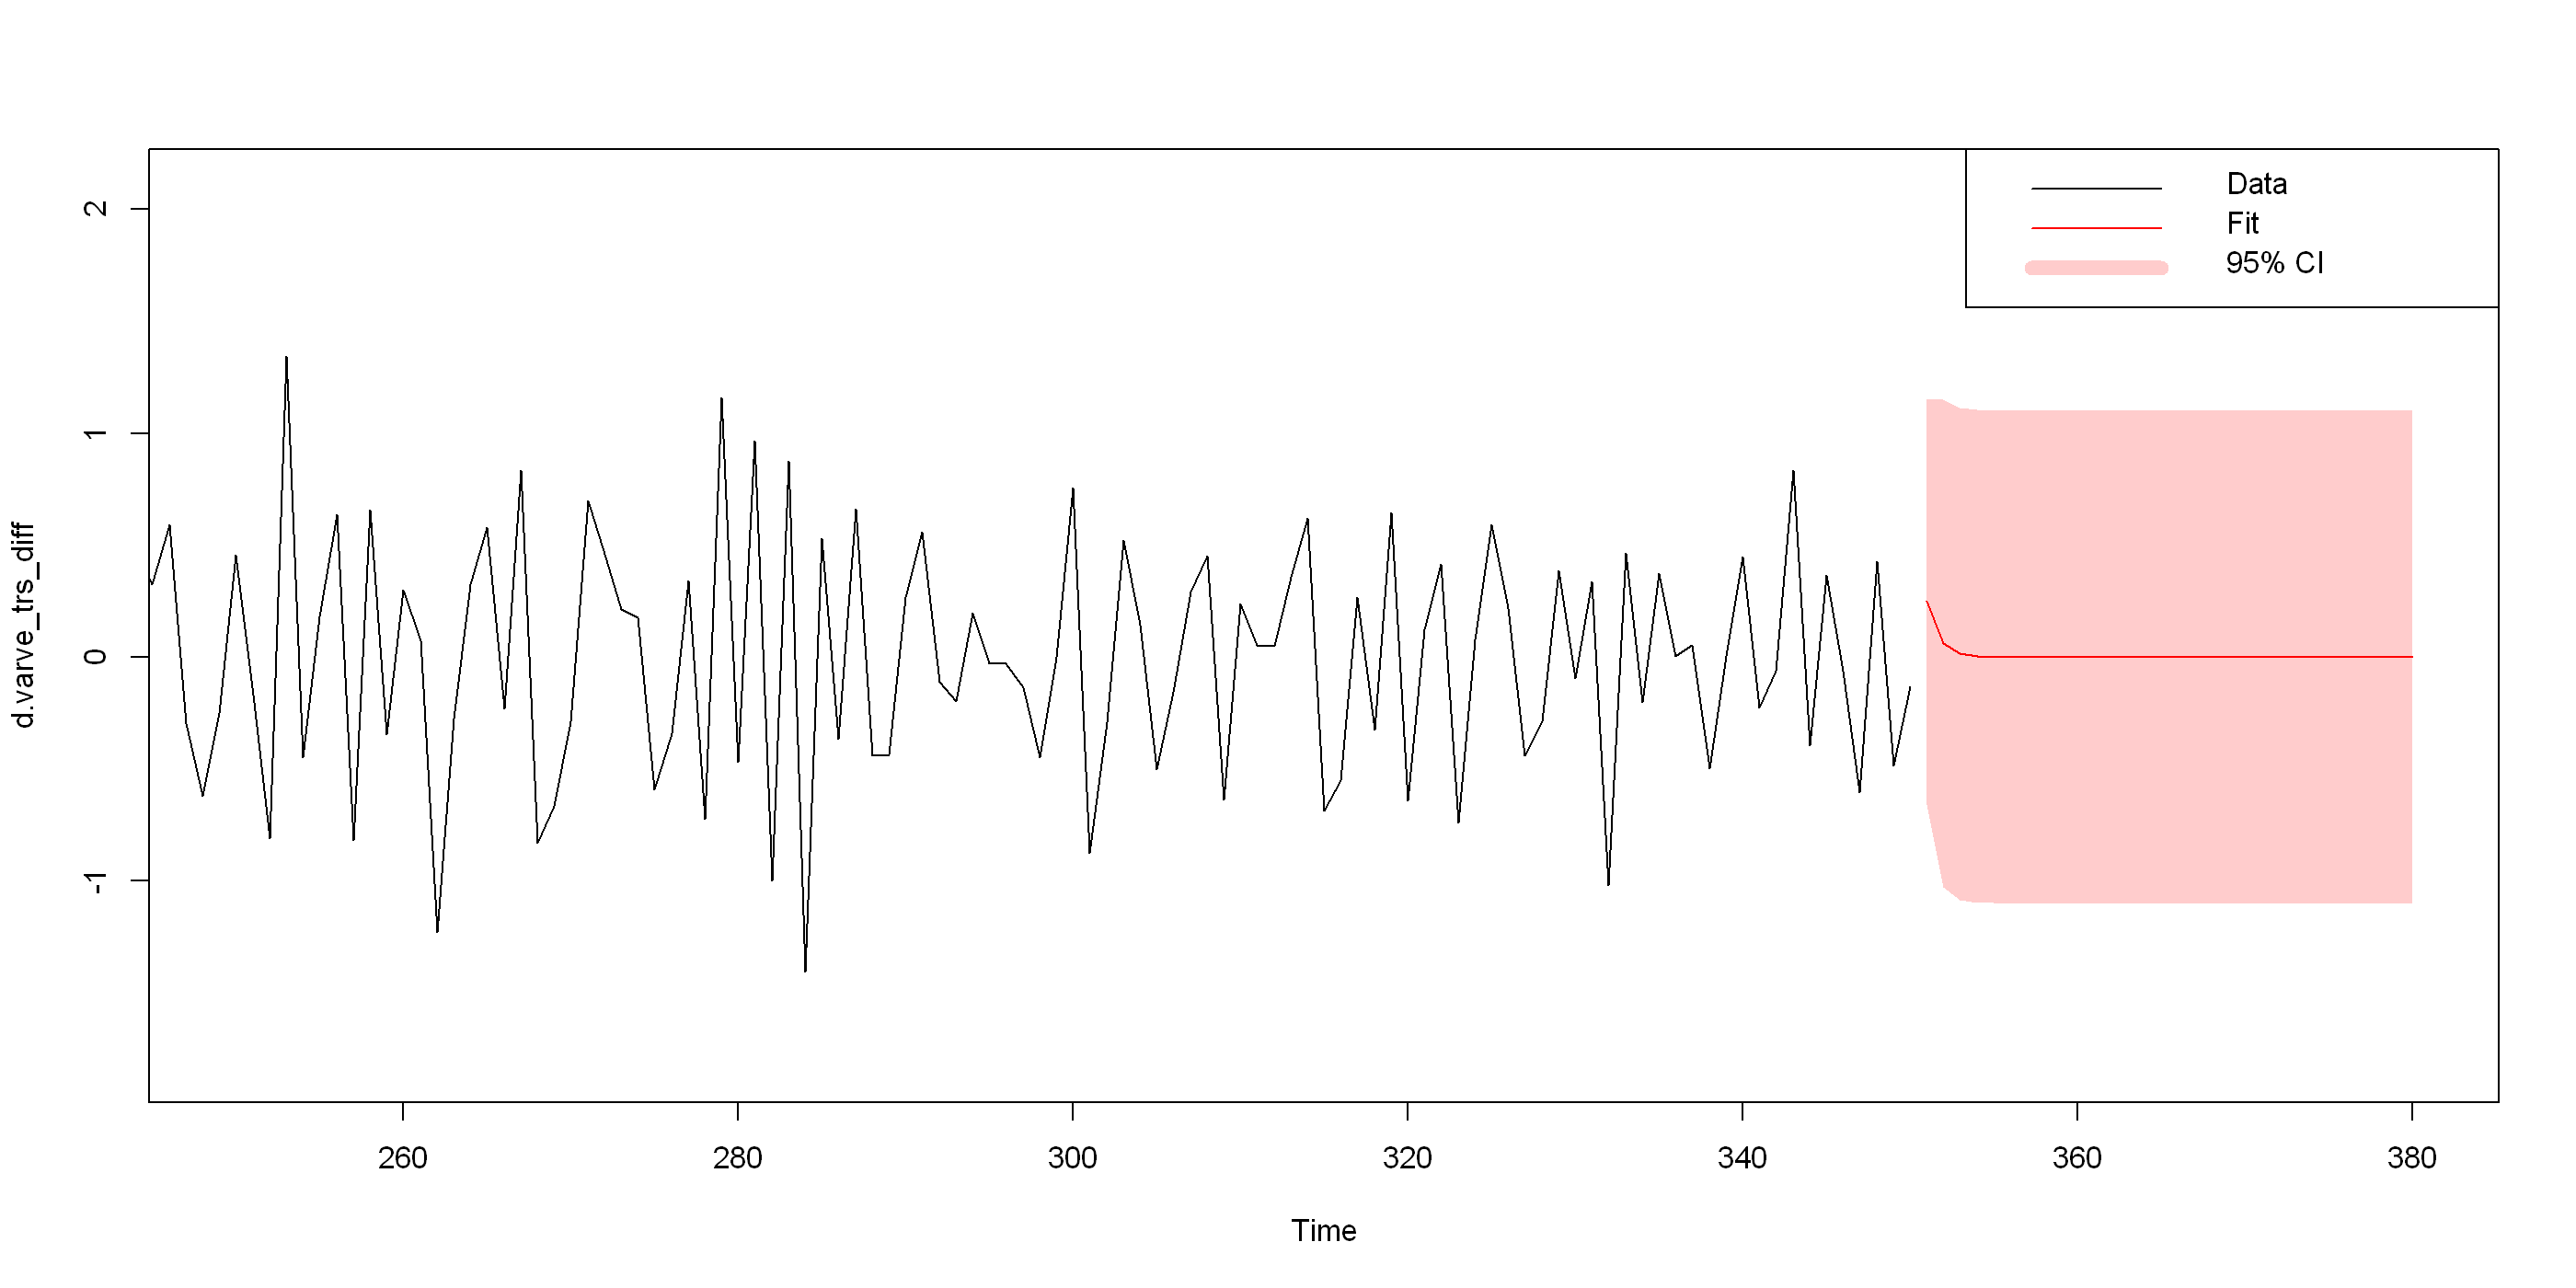

In [22]:
model4 <- arima(d.varve_trs_diff,order = c(1,0,1))
op<-par(mfrow = c(2,2))
plot(model4$residuals)
qqnorm(model4$residuals)
qqline(y=model4$residuals,col="red")
acf(model4$residuals)
pacf(model4$residuals)
# pred2 <- predict(model2,n.ahead = 30)
print(start(d.varve_trs_diff))
print(end(d.varve_trs_diff))
n_hori <- 30
pred4 <- predict(model4,n.ahead = n_hori)

x_fit = seq(end(d.varve_trs_diff)[1]+1,end(d.varve_trs_diff)[1]+n_hori)

y_l95 <- pred4$pred-z95*pred4$se 
y_h95 <- pred4$pred+z95*pred4$se 

par(op)

plot(d.varve_trs_diff,xlim=c(end(d.varve_trs_diff)[1]-100,end(d.varve_trs_diff)[1]+n_hori),ylim=c(min(d.varve_trs_diff)*1.1,max(d.varve_trs_diff)*1.4))
# lines(pred2$pred,col="blue")
lines(pred4$pred,col="red")
polygon(x = c(x_fit,rev(x_fit)),y = c(y_l95,rev(y_h95)),col=adjustcolor(col = "red",alpha.f = 0.2),border = FALSE)
legend("topright",legend = c("Data","Fit","95% CI"),lwd = c(1,1,8),col=c("black","red",adjustcolor(col="red",alpha.f = 0.2)))

The fit and the CI's both converge to a constant, whereas before the CI's did not converge, it very slowly diverged. (The prediction's behaviour remains unchanged).

To invert from a log-transform, we simply take the exponent, and correct the point-forecast via bias adjusting $1+\frac{\sigma^2_E}{2}$, with the difference added, we further multiply by $k$-terms, with $k=1$ we multiply by $X_{t-1}$.

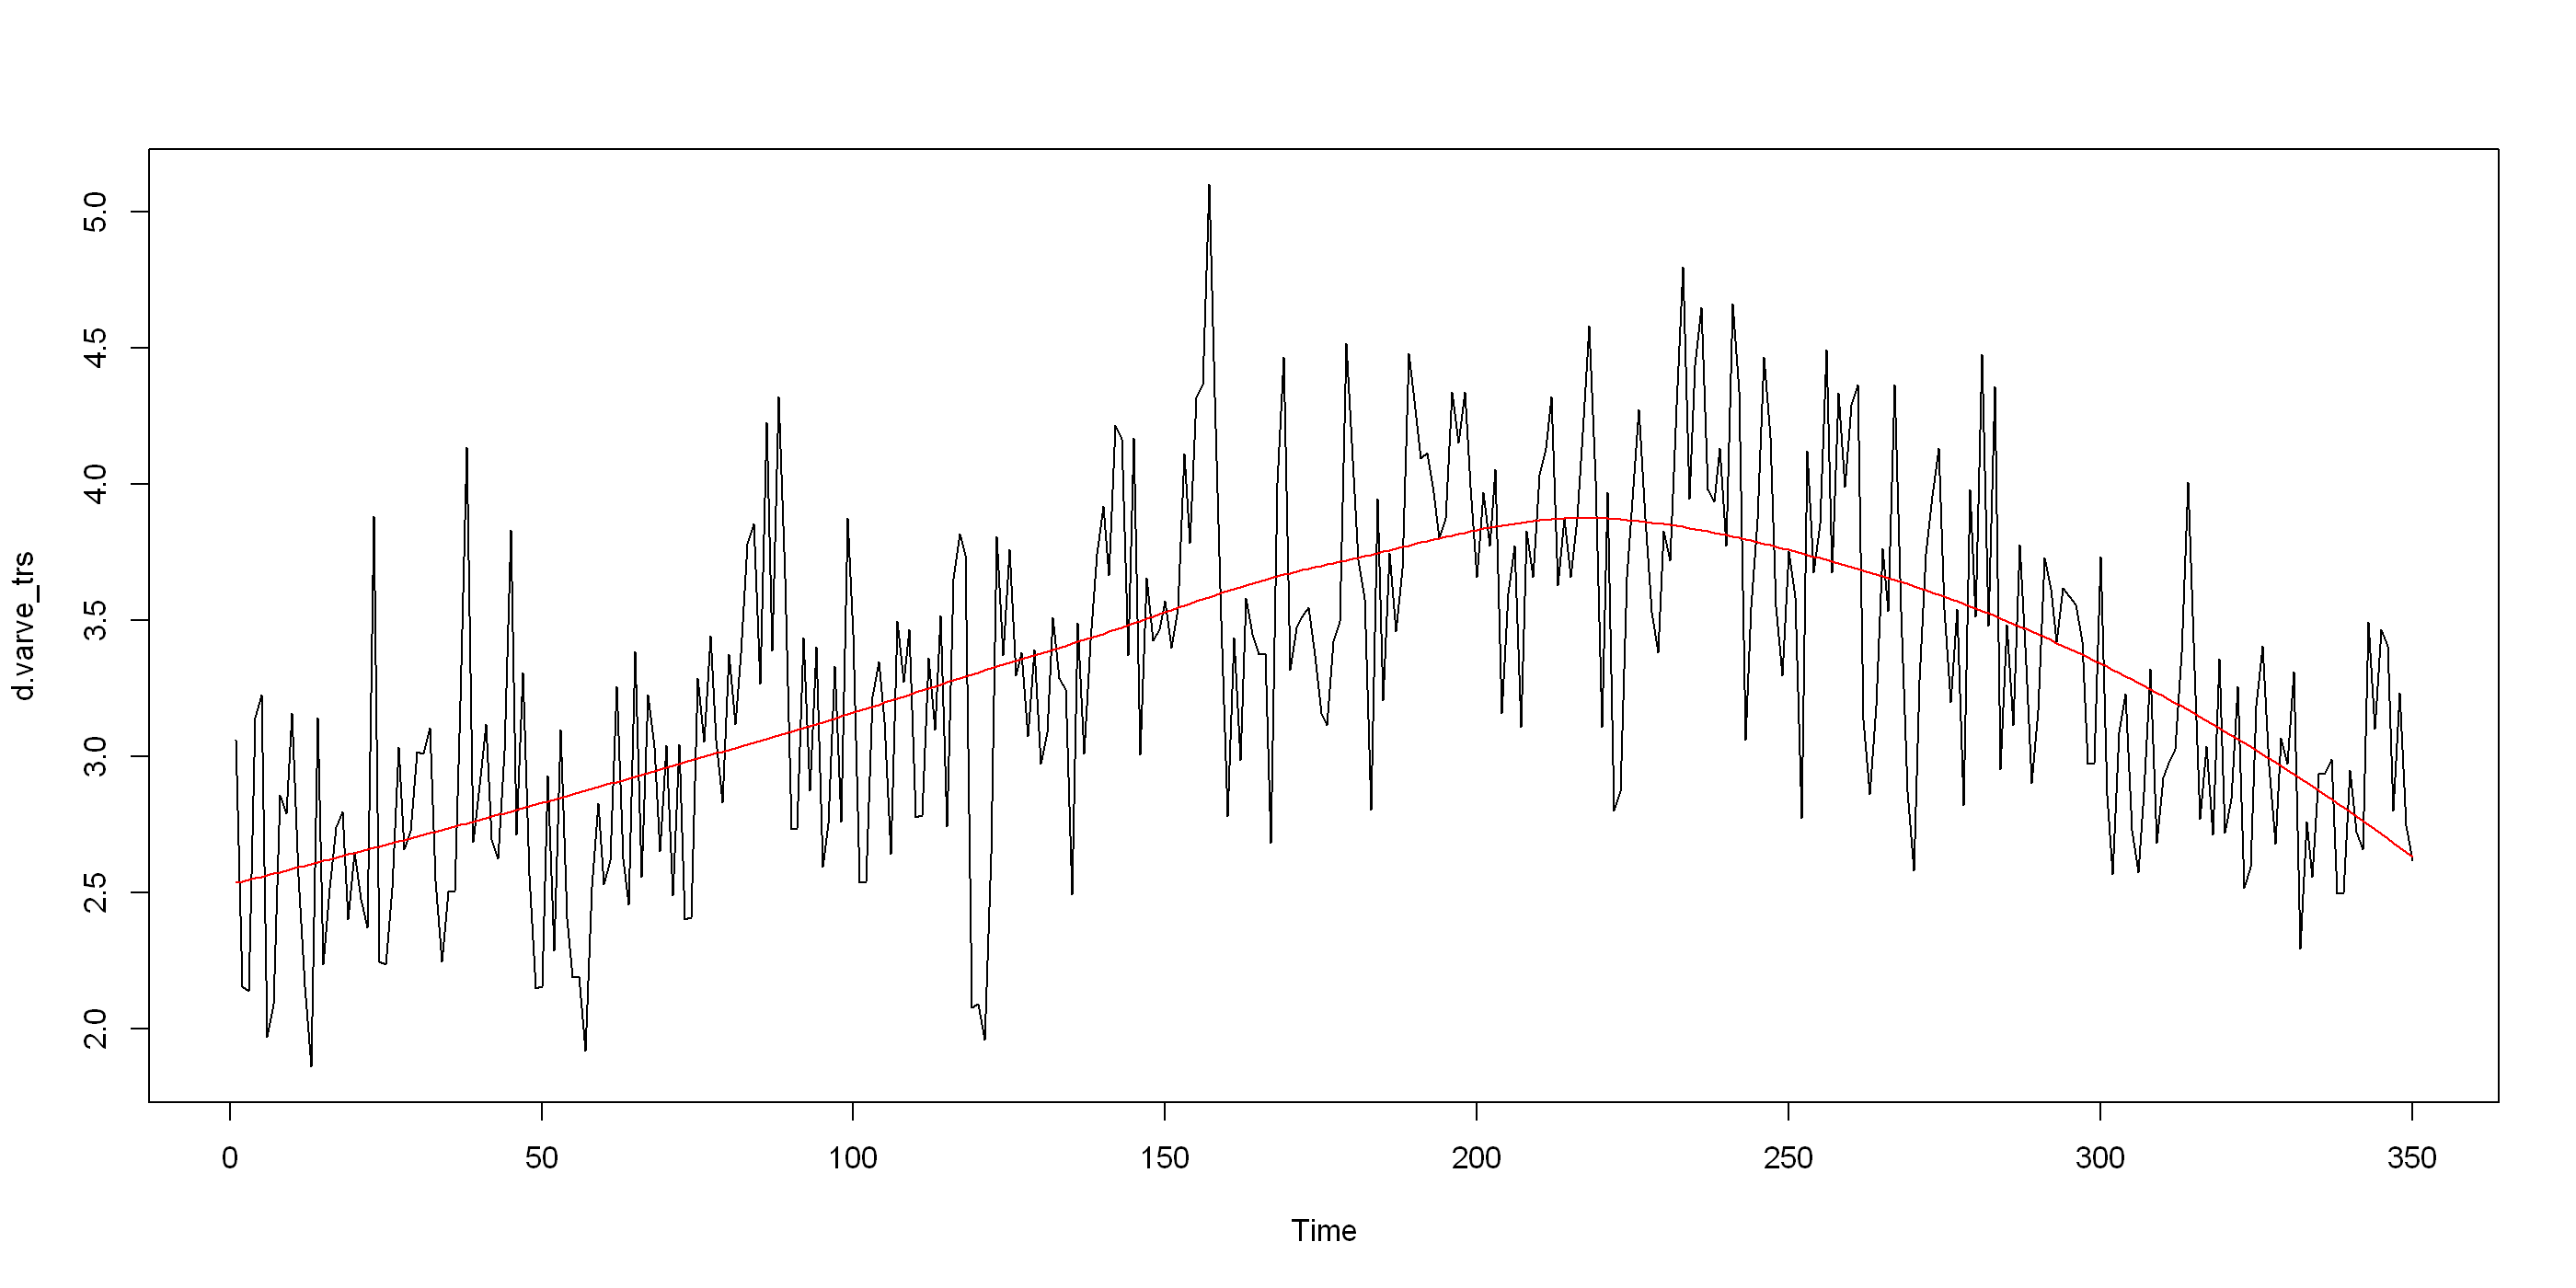

In [70]:
fit.loess <- loess(d.varve_trs ~ time(d.varve_trs))
pred.trend <- fitted(fit.loess)
ts.rem <- d.varve_trs-pred.trend
plot(d.varve_trs)
lines(pred.trend,col="red")

k <- 30
h <- 30
n <- length(pred.trend)
idx <- (n-k+1):n
xx <- as.numeric(time(d.varve_trs))[idx]
yy <- pred.trend[idx]
ts.trend_model <- lm(yy ~ xx)
ts.xh <- xx[k]+(1:h)

ts.t_pred <- predict(ts.trend_model,newdata = data.frame(xx = ts.xh))


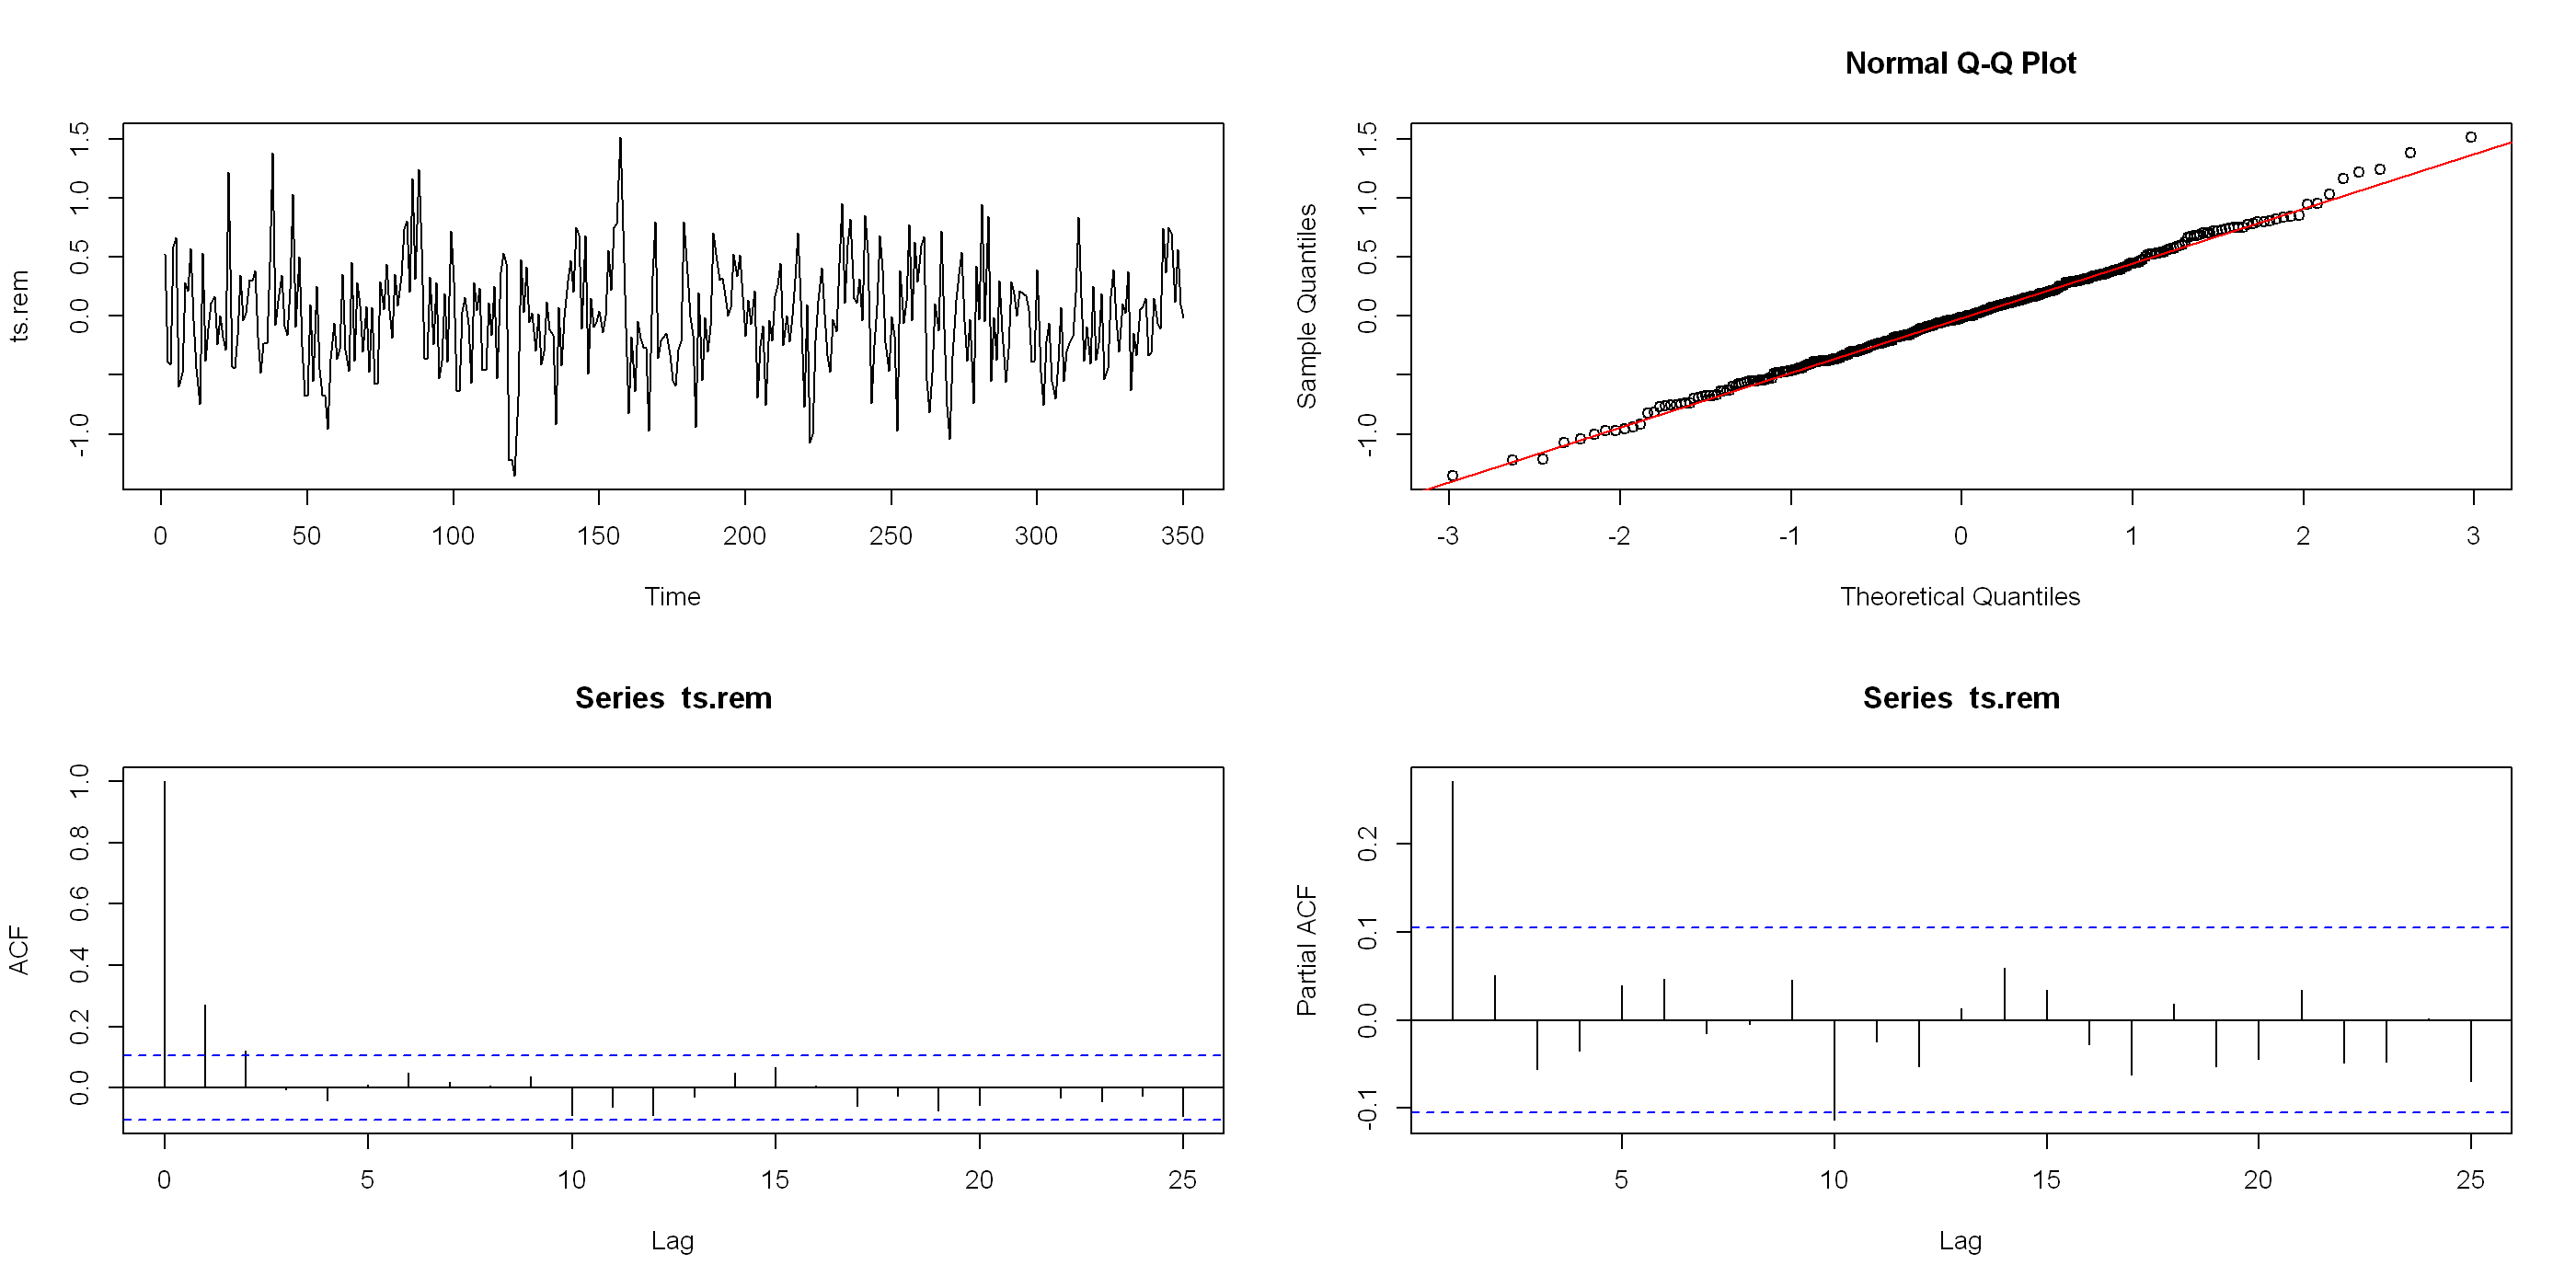

In [65]:
par(mfrow = c(2,2))
plot(ts.rem)
qqnorm(ts.rem)
qqline(y=ts.rem,col="red")
acf(ts.rem)
pacf(ts.rem)

We argue that an ARMA(1,1) or similar might suffice. The remainder appears to be stationary, and there is no sign of seasonal effect, as implied in the problem statement.

In [25]:
auto.arima(y = ts.rem,max.p = 9,max.q = 6,max.d = 3,trace = TRUE,ic = "aic",stepwise = FALSE, approximation = FALSE,max.order = 10)
# ts.model <- 


 ARIMA(0,0,0) with zero mean     : 459.5337
 ARIMA(0,0,0) with non-zero mean : 461.4707
 ARIMA(0,0,1) with zero mean     : 438.8365
 ARIMA(0,0,1) with non-zero mean : 440.7976
 ARIMA(0,0,2) with zero mean     : 434.7937
 ARIMA(0,0,2) with non-zero mean : 436.7647
 ARIMA(0,0,3) with zero mean     : 436.6509
 ARIMA(0,0,3) with non-zero mean : 438.6233
 ARIMA(0,0,4) with zero mean     : 437.5394
 ARIMA(0,0,4) with non-zero mean : 439.5084
 ARIMA(0,0,5) with zero mean     : 439.5336
 ARIMA(0,0,5) with non-zero mean : 441.502
 ARIMA(0,0,6) with zero mean     : 440.6622
 ARIMA(0,0,6) with non-zero mean : 442.6373
 ARIMA(1,0,0) with zero mean     : 434.6762
 ARIMA(1,0,0) with non-zero mean : 436.6463
 ARIMA(1,0,1) with zero mean     : 436.0786
 ARIMA(1,0,1) with non-zero mean : 438.0514
 ARIMA(1,0,2) with zero mean     : 436.7123
 ARIMA(1,0,2) with non-zero mean : 438.6841
 ARIMA(1,0,3) with zero mean     : 437.9638
 ARIMA(1,0,3) with non-zero mean : 439.9471
 ARIMA(1,0,4) with zero mean    

Series: ts.rem 
ARIMA(1,0,0) with zero mean 

Coefficients:
         ar1
      0.2719
s.e.  0.0514

sigma^2 = 0.2009:  log likelihood = -215.34
AIC=434.68   AICc=434.71   BIC=442.39

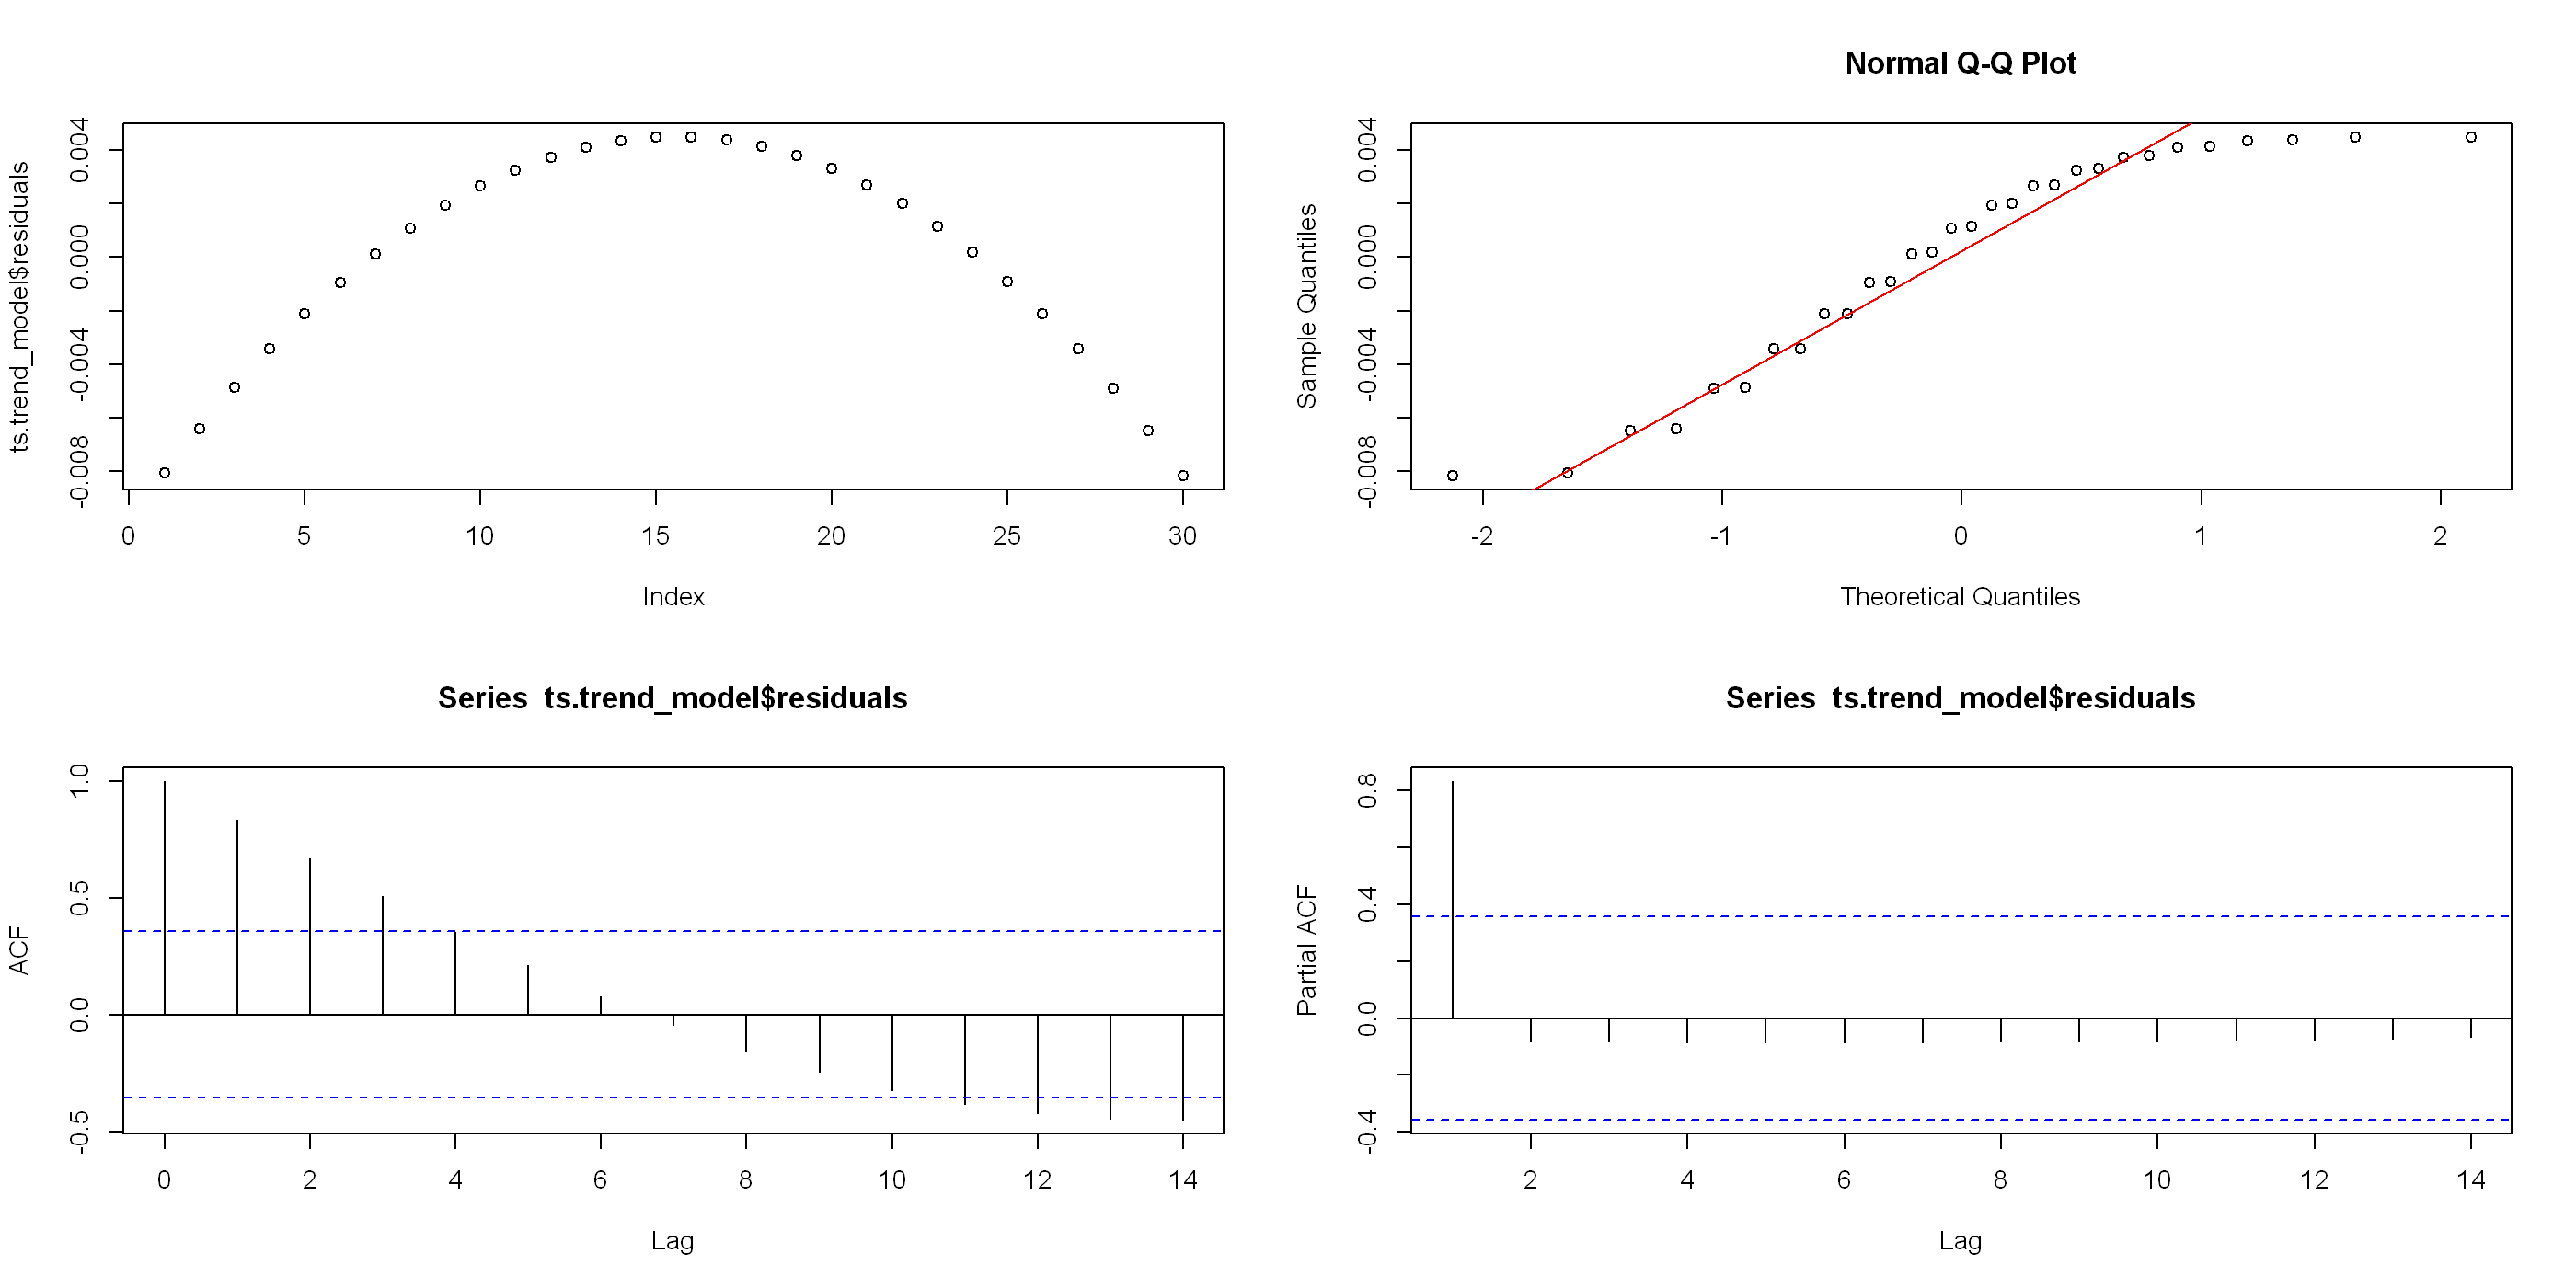

In [71]:
par(mfrow = c(2,2))
plot(ts.trend_model$residuals)
qqnorm(ts.trend_model$residuals)
qqline(y=ts.trend_model$residuals,col="red")
acf(ts.trend_model$residuals)
pacf(ts.trend_model$residuals)

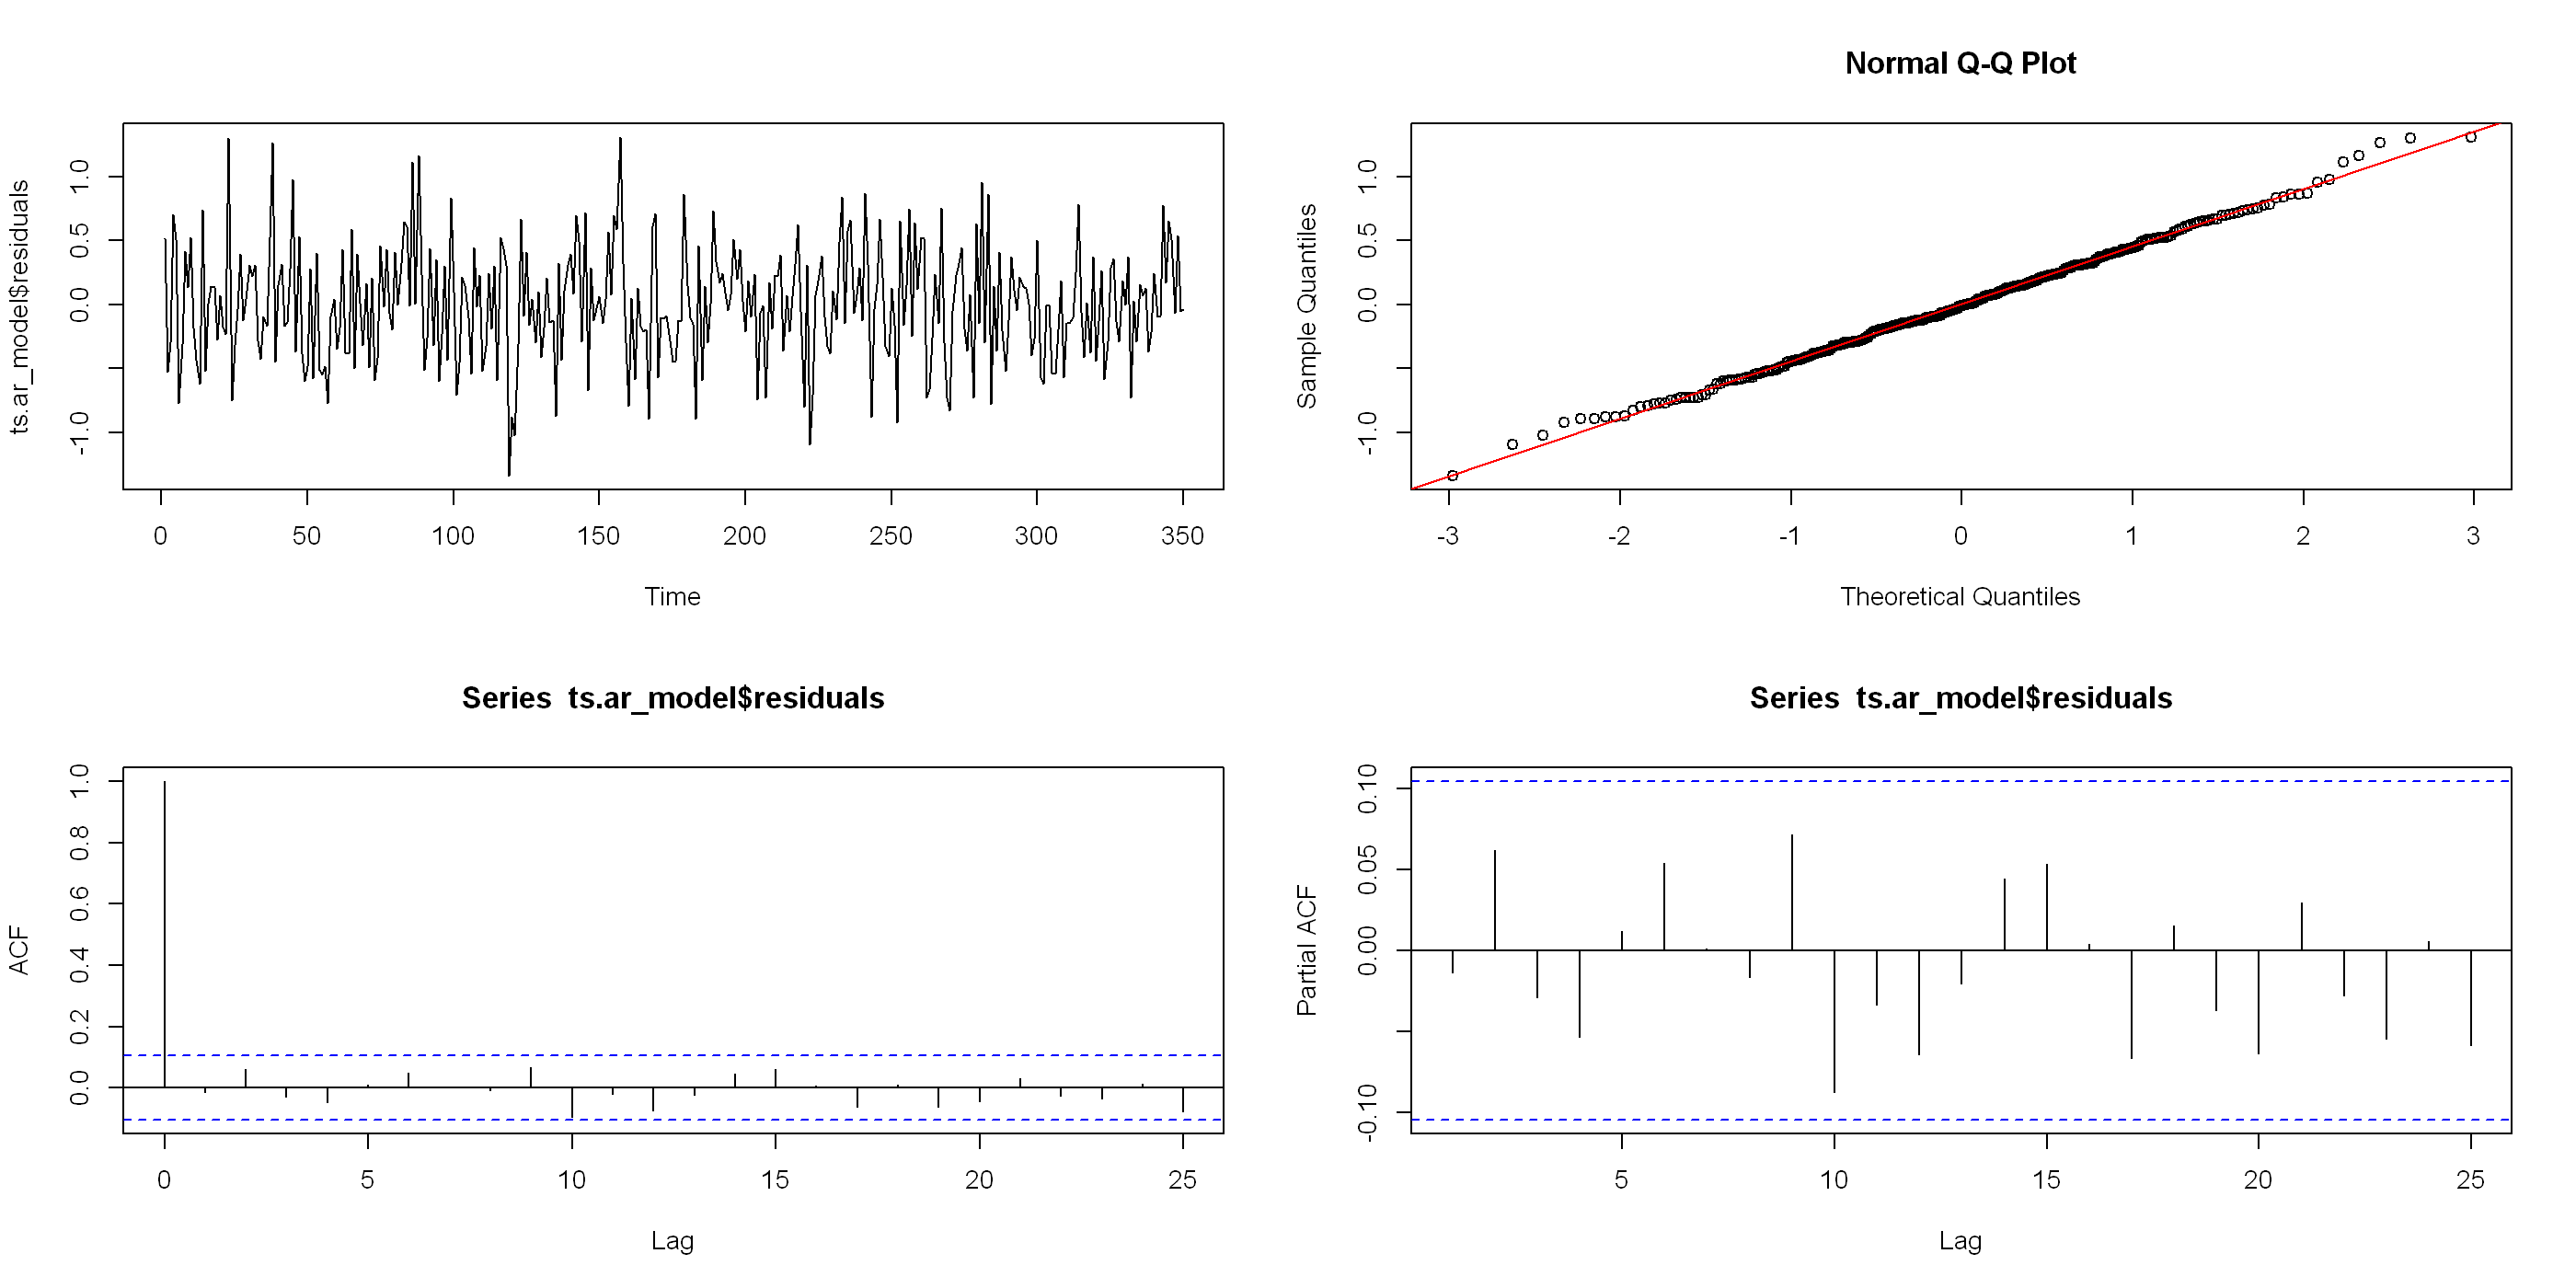

In [72]:
ts.ar_model <- arima(ts.rem,order = c(1,0,0)) 

par(mfrow = c(2,2))
plot(ts.ar_model$residuals)
qqnorm(ts.ar_model$residuals)
qqline(y=ts.ar_model$residuals,col="red")
acf(ts.ar_model$residuals)
pacf(ts.ar_model$residuals)




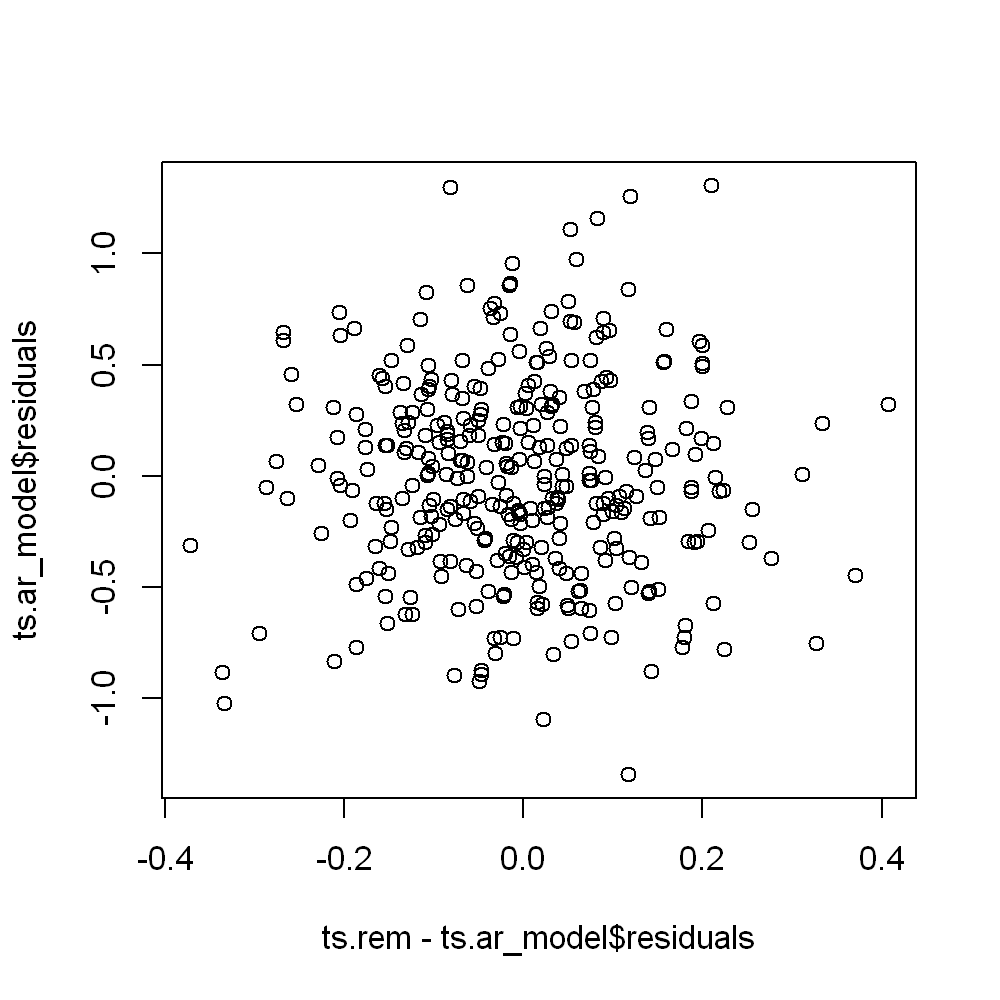

In [73]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

par(mfrow = c(1,1))
plot(ts.rem-ts.ar_model$residuals,ts.ar_model$residuals)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


The residuals look nice, stationary, almost normally distributed, no serial dependence and no clear structure "left out".

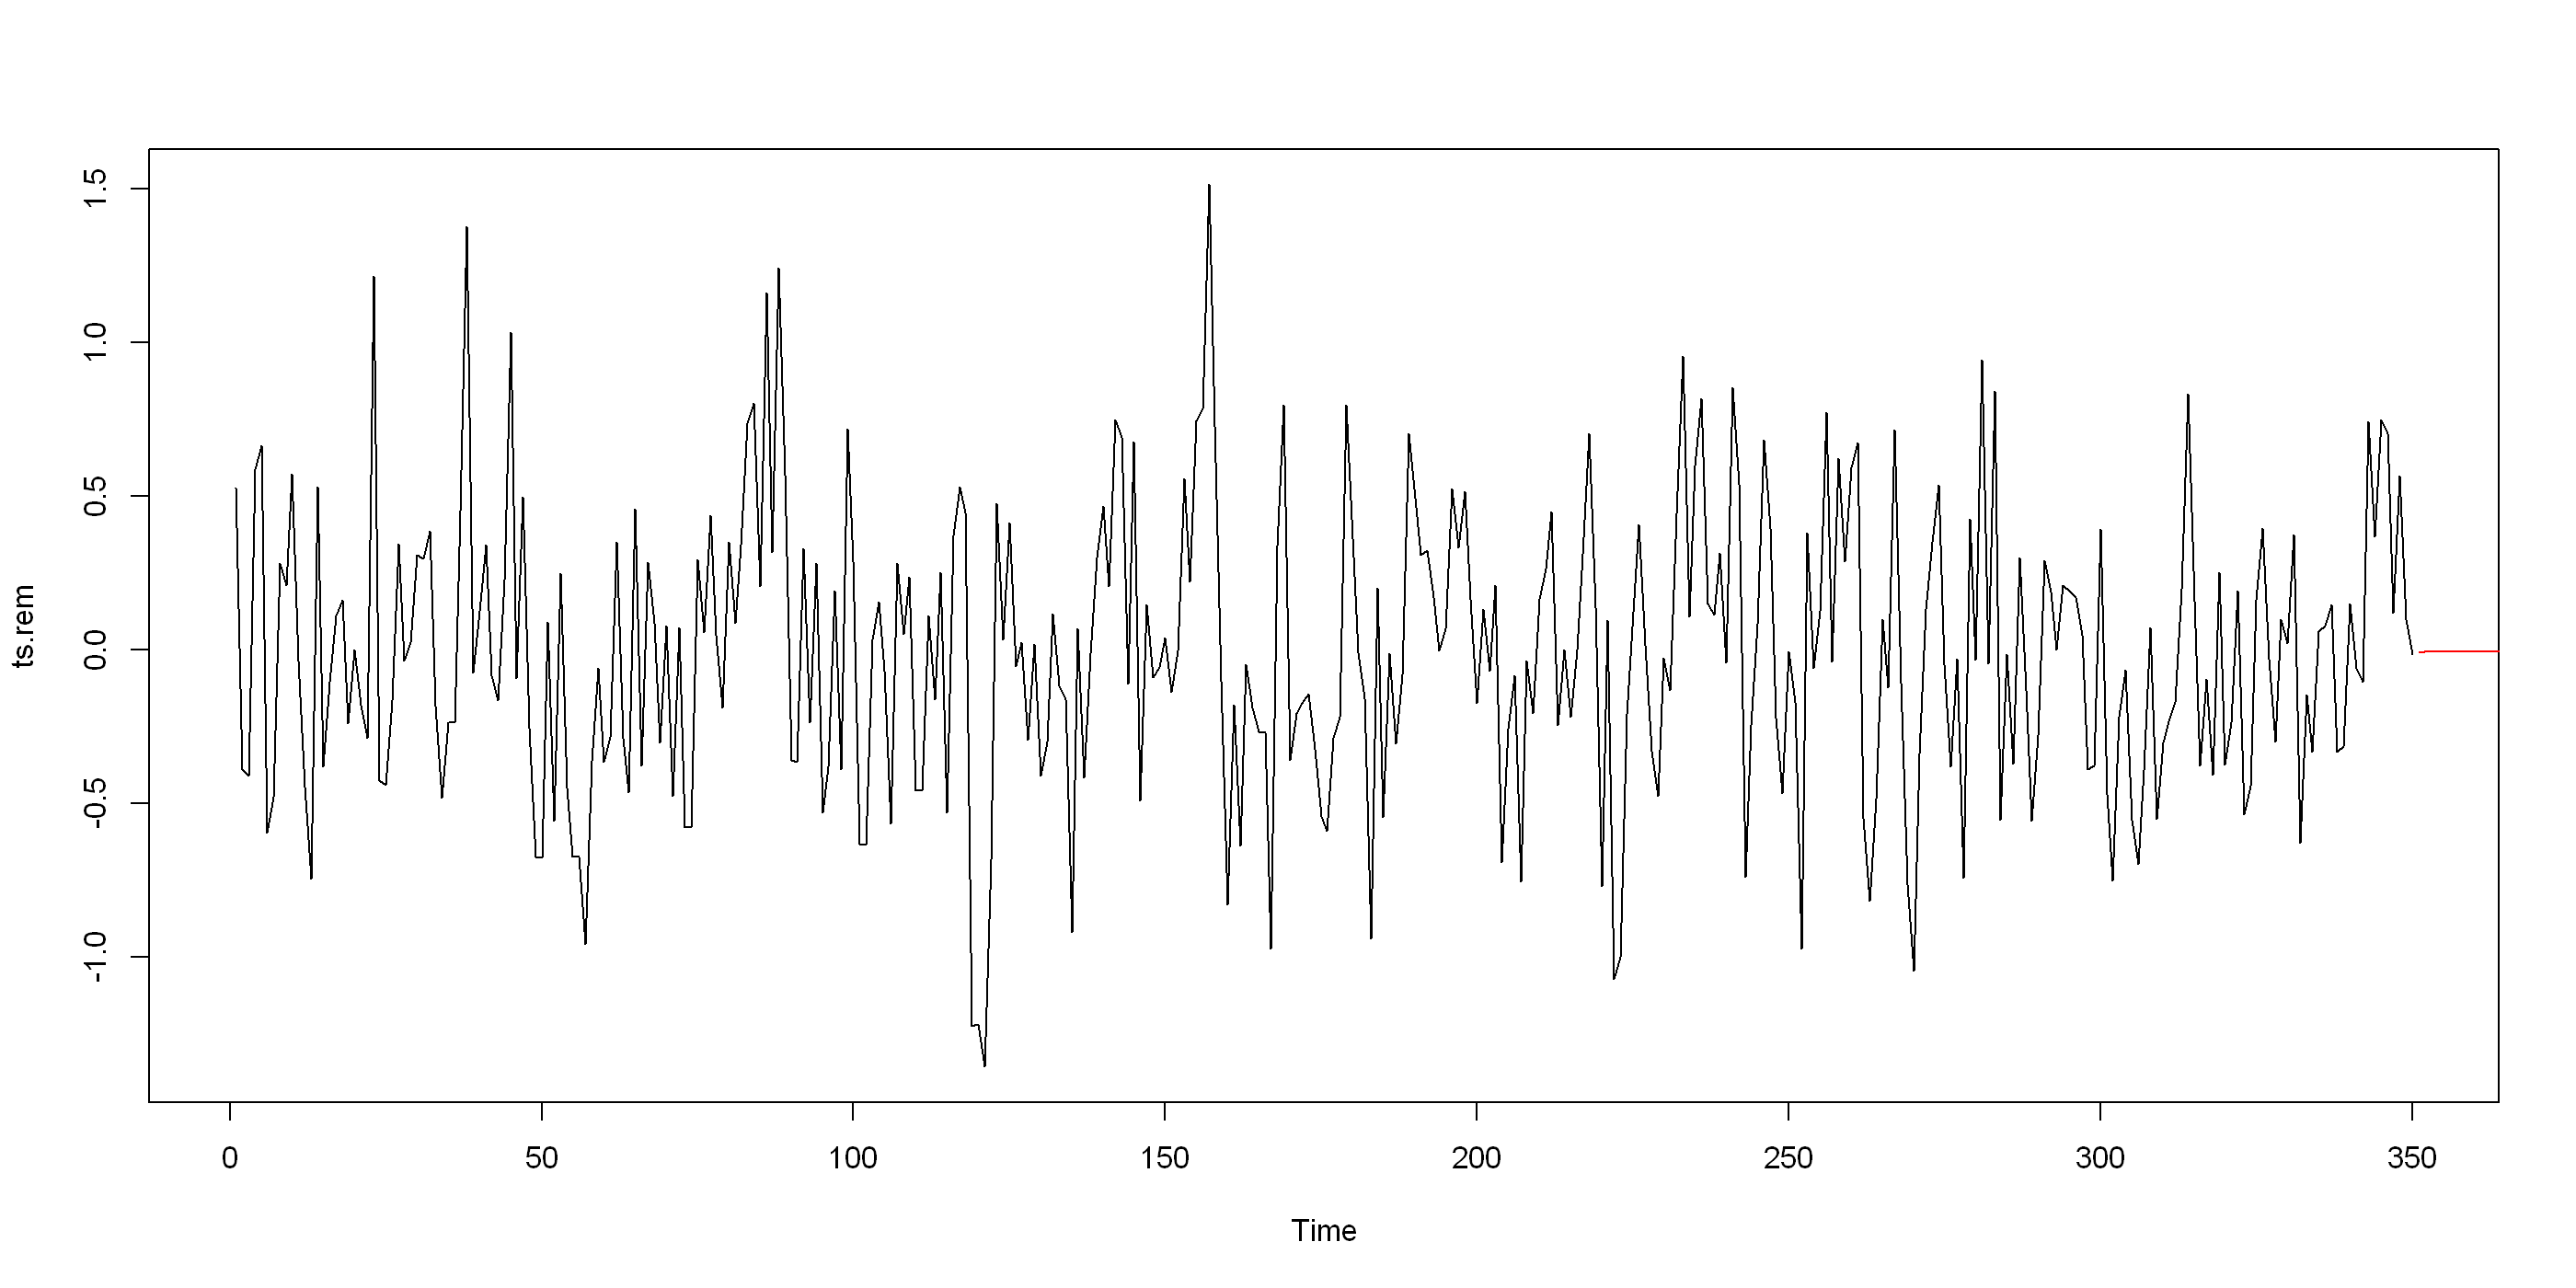

[1] 1 1
[1] 350   1


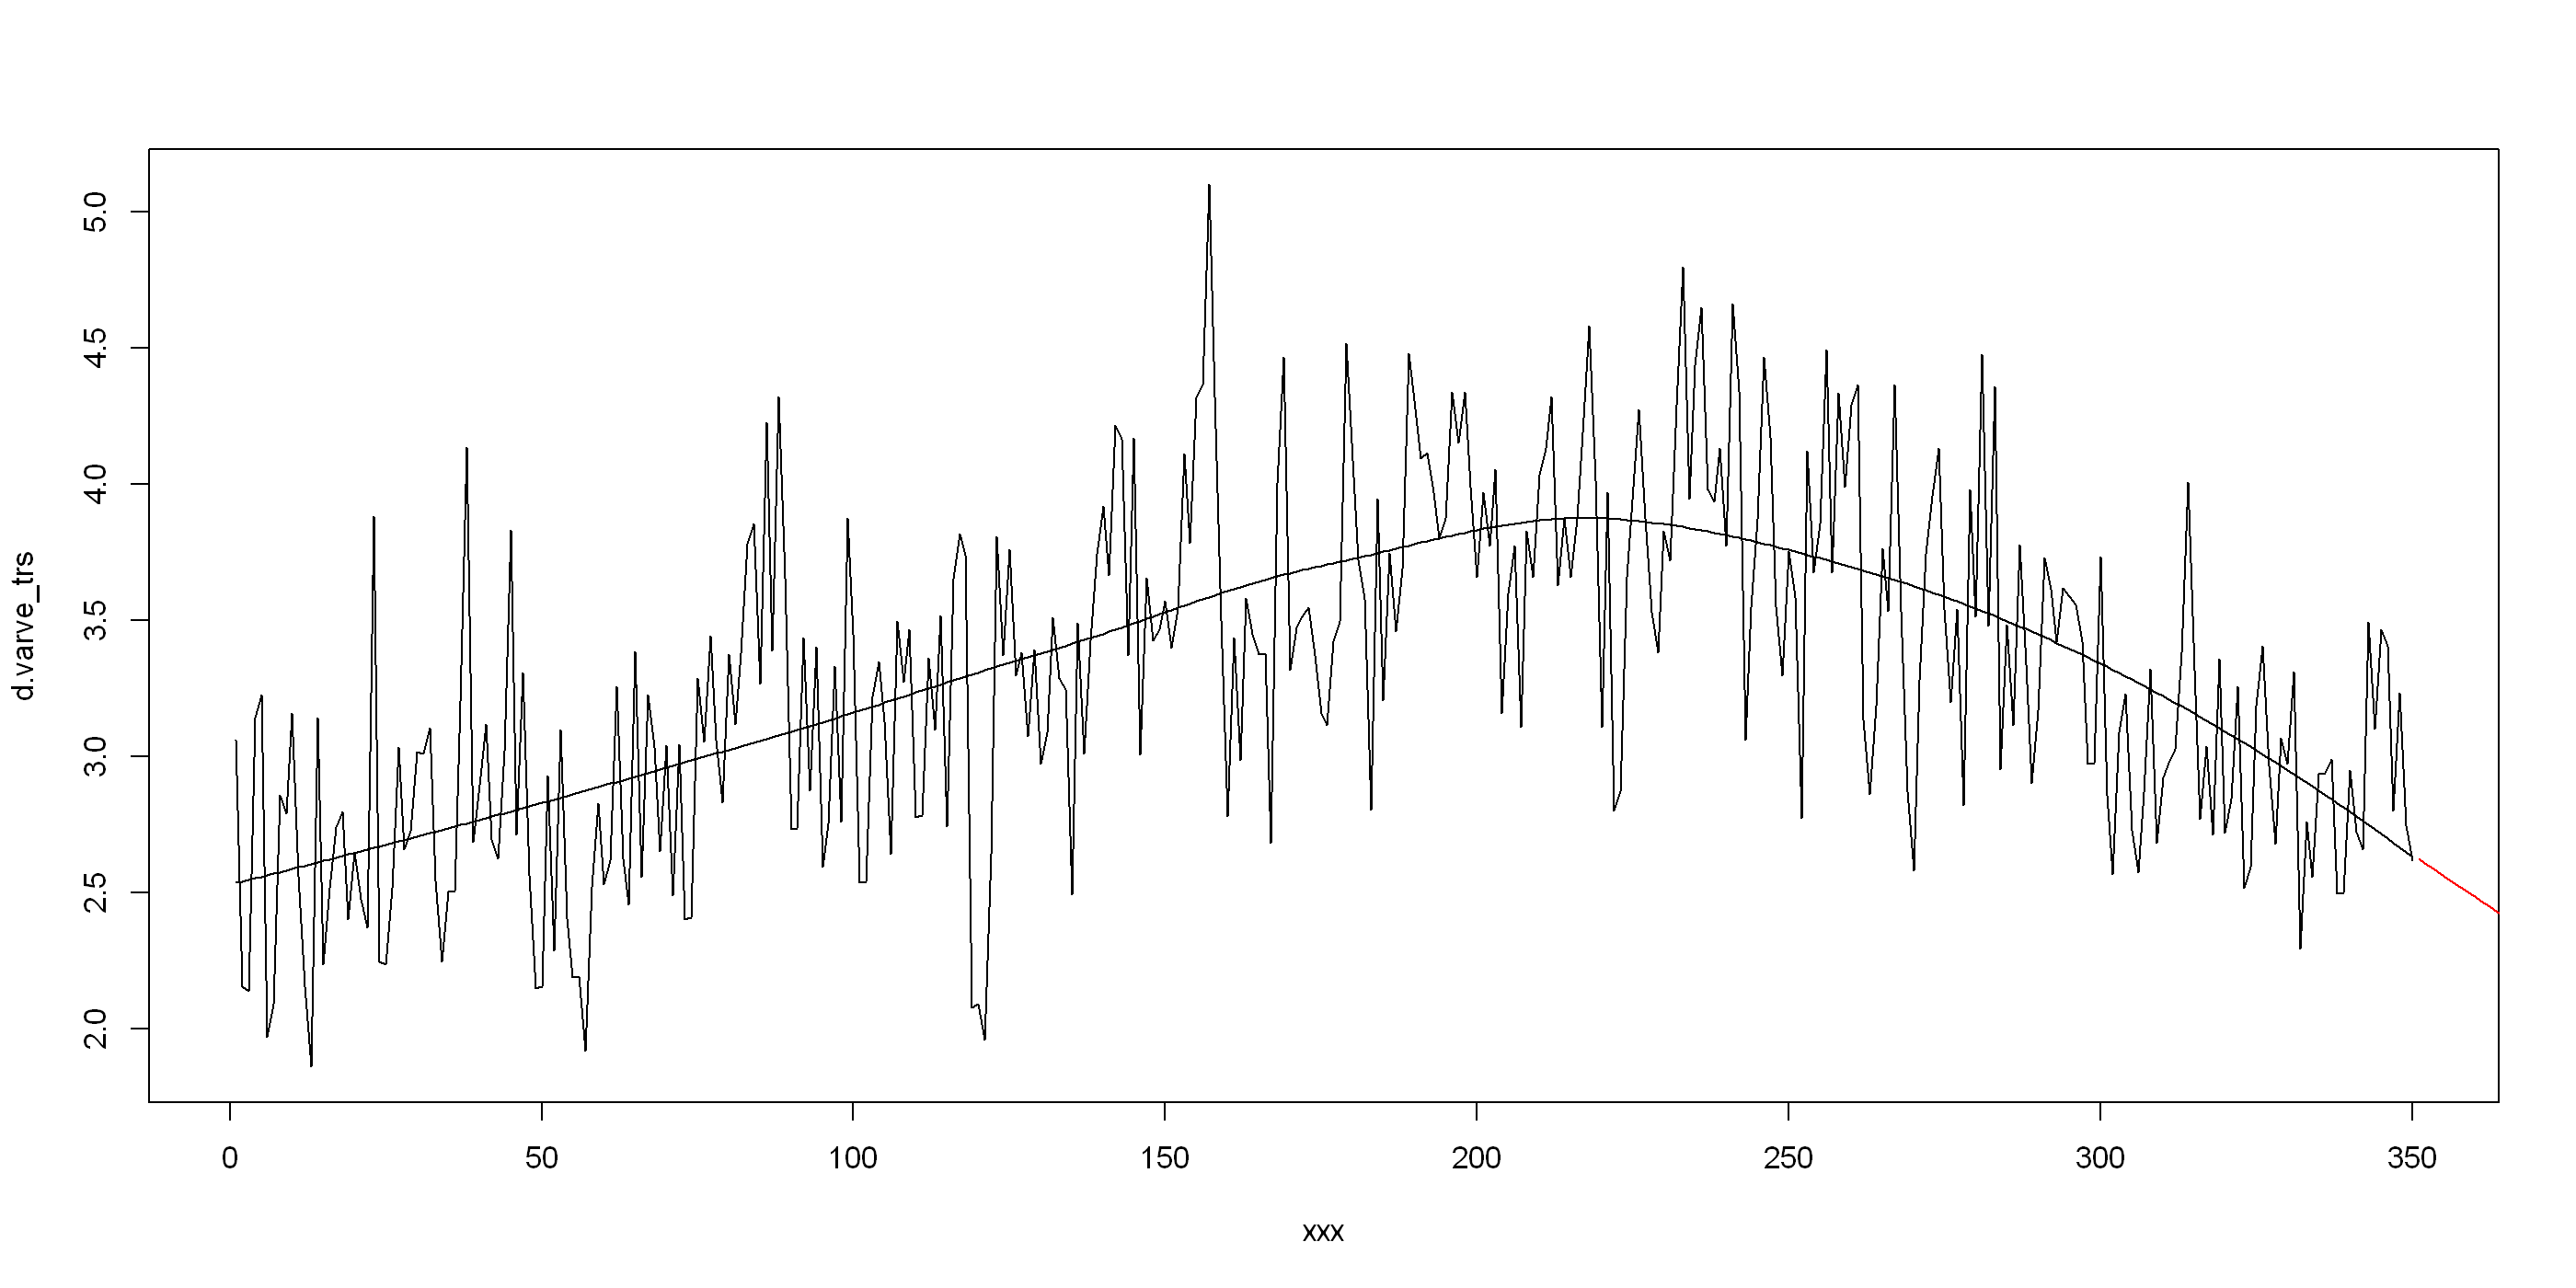

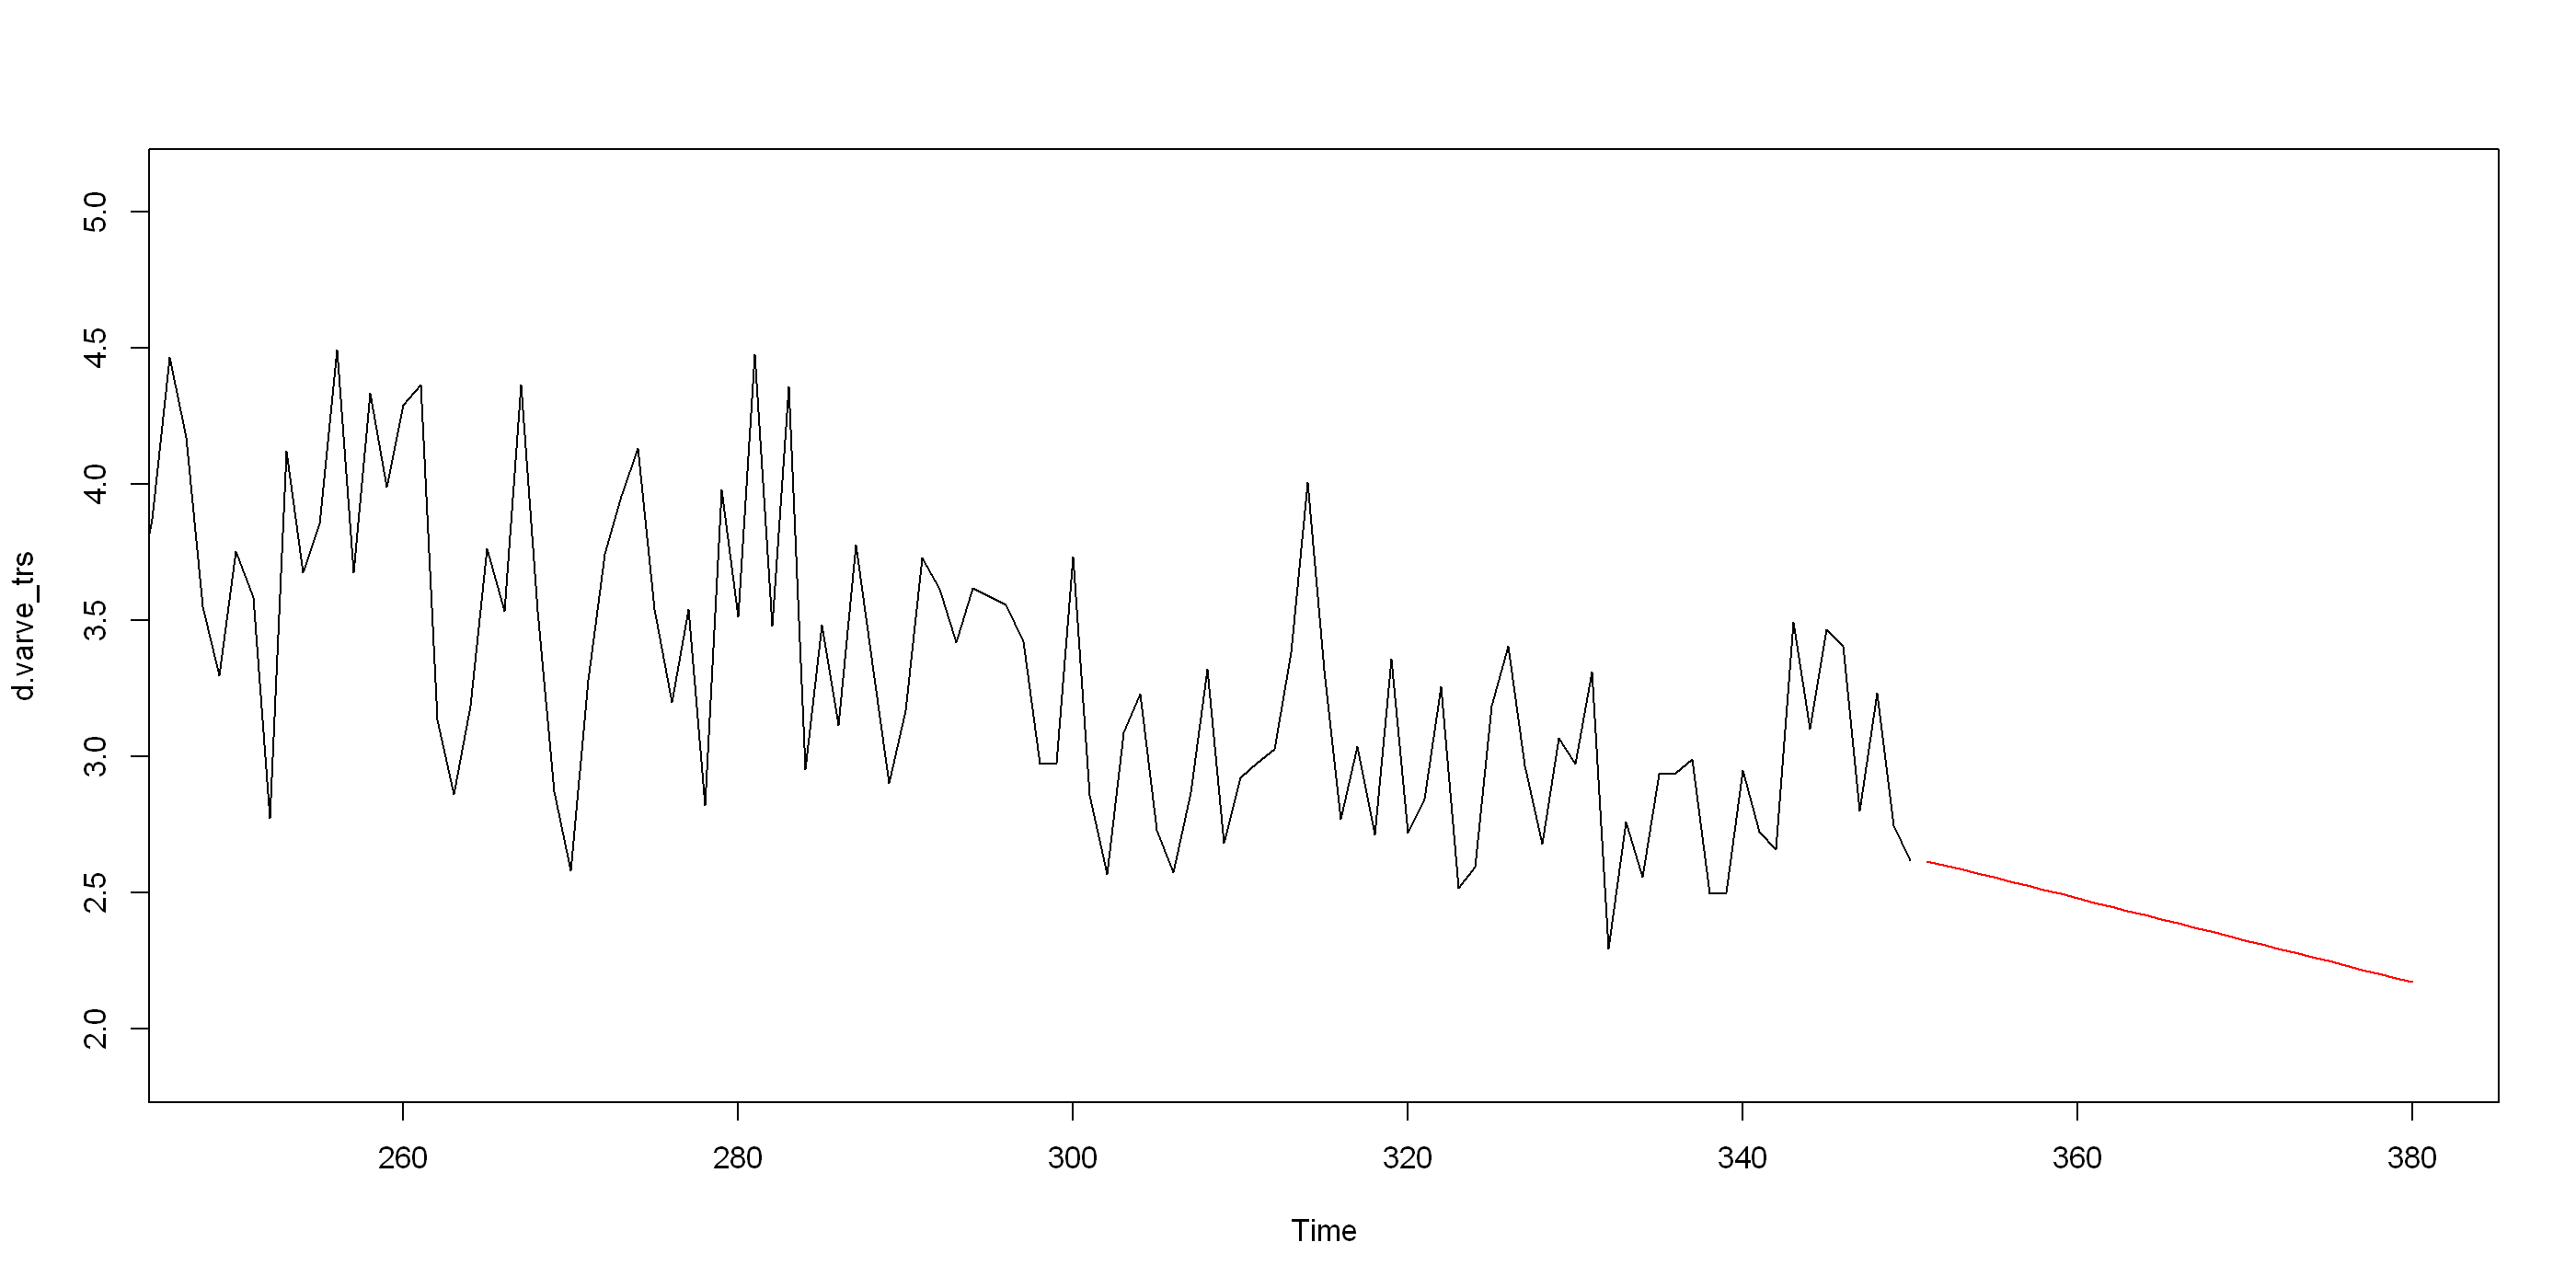

In [74]:
ts.r_pred <- predict(ts.ar_model,n.ahead = 30)

plot(ts.rem)
lines(ts.r_pred$pred,col="red")

xxx <- time(d.varve_trs)
plot(xxx,d.varve_trs,type='l')
lines(ts.xh,ts.t_pred,col="red")
lines(pred.trend)

print(start(d.varve_trs))
print(end(d.varve_trs))

plot(d.varve_trs,xlim=c(end(d.varve_trs)[1]-100,end(d.varve_trs)[1]+30))
lines(ts.t_pred+ts.r_pred$pred,col="red")


The linear extrapolation is the issue here not any standard CI's, we can clearly see there are huge issues with that specific model selection.

List of 9
 $ fitted      : Time-Series [1:348, 1:3] from 3 to 350: 1.25 0.9 1.47 1.9 1.41 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:3] "xhat" "level" "trend"
 $ x           : Time-Series [1:350] from 1 to 350: 3.06 2.15 2.14 3.14 3.22 ...
 $ alpha       : Named num 0.553
  ..- attr(*, "names")= chr "alpha"
 $ beta        : Named num 0.137
  ..- attr(*, "names")= chr "beta"
 $ gamma       : logi FALSE
 $ coefficients: Named num [1:2] 2.7613 -0.0361
  ..- attr(*, "names")= chr [1:2] "a" "b"
 $ seasonal    : chr "additive"
 $ SSE         : num 106
 $ call        : language HoltWinters(x = d.varve_trs, gamma = FALSE)
 - attr(*, "class")= chr "HoltWinters"


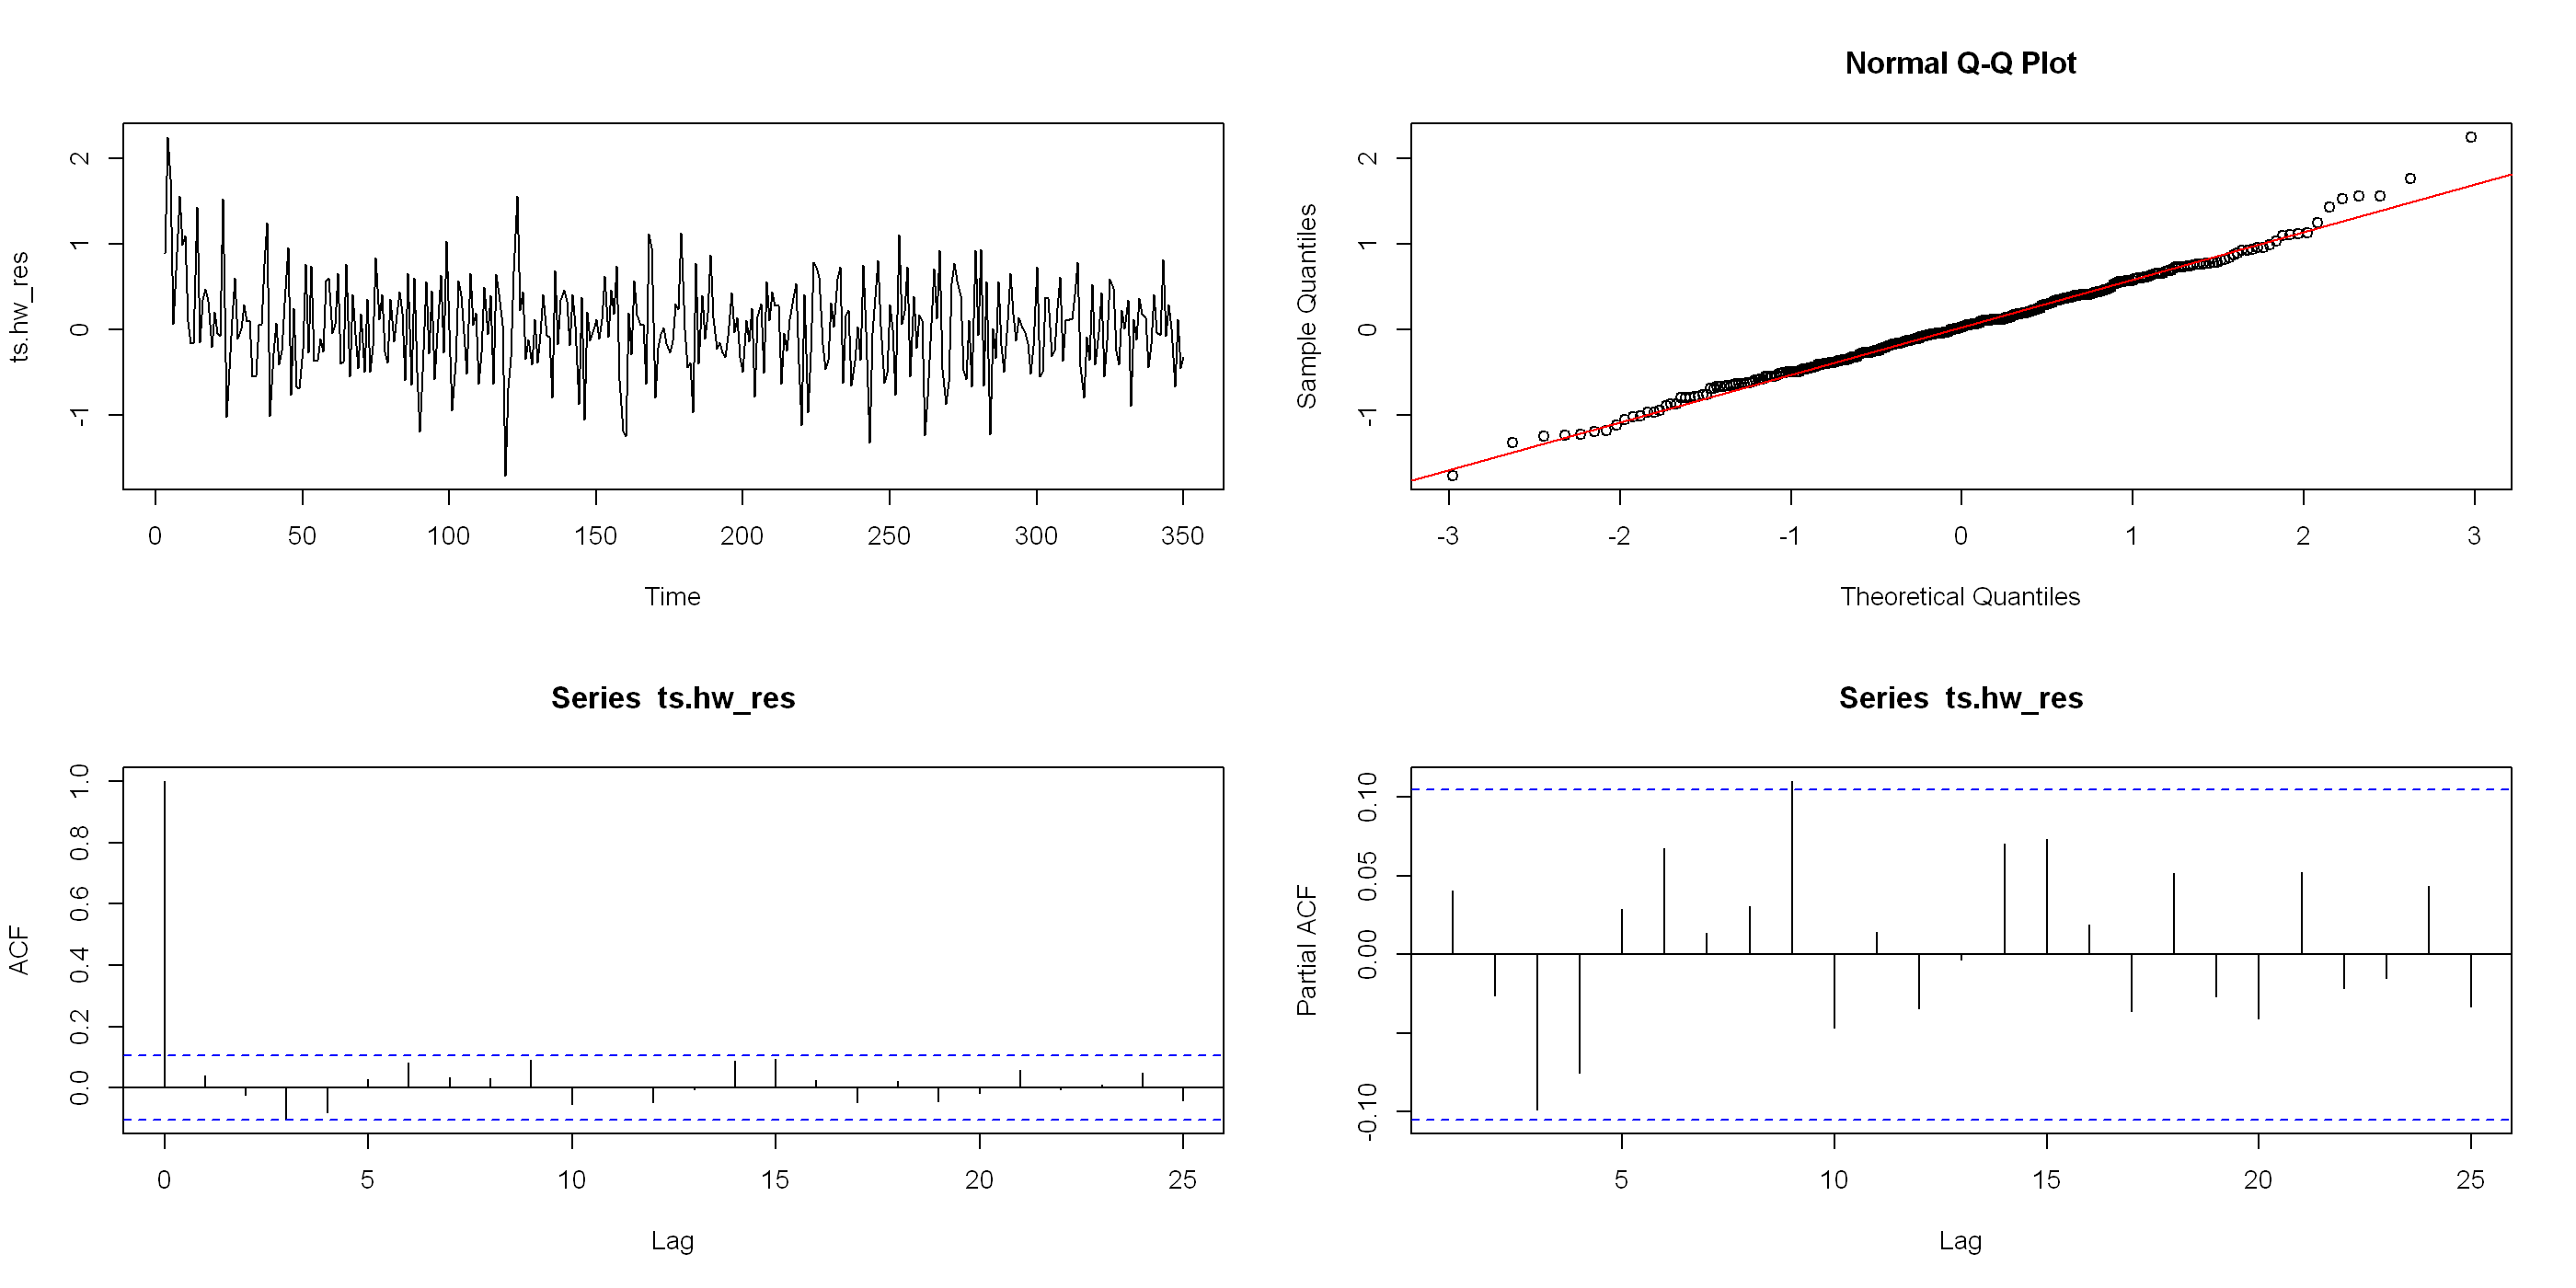

In [91]:
hw <- HoltWinters(d.varve_trs,gamma = FALSE)
str(hw)
ts.hw_res <- residuals(hw)
par(mfrow = c(2,2))
plot(ts.hw_res)
qqnorm(ts.hw_res)
qqline(ts.hw_res,col="red")
acf(ts.hw_res)
pacf(ts.hw_res)




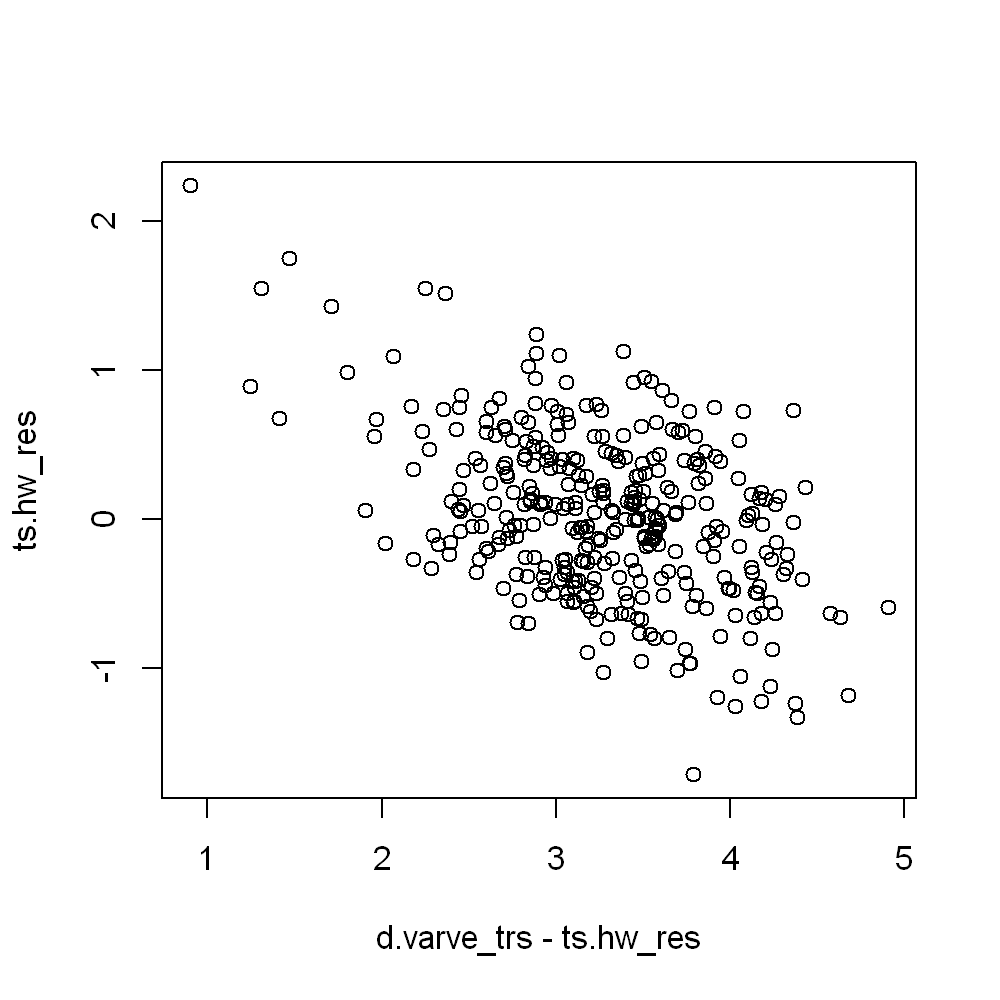

In [95]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

par(mfrow = c(1,1))
plot(d.varve_trs-ts.hw_res,ts.hw_res)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


The residuals are not perfect, namley the stationarity is violated, and there is a slight deviation from the the standard in the PACF, further there is strong dependence structure in the residuals, which is not a good sign.

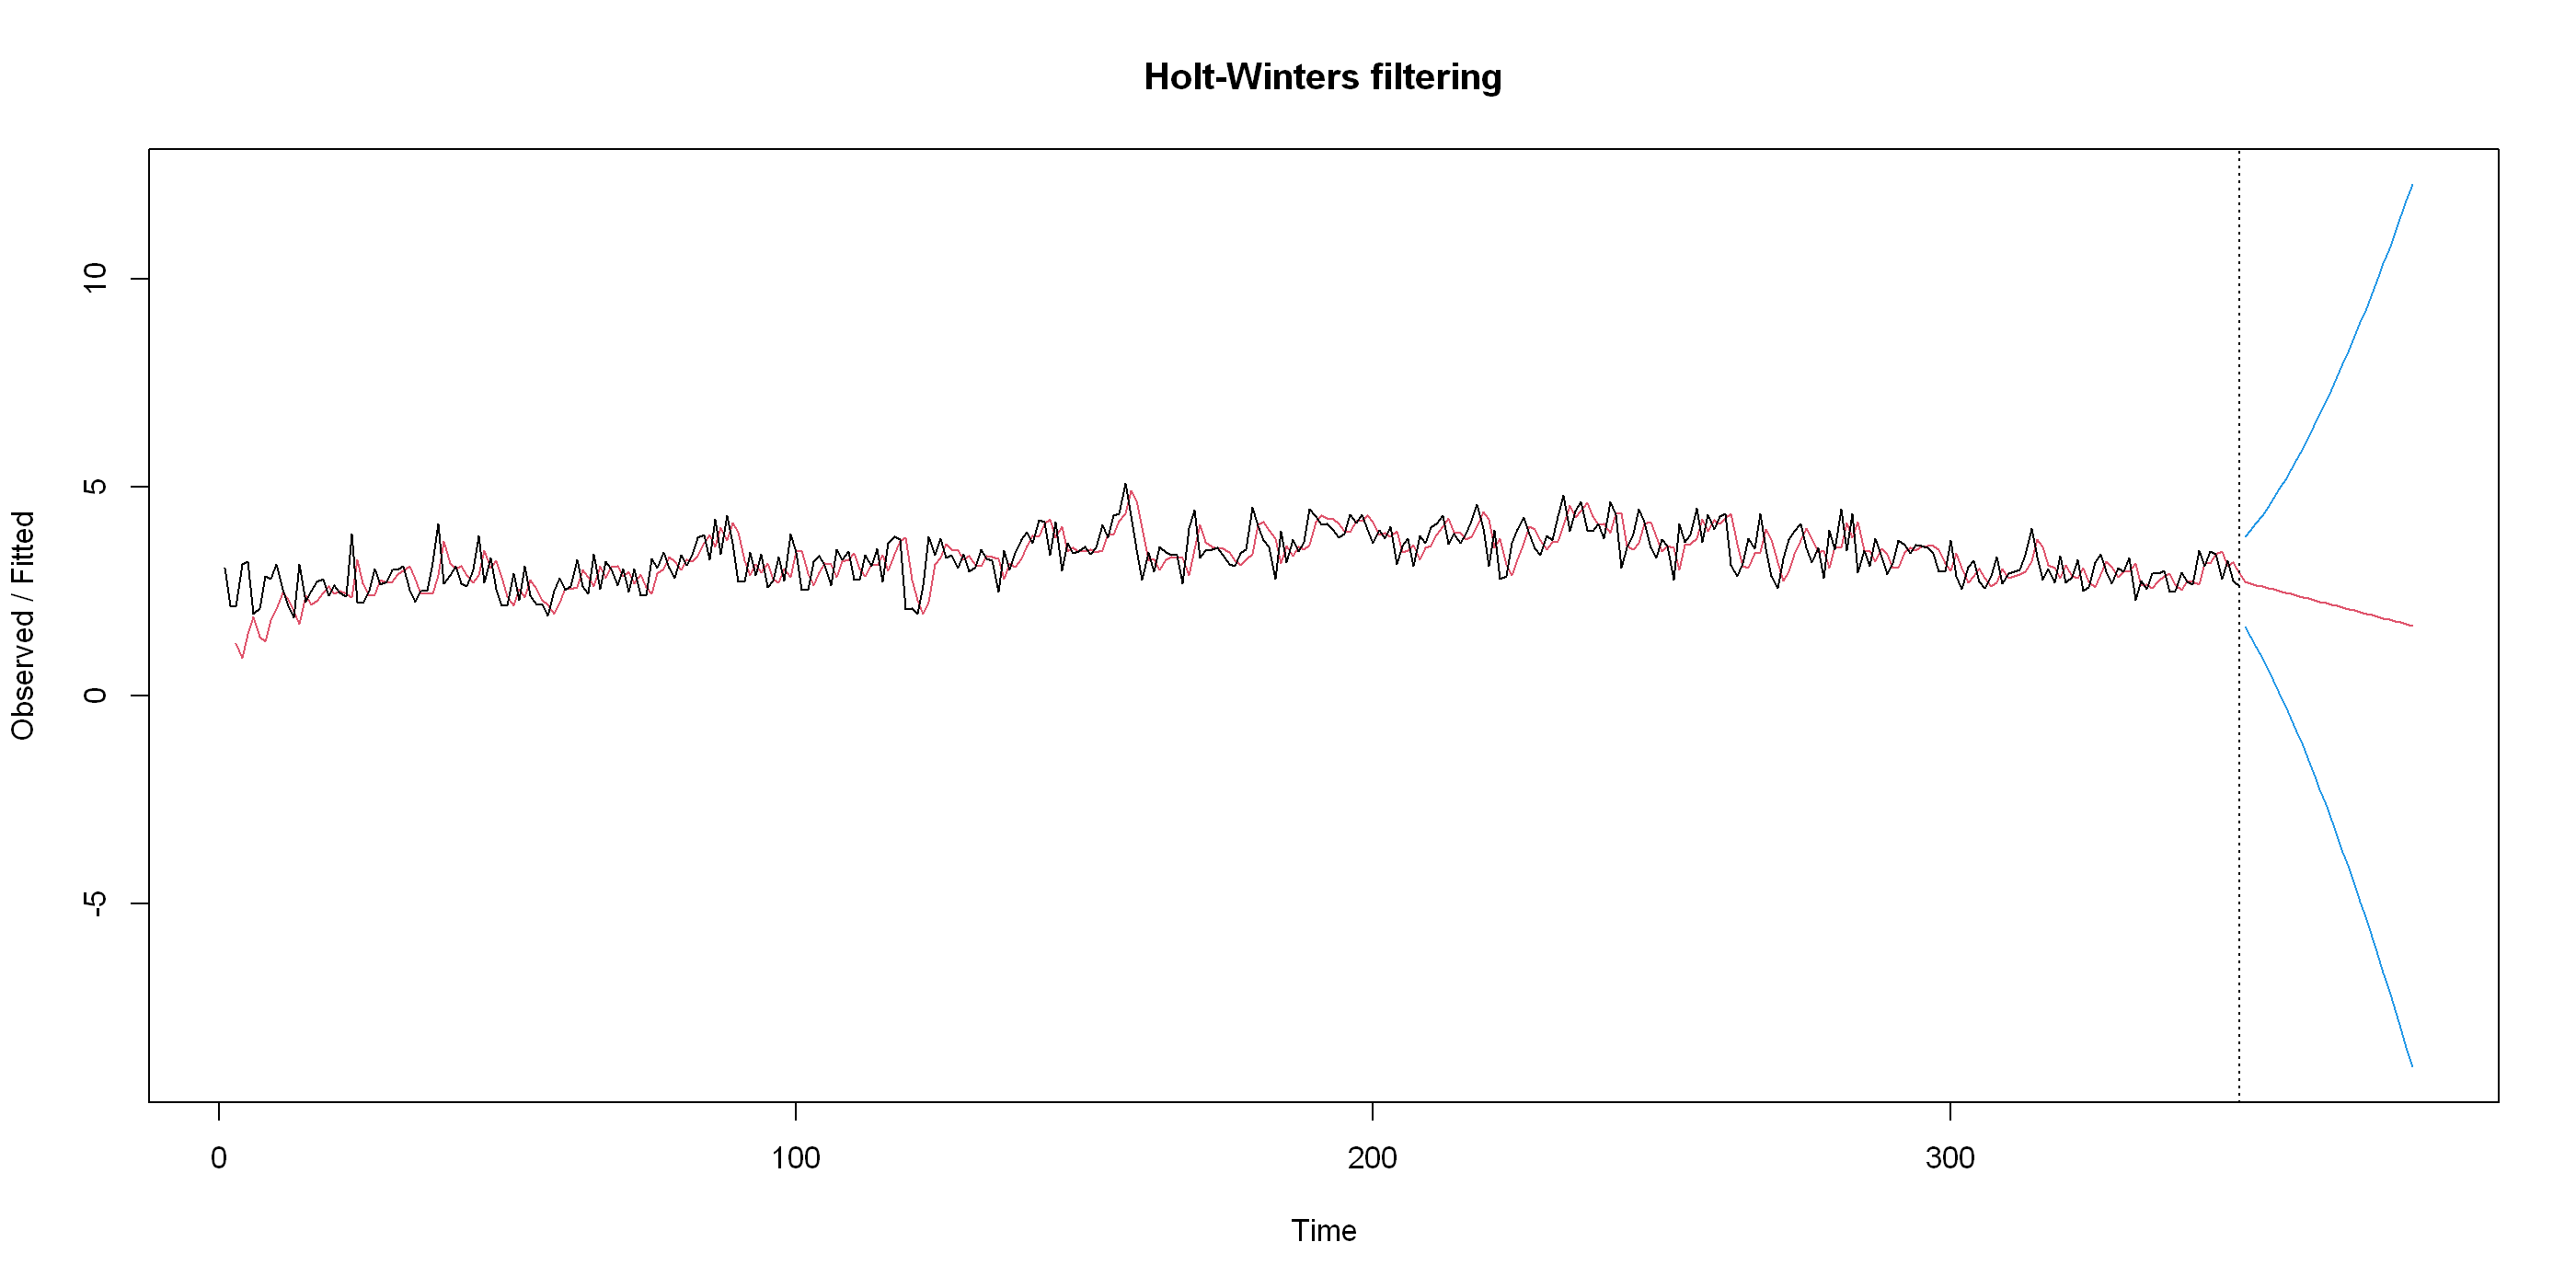

In [107]:
# plot(d.varve_trs)
hw_pred <- predict(hw,n.ahead = 30,prediction.interval = T)
plot(hw,hw_pred)

### 3.


![ex6_3.png](ex6_3.png)

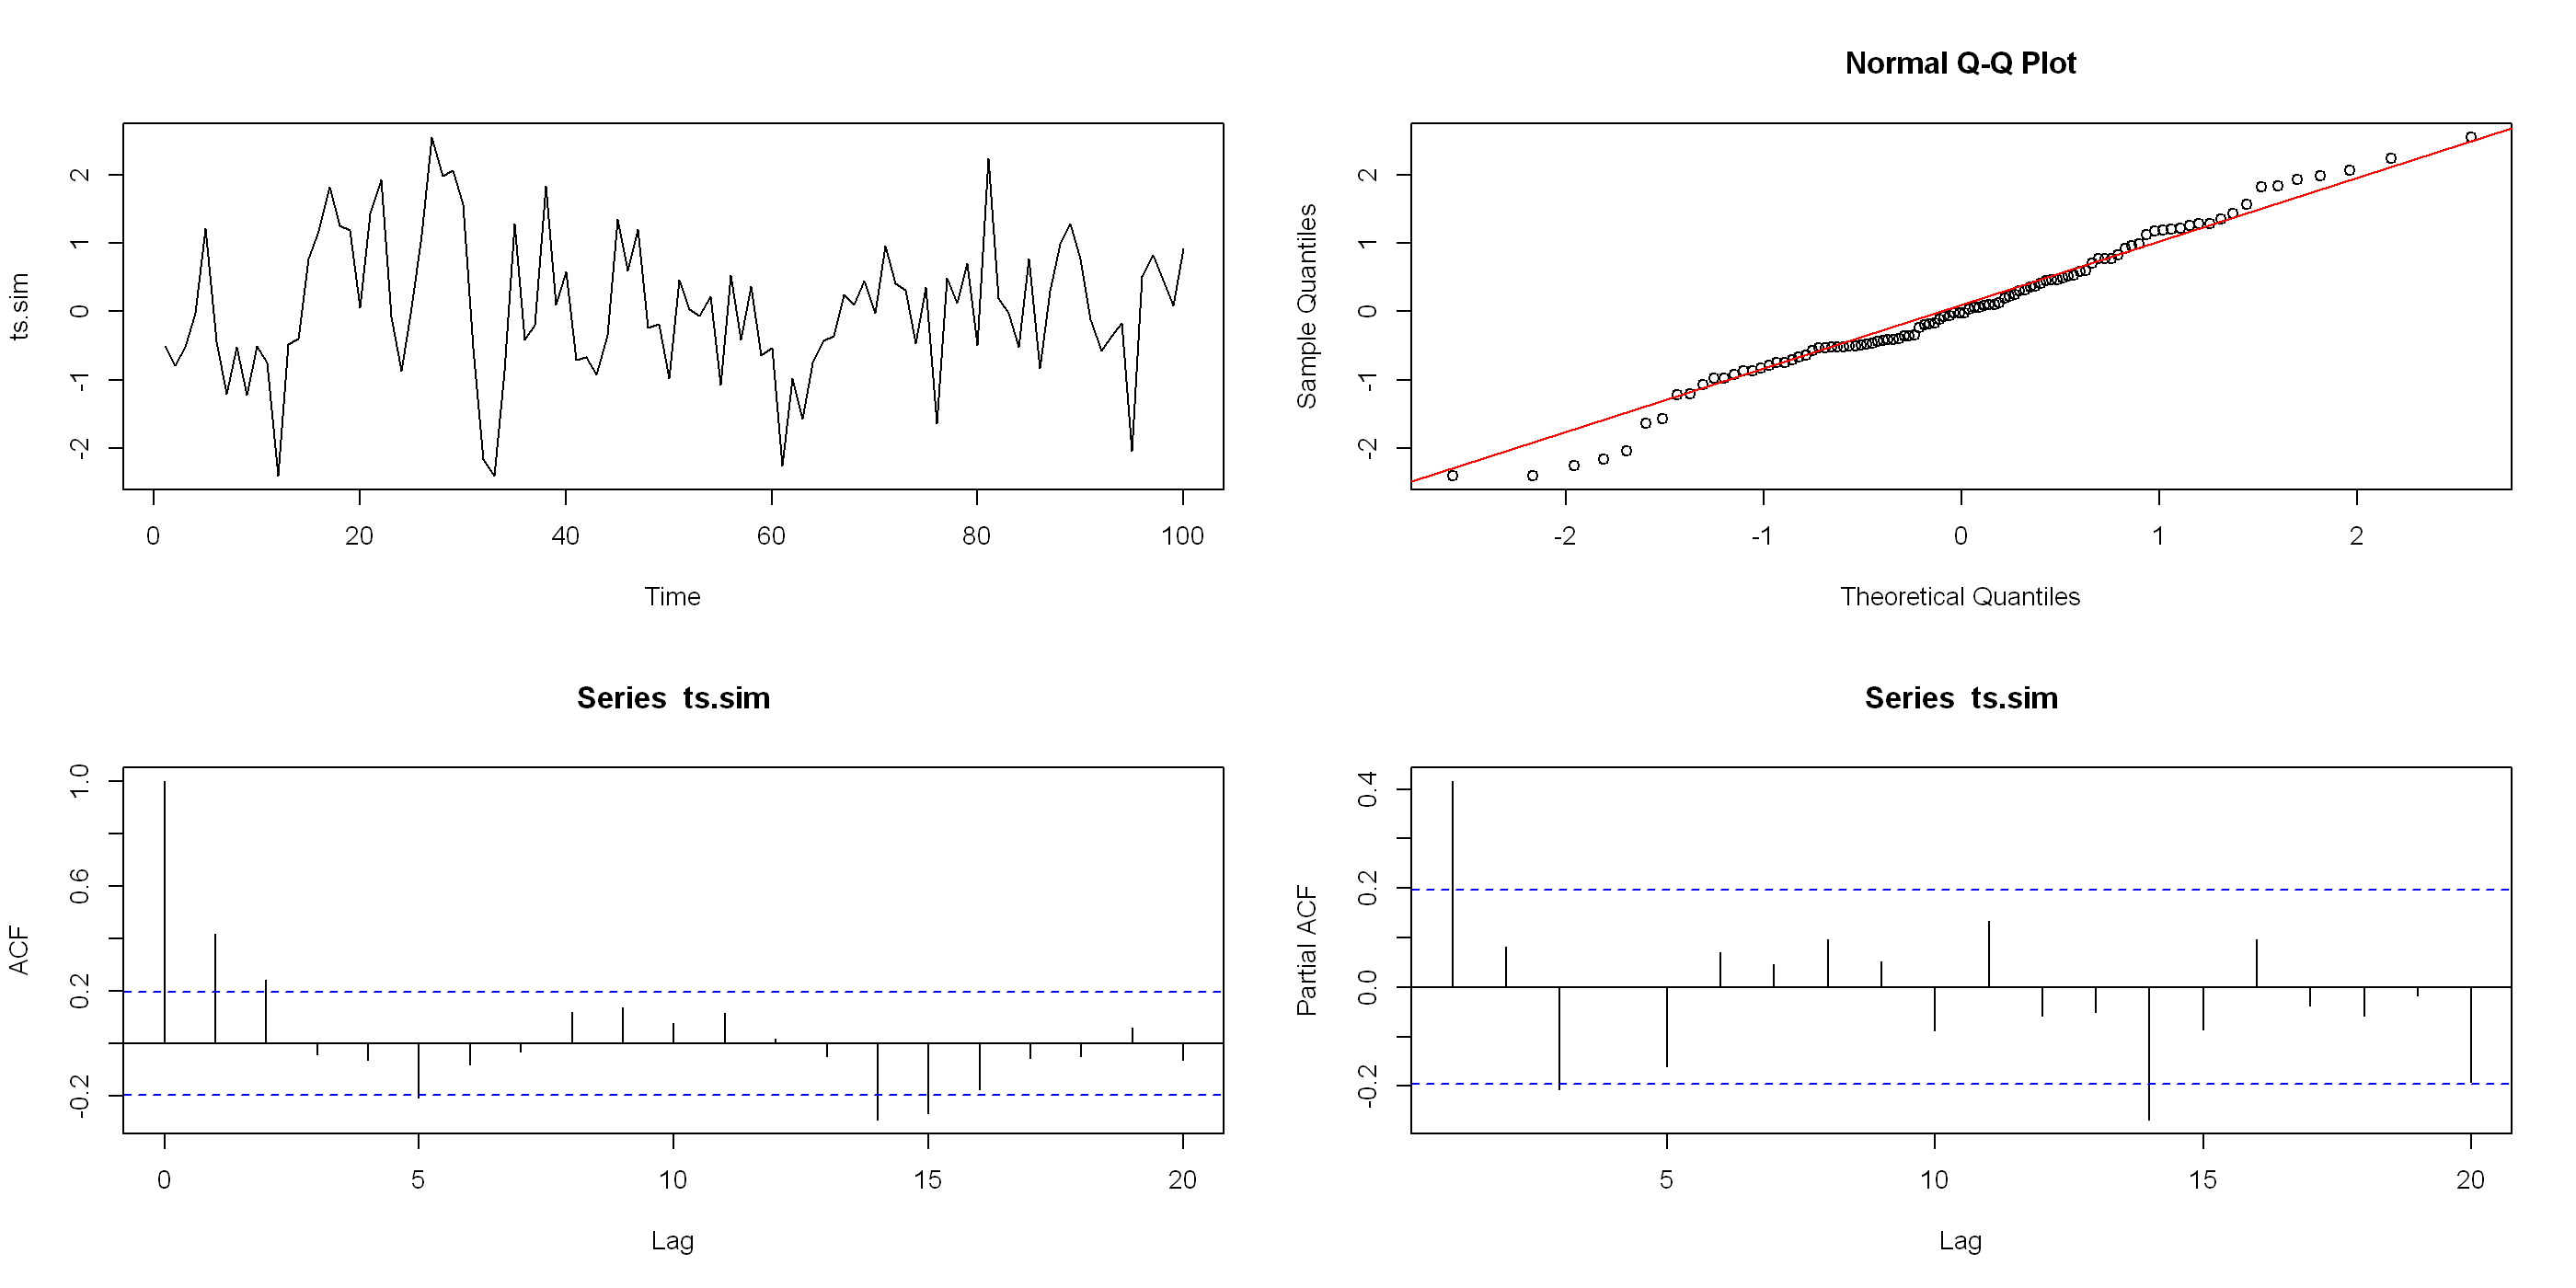

In [120]:
set.seed(5)
ts.sim_full <- arima.sim(model = list(ar=c(0.3)),n=120)
ts.sim <- window(ts.sim_full,end=100)
op<-par(mfrow = c(2,2))
plot(ts.sim)
qqnorm(ts.sim)
qqline(y=ts.sim,col="red")
acf(ts.sim)
pacf(ts.sim)


A reasonable guess would be ARIMA(1,2), ARIMA(3,2), ARIMA(5,5), and so on for it is rather unclear.

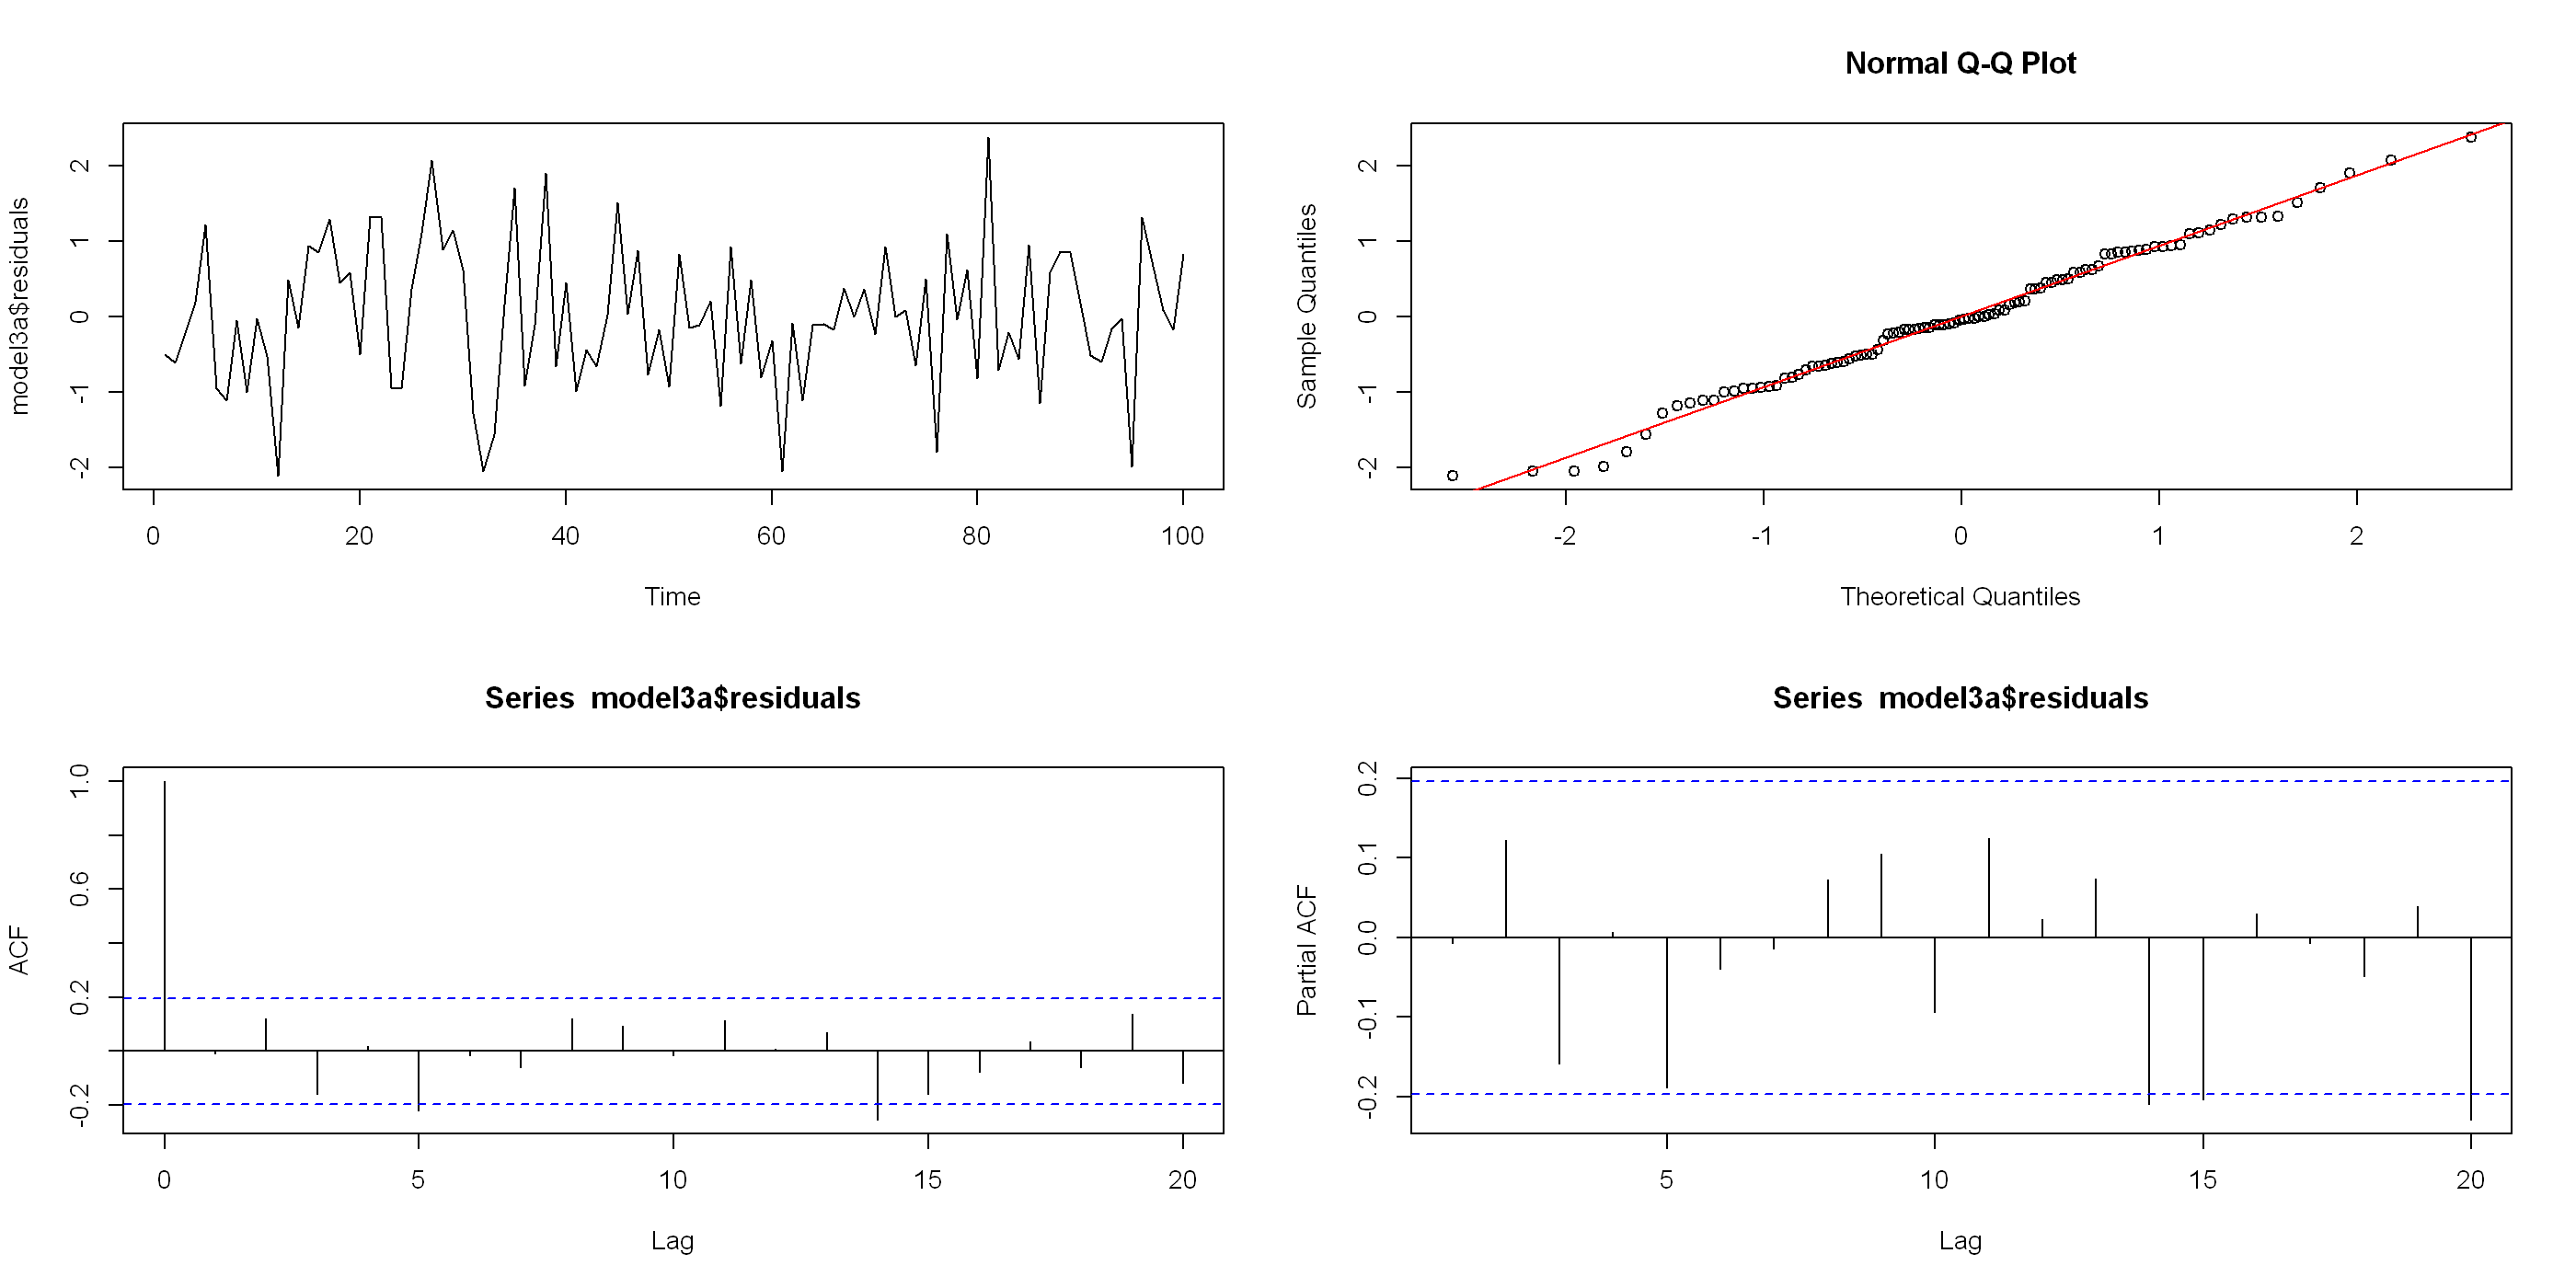

In [111]:

model3a <- arima(ts.sim,order = c(1,0,1))
op<-par(mfrow = c(2,2))
plot(model3a$residuals)
qqnorm(model3a$residuals)
qqline(y=model3a$residuals,col="red")
acf(model3a$residuals)
pacf(model3a$residuals)

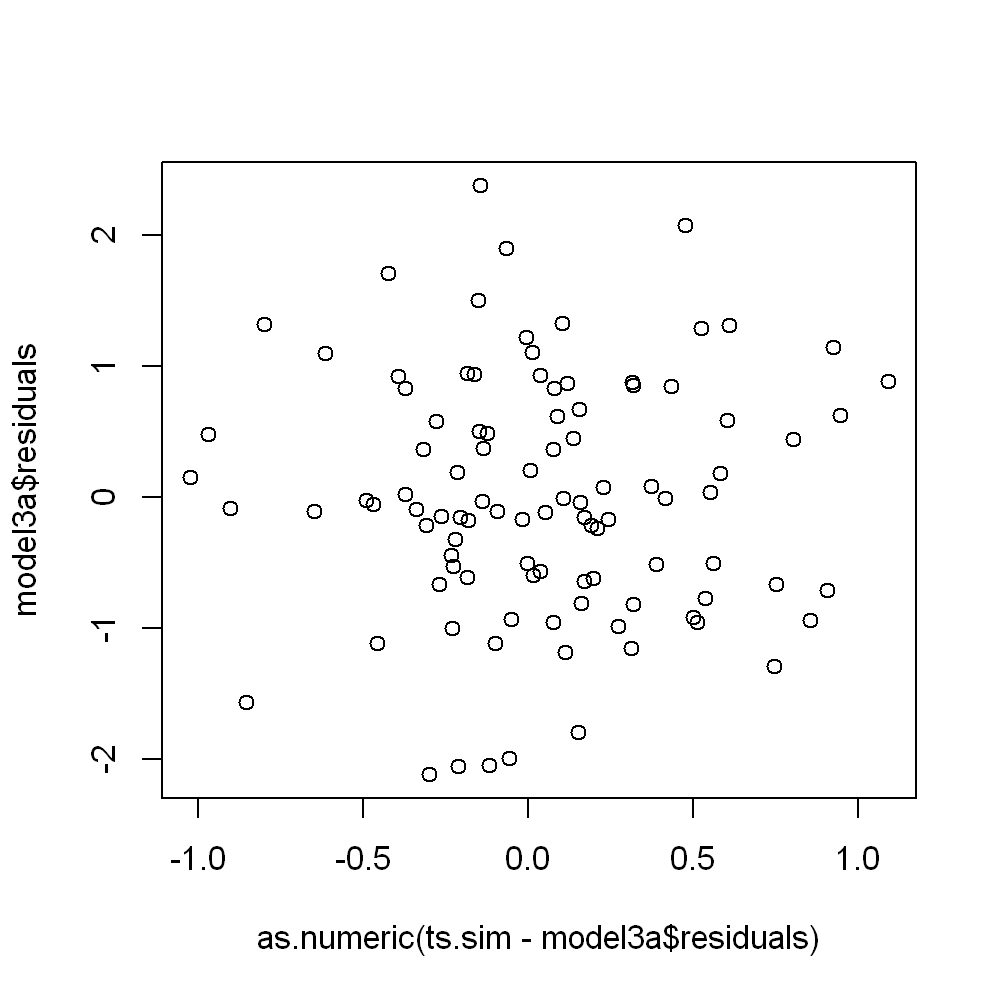

In [113]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

par(mfrow = c(1,1))
plot(as.numeric(ts.sim-model3a$residuals),model3a$residuals)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


First, the residual ts looks, stationary, roughly normal, however, there are slight deviations in the serial dependence which the model does not fully capture, lastly, the scatter looks fine.

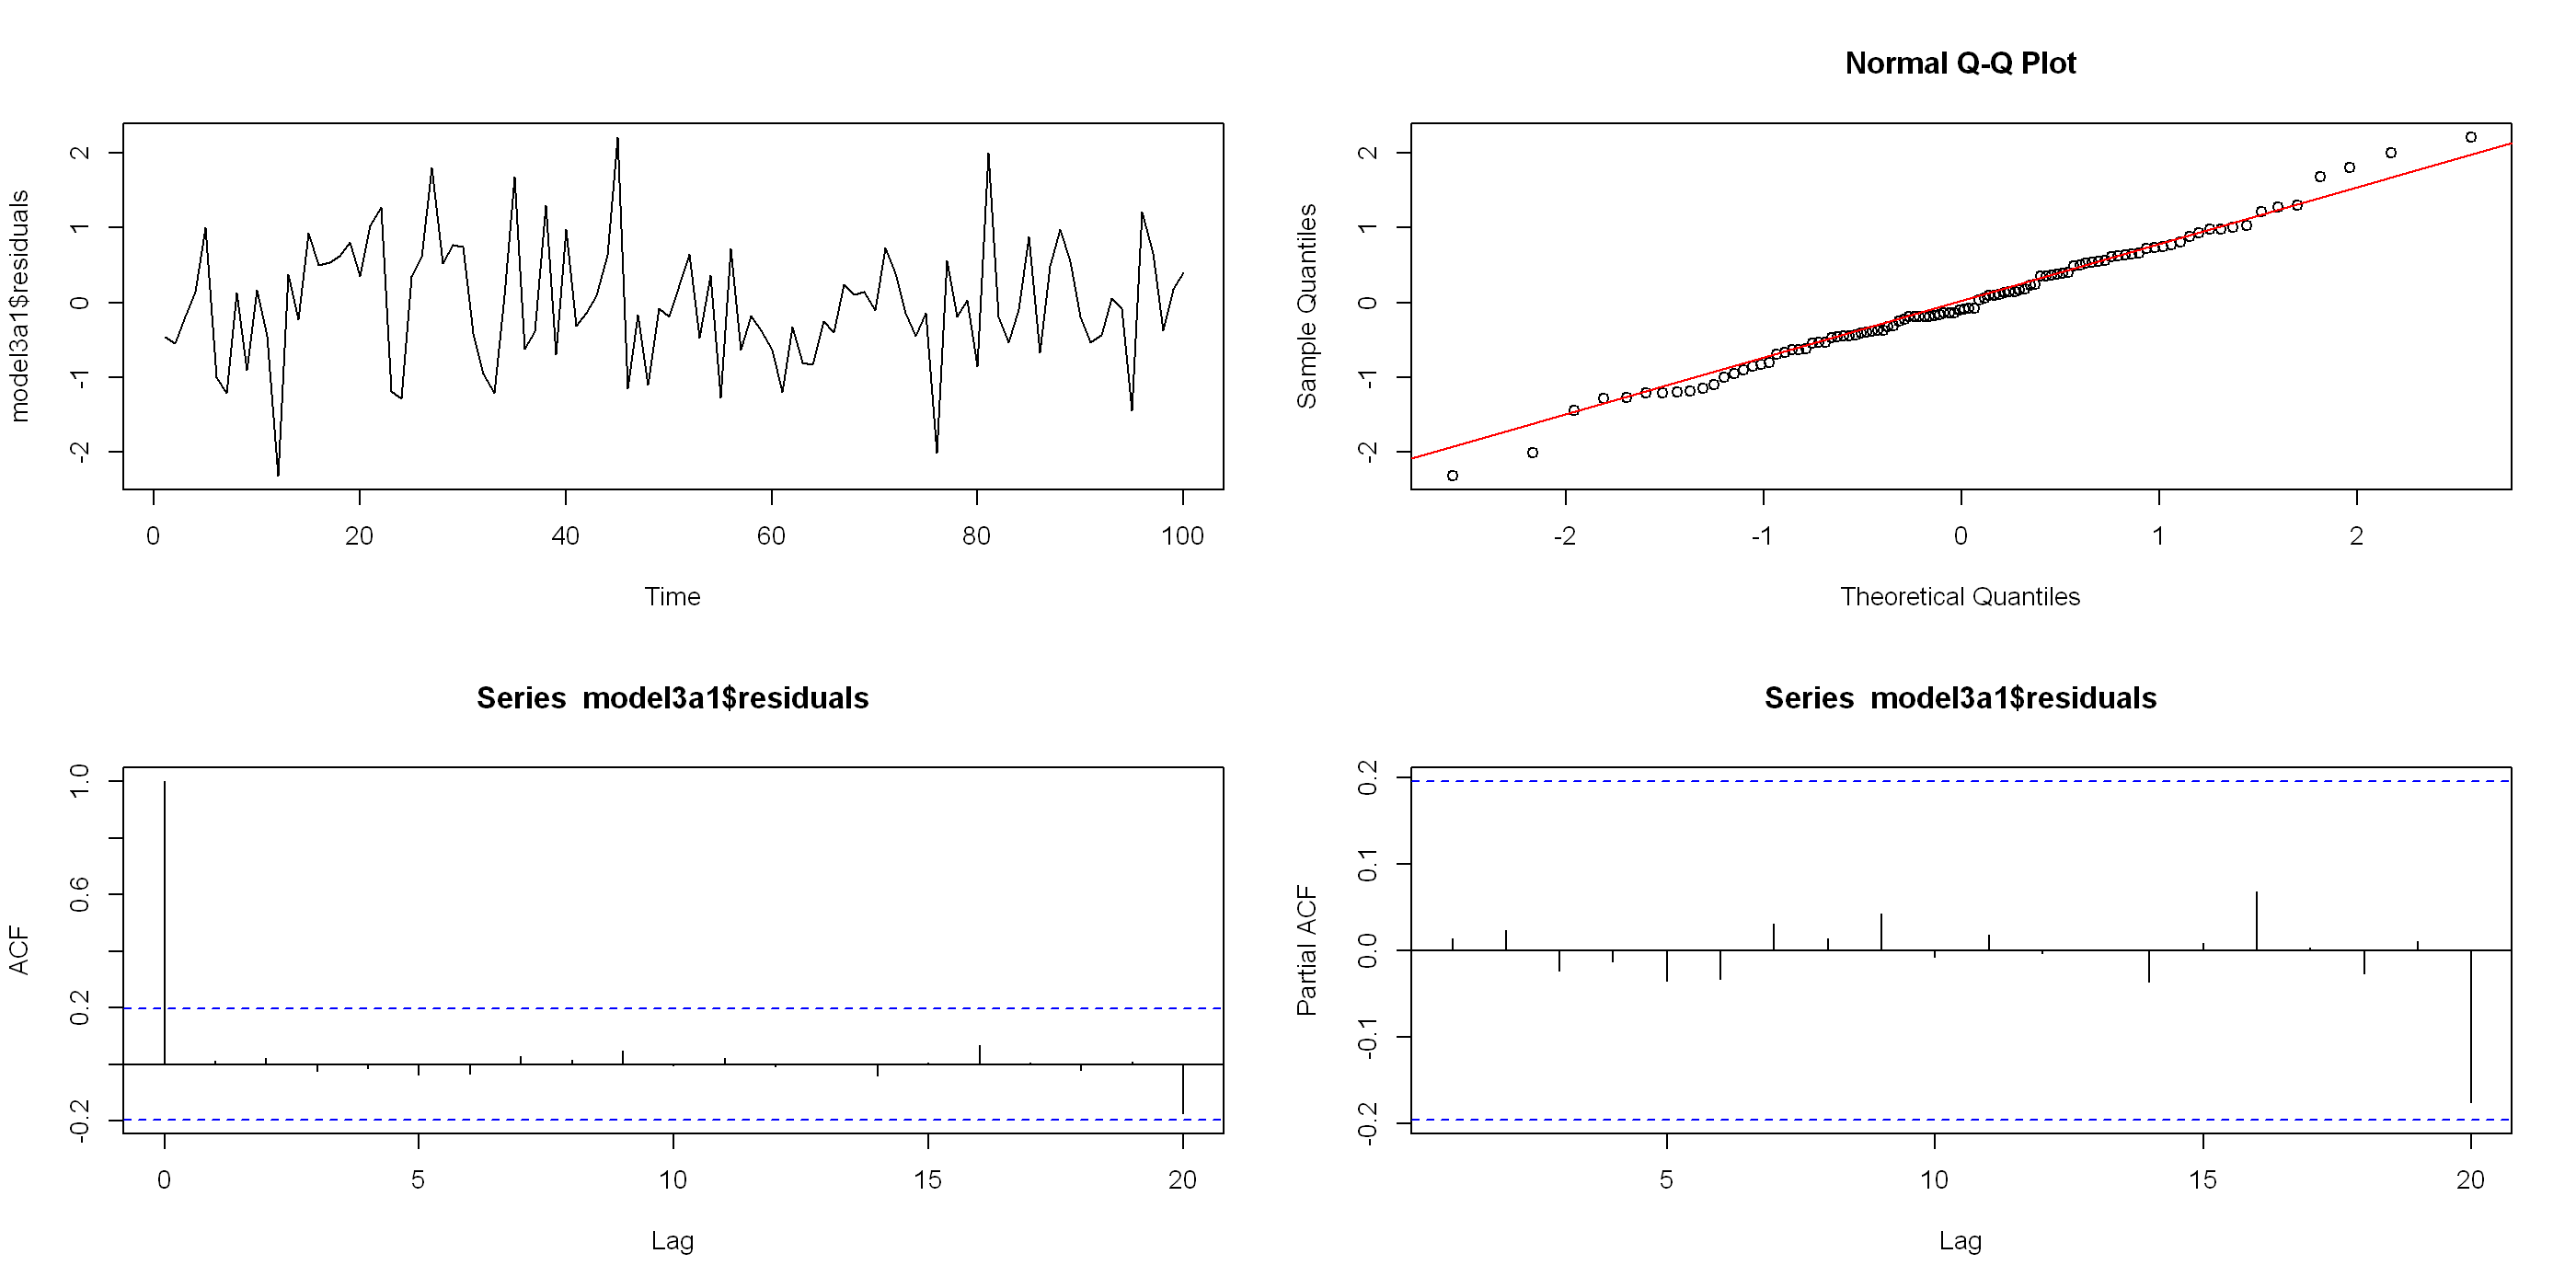

In [160]:

model3a1 <- arima(ts.sim,order = c(15,0,1))
op<-par(mfrow = c(2,2))
plot(model3a1$residuals)
qqnorm(model3a1$residuals)
qqline(y=model3a1$residuals,col="red")
acf(model3a1$residuals)
pacf(model3a1$residuals)

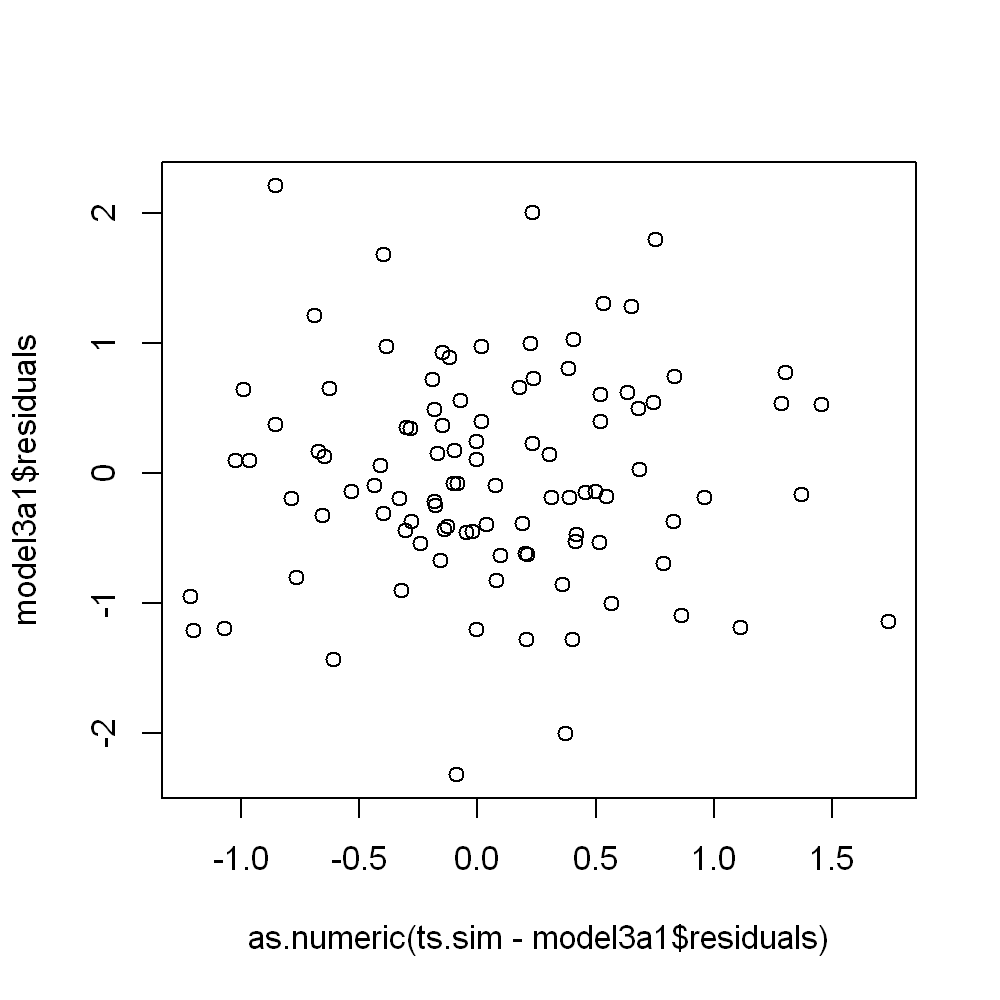

In [161]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

par(mfrow = c(1,1))
plot(as.numeric(ts.sim-model3a1$residuals),model3a1$residuals)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


Now all previous issues have been addressed, but the risk of overfitting becomes much higher. In the standard statistical arguments the variance should increase, but that is in contrast to the bias, i.e. how much is contributed to the overall error, with that said it does not mean the CI's become wider. It is actually the opposite, the reason is simple: the in-sample variance of the error is decreased.

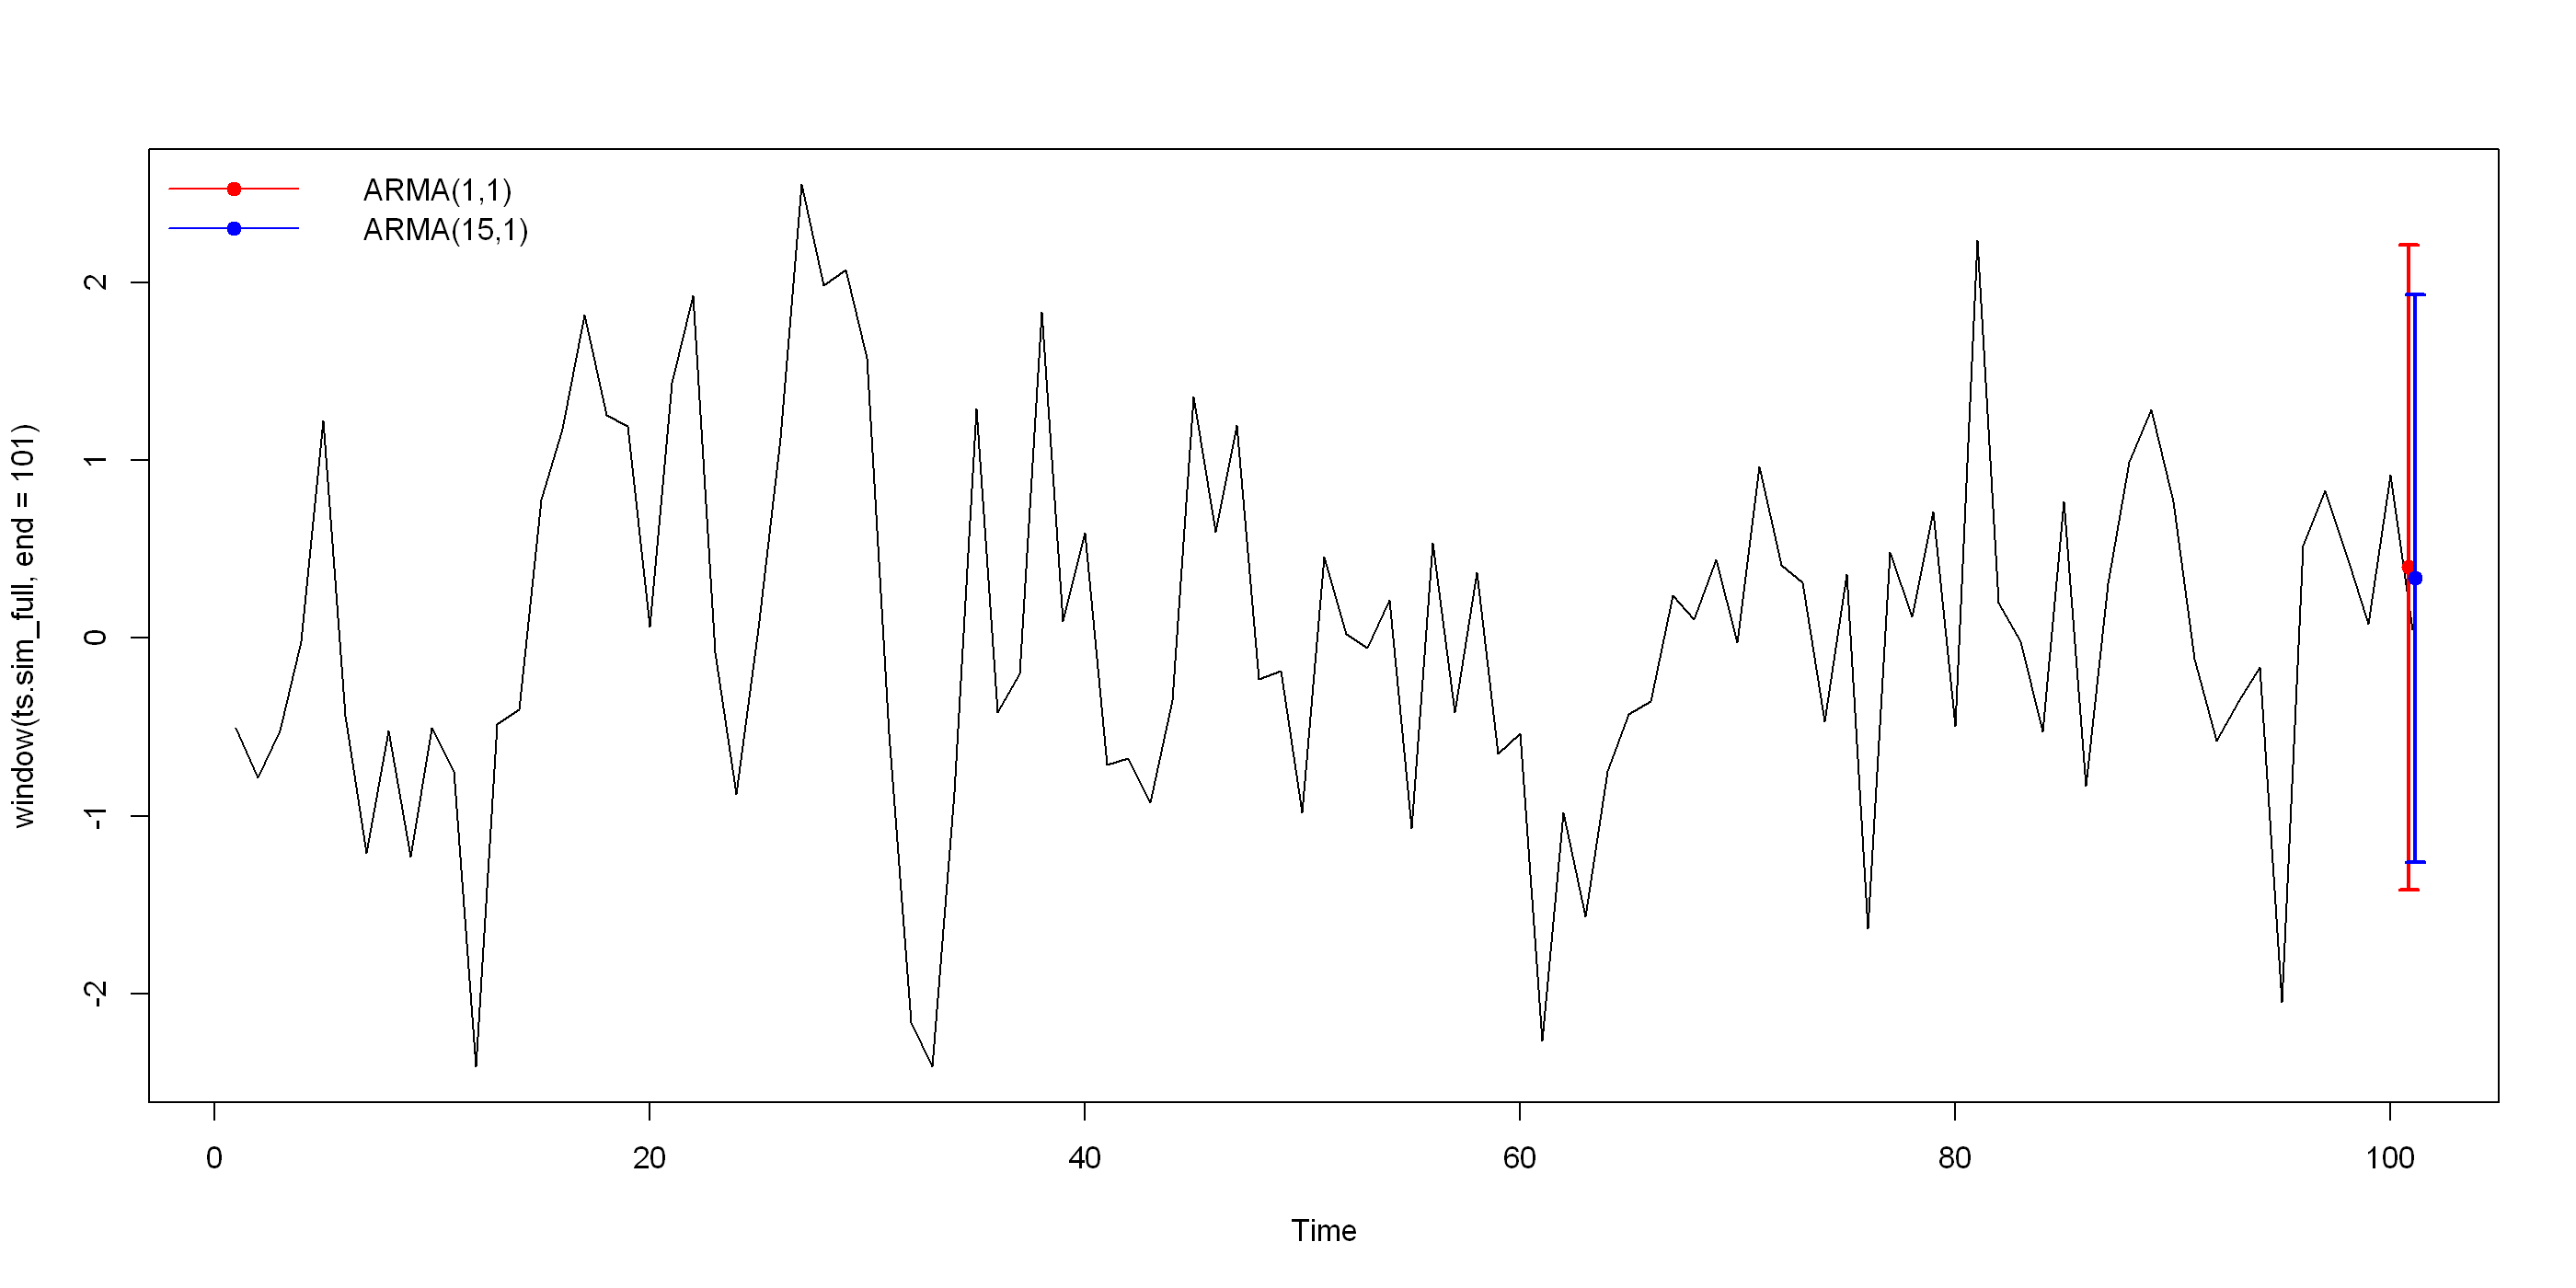

In [164]:
plot(window(ts.sim_full,end=101))
model3a_p <- predict(model3a,n.ahead = 1)
model3a1_p <- predict(model3a1,n.ahead = 1)
y_3a = c(model3a_p$pred - z95 * model3a_p$se, (model3a_p$pred + z95 * model3a_p$se))
y_3a1 = c(model3a1_p$pred - z95 * model3a1_p$se, (model3a1_p$pred + z95 * model3a1_p$se))
# tiny horizontal offset so the two models don't overlap at x=101
x1 <- 101 - 0.15
x2 <- 101 + 0.15

# model 3a (red): whisker from lower to upper, then point
arrows(x1, y_3a[1],  x1, y_3a[2],
       angle = 90, code = 3, length = 0.05, col = "red", lwd = 2)
points(x1, model3a_p$pred, col = "red", pch = 19)

# model 3a1 (blue)
arrows(x2, y_3a1[1], x2, y_3a1[2],
       angle = 90, code = 3, length = 0.05, col = "blue", lwd = 2)
points(x2, model3a1_p$pred, col = "blue", pch = 19)

legend("topleft",
       legend = c("ARMA(1,1)", "ARMA(15,1)"),
       col = c("red", "blue"),
       pch = 19, lty = 1, bty = "n")



Exactly the behaviour as argued for above.

In [167]:
# Simulation
set.seed(1)
# Initialization
coverage.1 <- numeric(length = 100)
coverage.5 <- numeric(length = 100)
coverage.10 <- numeric(length = 100)
ms.pred.error.1 <- numeric(100)
ms.pred.error.5 <- numeric(100)
ms.pred.error.10 <- numeric(100)
for(i in 1:100){
    # simulate AR(1) of length 101
    sim <- arima.sim(model = list(ar = c(0.3)), n = 101)
    # fit AR(1), AR(5) and AR(10)
    fit1 <- arima(window(sim, start = 1, end = 100), order = c(1,0,0))
    fit5 <- arima(window(sim, start = 1, end = 100), order = c(5,0,0))
    fit10 <- arima(window(sim, start = 1, end = 100), order = c(10,0,0))
    # 1-step prediction:
    pred1 <- predict(fit1,n.ahead = 1)
    pred5 <-  predict(fit5,n.ahead = 1)
    pred10 <-  predict(fit10,n.ahead = 1)

    # 1-step prediction interval:
    PI1 <- c(pred1$pred - z95 * pred1$se, (pred1$pred + z95 * pred1$se))
    PI5 <- c(pred5$pred - z95 * pred5$se, (pred5$pred + z95 * pred5$se))
    PI10 <- c(pred10$pred - z95 * pred10$se, (pred10$pred + z95 * pred10$se))
    # MSE
    ms.pred.error.1[i] <- (sim[101] - pred1$pred[1])^2
    ms.pred.error.5[i] <- (sim[101] - pred5$pred[1])^2
    ms.pred.error.10[i] <- (sim[101] - pred10$pred[1])^2
    # Is true 101th observation contained in prediction interval?
    coverage.1[i] <- ifelse(sim[101] >= PI1[1] & sim[101] <= PI1[2], 1, 0)
    coverage.5[i] <- ifelse(sim[101] >= PI5[1] & sim[101] <= PI5[2], 1, 0)
    coverage.10[i] <- ifelse(sim[101] >= PI10[1] & sim[101] <= PI10[2], 1, 0)
}
# How often in 100 times is true value contained in prediction interval?
sum(coverage.1)
sum(coverage.5)
sum(coverage.10)
# Mean squared error averaged over 100 simulations
mean(ms.pred.error.1)
mean(ms.pred.error.5)
mean(ms.pred.error.10)

[1] 92

[1] 90

[1] 86

[1] 1.161098

[1] 1.341005

[1] 1.437393

Clean example of overfitting, rather intuitive, the more complex the model the higher the error and fallout from the CI.